In [14]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


In [ ]:
# =========================================================
# Table 2: initial conditions from the paper
# State order: [C, D, N, Treg, T8]
# =========================================================
y0 = np.array([
    0.4,      # C(0)
    4e-4,     # D(0)
    3e-4,     # N(0)
    5e-4,     # Treg(0)
    1.5e-3    # T8(0)
], dtype=float)

# =========================================================
# Define our model
# =========================================================
def ode_system(t, y, p):

    C, D, N, Tr, T8 = y

    dCdt = p["lambda_C"]*C*(1-C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C

    dDdt = p["lambda_DC_comb"]*(C/(p["K_C"] + C)) - p["d_D"]*D

    dNdt = (
        p["sigma_N"]
        - p["d_N"]*N
        - p["gamma_N"]*Tr*N
        + p["a_C"]*N*(C/(1 + C/p["beta_1"] + N/p["beta_2"]))
    )

    dTrdt = -p["d_Treg"]*Tr + p["lambda_Tr_comb"]*(C/(p["K_C"] + C))

    dT8dt = (
        -p["d_T8"]*T8
        + p["lambda_T8_comb"]*(D/(p["K_D"] + D))*(1/(1 + Tr/p["K_Treg"]))
    )

    return [dCdt, dDdt, dNdt, dTrdt, dT8dt]

def simulate(params):

    y0 = np.array([0.4, 4e-4, 3e-4, 5e-4, 1.5e-3])

    t_eval = np.linspace(0, 200, 1001)

    sol = solve_ivp(
        lambda t, y: ode_system(t, y, params),
        [0, 200],
        y0,
        t_eval=t_eval,
        method="LSODA"
    )

    return sol.t, sol.y



params = {
    # Tumor
    "lambda_C": 1.5,
    "C_M": 0.8,
    "eta_8": 328.55,
    "eta_N": 300.0,
    "d_C": 0.17,

    # DCs
    "lambda_DC_comb": 8e-5,        # baseline level of inactive DCs
    "K_C": 0.4,
    "d_D": 0.1,

    # NK cells
    "sigma_N": 5e-5,
    "d_N": 0.1,
    "gamma_N": 150.0,
    "a_C": 0.5,
    "beta_1": 0.4,
    "beta_2": 2e-4,

    # Tregs
    "d_Treg": 0.2,
    "lambda_Tr_comb": 2e-4, # combined with baseline level of regulatory T cell precursors

    # CD8 T cells
    "d_T8": 0.18,
    "lambda_T8_comb": 0.00108, # combined with baseline level of CD8 T cell precursors
    "K_Treg": 2.5e-4,
    "K_D": 4e-4,
}


In [4]:
t, y = simulate(params)

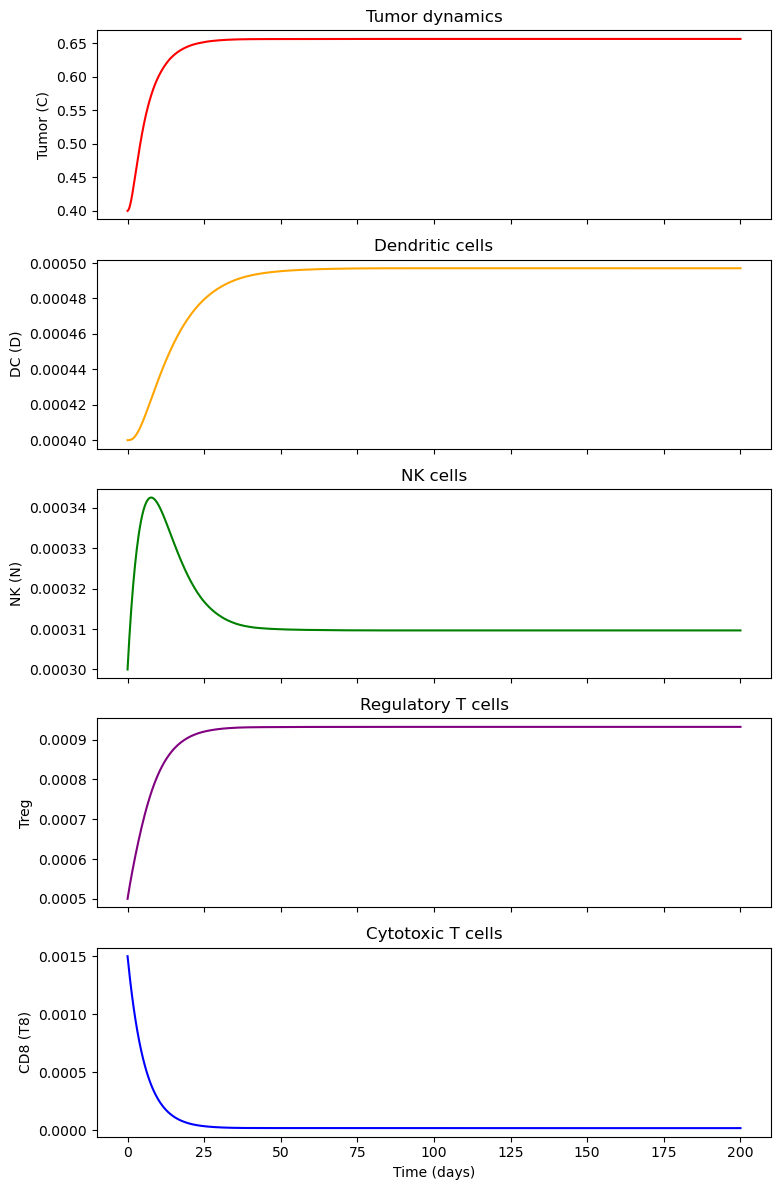

In [17]:
fig, axes = plt.subplots(5, 1, figsize=(8, 12), sharex=True)

# Tumor
axes[0].plot(t, y[0], color="red")
axes[0].set_ylabel("Tumor (C)")
axes[0].set_title("Tumor dynamics")

# DC
axes[1].plot(t, y[1], color="orange")
axes[1].set_ylabel("DC (D)")
axes[1].set_title("Dendritic cells")

# NK
axes[2].plot(t, y[2], color="green")
axes[2].set_ylabel("NK (N)")
axes[2].set_title("NK cells")

# Treg
axes[3].plot(t, y[3], color="purple")
axes[3].set_ylabel("Treg")
axes[3].set_title("Regulatory T cells")

# CD8
axes[4].plot(t, y[4], color="blue")
axes[4].set_ylabel("CD8 (T8)")
axes[4].set_title("Cytotoxic T cells")
axes[4].set_xlabel("Time (days)")

plt.tight_layout()
plt.show()

### Analyze the impact of baseline immunity on dynamic evolution
Sweep between 1X10^-4 to-6 X 10^-4

In [18]:
# =========================================================
# PART 1: Fix T10, sweep T80
# =========================================================

params["lambda_Tr_comb"] = 2e-4
lambda_T8_space = np.linspace(5.4e-4, 3.24e-3, 50) # original T80 space was (1e-4, 6e-4, 50), multiply with 5.4

# store results
C_vals = []
D_vals = []
N_vals = []
Treg_vals = []
T8_vals = []

for T8_val in lambda_T8_space:

    params["lambda_T8_comb"] = T8_val

    t, y = simulate(params)

    C_vals.append(y[0][-1])
    D_vals.append(y[1][-1])
    N_vals.append(y[2][-1])
    Treg_vals.append(y[3][-1])
    T8_vals.append(y[4][-1])

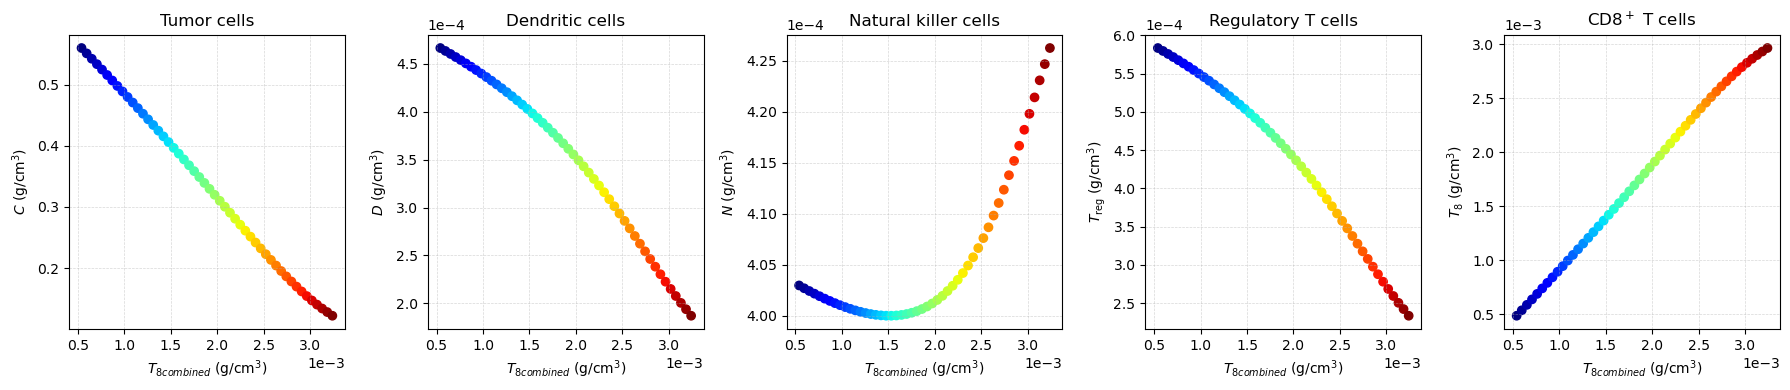

In [7]:
# The final code

import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

cmap = plt.cm.jet
colors = cmap((lambda_T8_space - lambda_T8_space.min()) / (lambda_T8_space.max() - lambda_T8_space.min()))

datasets = [
    (C_vals,    "Tumor cells",         r"$C$ (g/cm$^3$)"),
    (D_vals,    "Dendritic cells",      r"$D$ (g/cm$^3$)"),
    (N_vals,    "Natural killer cells", r"$N$ (g/cm$^3$)"),
    (Treg_vals, "Regulatory T cells",  r"$T_{\rm reg}$ (g/cm$^3$)"),
    (T8_vals,   "CD8$^+$ T cells",     r"$T_8$ (g/cm$^3$)"),
]

for ax, (yvals, title, ylabel) in zip(axes, datasets):
    ax.scatter(lambda_T8_space, yvals, c=colors)
    ax.set_title(title)
    ax.set_xlabel(r"$T_{8combined}$ (g/cm$^3$)")
    ax.set_ylabel(ylabel)
    # Format both axes as a×10^n whenever values are very small or very large
    ax.ticklabel_format(style="sci", axis="both", scilimits=(-3, 3))
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('Model1_Figure_1a.png')
plt.show()

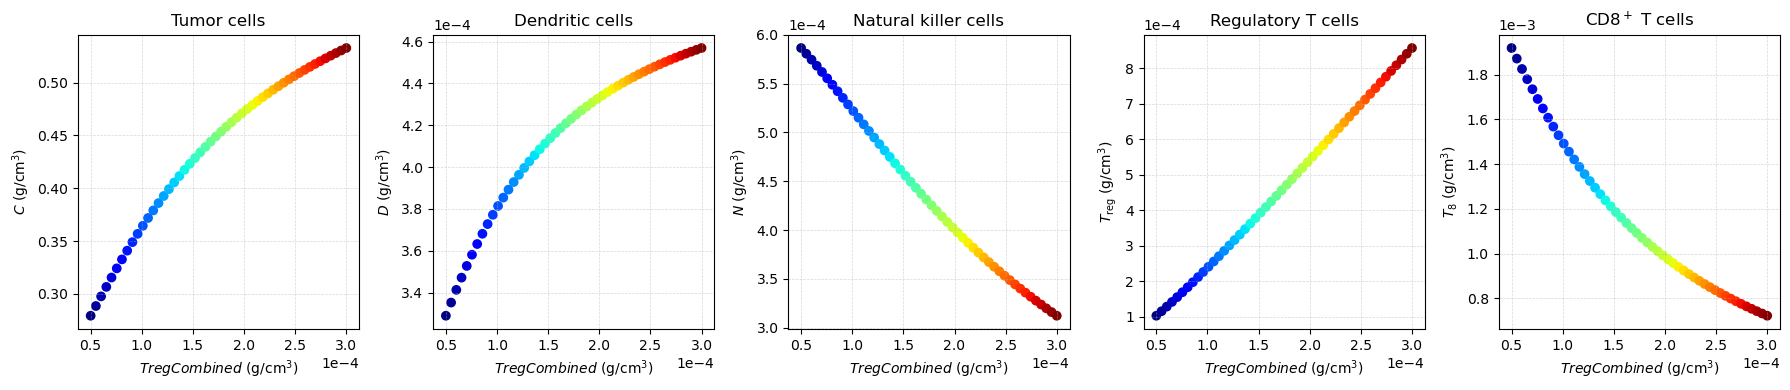

In [19]:
# =========================================================
# PART 2: Fix T80, sweep T10
# =========================================================

params["lambda_T8_comb"] = 0.00108
Treg_space = np.linspace(5e-5, 3e-4, 50)

C_vals = []
D_vals = []
N_vals = []
Treg_vals = []
T8_vals = []

for Treg_val in Treg_space:

    params["lambda_Tr_comb"] = Treg_val

    t, y = simulate(params)

    C_vals.append(y[0][-1])
    D_vals.append(y[1][-1])
    N_vals.append(y[2][-1])
    Treg_vals.append(y[3][-1])
    T8_vals.append(y[4][-1])

# The final code

import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

cmap = plt.cm.jet
colors = cmap((Treg_space - Treg_space.min()) / (Treg_space.max() - Treg_space.min()))

datasets = [
    (C_vals,    "Tumor cells",         r"$C$ (g/cm$^3$)"),
    (D_vals,    "Dendritic cells",      r"$D$ (g/cm$^3$)"),
    (N_vals,    "Natural killer cells", r"$N$ (g/cm$^3$)"),
    (Treg_vals, "Regulatory T cells",  r"$T_{\rm reg}$ (g/cm$^3$)"),
    (T8_vals,   "CD8$^+$ T cells",     r"$T_8$ (g/cm$^3$)"),
]

for ax, (yvals, title, ylabel) in zip(axes, datasets):
    ax.scatter(Treg_space, yvals, c=colors)
    ax.set_title(title)
    ax.set_xlabel(r"$T{regCombined}$ (g/cm$^3$)")
    ax.set_ylabel(ylabel)
    # Format both axes as a×10^n whenever values are very small or very large
    ax.ticklabel_format(style="sci", axis="both", scilimits=(-3, 3))
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('Model1_Figure_1b.png')
plt.show()


### Two parameter space¶

In [9]:
# Run the baseline model:
# baseline simulation
t, y = simulate(params)
baseline = y[:, -1]   # [C, D, N, Treg, T8]

# Define parameter space
lambda_T8_space = np.linspace(5e-6, 3e-5, 50)
T80_space = np.linspace(1e-4, 6e-4, 50)

# Store composite index
EC = np.zeros((len(Treg_space), len(lambda_T8_space)))
ED = np.zeros_like(EC)
EN = np.zeros_like(EC)
ETr = np.zeros_like(EC)
ET8 = np.zeros_like(EC)

# Run the sweep
for i, Tr_val in enumerate(Treg_space):
    for j, T8_val in enumerate(lambda_T8_space):

        p = params.copy()  # avoid overwriting the base params

        # update parameters
        p["lambda_Tr_comb"] = Tr_val
        p["lambda_T8_comb"] = T8_val

        # simulate
        t, y = simulate(p)

        result = y[:, -1]

        # composite index (relative change from baseline)
        EC[i, j]    = (result[0] - baseline[0]) / baseline[0]
        ED[i, j]    = (result[1] - baseline[1]) / baseline[1]
        EN[i, j]    = (result[2] - baseline[2]) / baseline[2]
        ETr[i, j]   = (result[3] - baseline[3]) / baseline[3]
        ET8[i, j]   = (result[4] - baseline[4]) / baseline[4]



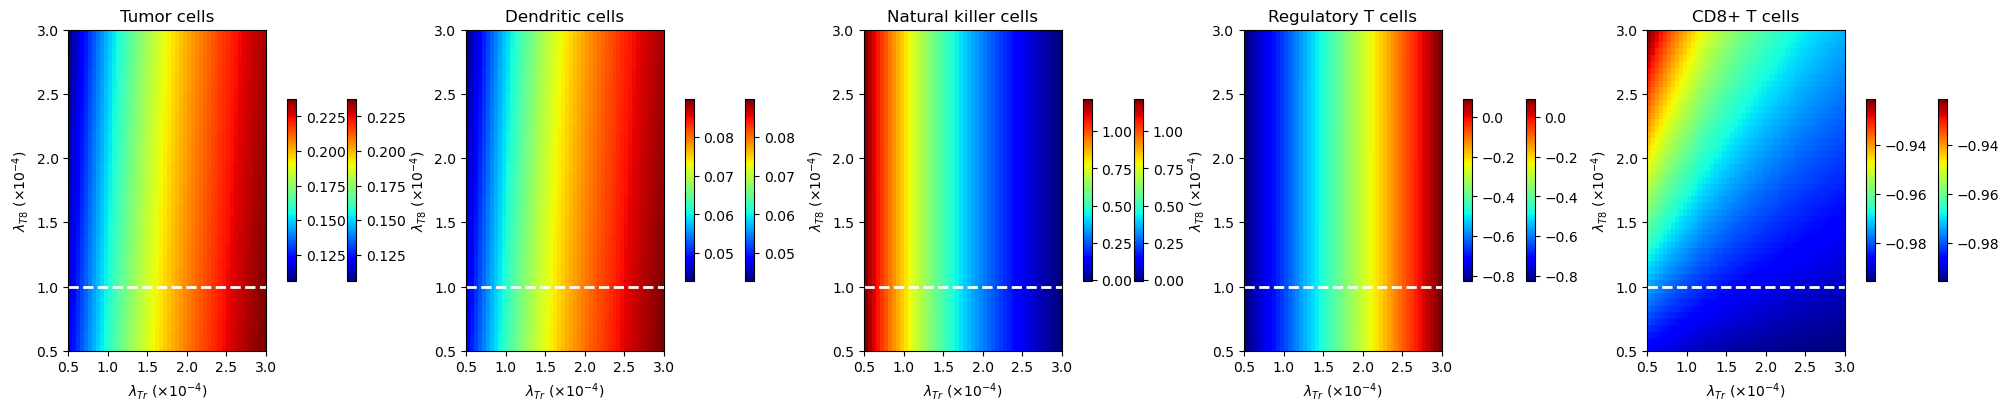

In [10]:
# =========================================================
# Rescale axes
# =========================================================

Tr_scaled = Treg_space / 1e-4
T8_scaled = lambda_T8_space / 1e-5

fig, axes = plt.subplots(1, 5, figsize=(20,4), constrained_layout=True)

extent = [
    Tr_scaled.min(),
    Tr_scaled.max(),
    T8_scaled.min(),
    T8_scaled.max()
]

datasets = [EC, ED, EN, ETr, ET8]
titles = [
    "Tumor cells",
    "Dendritic cells",
    "Natural killer cells",
    "Regulatory T cells",
    "CD8+ T cells"
]

# =========================================================
# Plot heatmaps
# =========================================================
# value of lambda_T8_comb to draw
T8_line = 1e-5 / 1e-5   # scaled coordinate = 0.1

for ax, data, title in zip(axes, datasets, titles):

    im = ax.imshow(
        data.T,
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap="jet",
        interpolation="nearest"
    )

    ax.set_title(title)

    ax.set_xlabel(r"$\lambda_{Tr}$ ($\times10^{-4}$)")
    ax.set_ylabel(r"$\lambda_{T8}$ ($\times10^{-4}$)")

    # adaptive ticks
    ax.set_xticks(np.linspace(Tr_scaled.min(), Tr_scaled.max(), 6))
    ax.set_yticks(np.linspace(T8_scaled.min(), T8_scaled.max(), 6))

    fig.colorbar(im, ax=ax, fraction=0.046)

    # -------------------------------------------------
    # Add horizontal line
    # -------------------------------------------------
    ax.axhline(
        y=T8_line,
        color="white",
        linestyle="--",
        linewidth=2
    )

    fig.colorbar(im, ax=ax, fraction=0.046)
    
plt.savefig("Tr_T8_parameter_space_with_optimized_paramvalue")
plt.show()

### Bifurcation graphs

In [20]:
# Grid search parameter ranges
param_grid = {
    "lambda_DC_comb":[5e-4,7.5e-4,1e-3],
    "sigma_N":[5e-5,1e-4,2e-4,3e-4],
    "lambda_T8_comb":[1e-5,5e-5,1e-4],
    "d_T8":[0.075,0.1,0.18,0.25],
    "K_Tr":[1e-11,1e-8,1e-6],
    "d_N":[0.1,0.15,0.2]
}

In [12]:
# Plot dC and dN
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.integrate import solve_ivp
from tqdm import tqdm # Added for a progress bar!

# ==========================================
# 1. Setup the parameter grid
# ==========================================
param_x_name = "lambda_DC_comb"
param_y_name = 'lambda_T8_comb'

# Create a 50x50 grid (adjust ranges based on your grid search space)
x_vals = np.linspace(5e-4,7.5e-4, 50) 
y_vals = np.linspace(1e-5, 5e-5, 50)

X, Y = np.meshgrid(x_vals, y_vals)
Z_state = np.zeros(X.shape) # To store the state of each point

# ==========================================
# 2. Define Initial Conditions & Thresholds
# ==========================================
# Assuming best_params and cancer_ode are defined above this script
C_M = params['C_M']

# [Tumor, DC, NK, Treg, CD8]
ic_tumor_wins = [C_M, 0.0, 0.0, 0.0, 0.0]
ic_immune_wins = [0.01, 0.01, 0.01, 0.0, 0.01] 

t_long = (0, 1000)
cancer_elimination_threshold = 0.05
state_difference_threshold = 0.1 

# ==========================================
# 3. Iterate through the grid (with progress bar)
# ==========================================
print("Simulating parameter landscape...")

for i in tqdm(range(X.shape[0]), desc="Computing Grid Rows"):
    for j in range(X.shape[1]):
        # Copy base best parameters
        test_params = best_params.copy()
        test_params[param_x_name] = X[i, j]
        test_params[param_y_name] = Y[i, j]
        
        # Run from Tumor Advantage
        sol_tumor = solve_ivp(lambda t, y: cancer_ode(t, y, test_params), 
                              t_long, ic_tumor_wins, method='Radau')
        c_end_tumor = sol_tumor.y[0, -1]
        
        # Run from Immune Advantage
        sol_immune = solve_ivp(lambda t, y: cancer_ode(t, y, test_params), 
                               t_long, ic_immune_wins, method='Radau')
        c_end_immune = sol_immune.y[0, -1]
        
        # 4. Classify the state
        # Z=0 (Escape), Z=1 (Elimination), Z=2 (Bistable)
        if abs(c_end_tumor - c_end_immune) > state_difference_threshold:
            Z_state[i, j] = 2  
        elif c_end_tumor < cancer_elimination_threshold:
            Z_state[i, j] = 1  
        else:
            Z_state[i, j] = 0  

# ==========================================
# 5. Plot the landscape
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

# Custom colormap matching your requested colors
# 0 = Yellow (Escape), 1 = Pink (Elimination), 2 = Cyan (Bistable)
colors_list = ['yellow', 'pink', 'cyan']
cmap = ListedColormap(colors_list)

# Plot the contour map
c = ax.contourf(X, Y, Z_state, levels=[-0.5, 0.5, 1.5, 2.5], colors=colors_list, alpha=0.8)

# Plot the fine-tuned fitted parameter
ax.scatter(best_params[param_x_name], best_params[param_y_name], 
           color='gold', edgecolors='black', s=250, marker='*', zorder=5, 
           label='Fitted Parameters')

# Add custom legend patches
escape_patch = mpatches.Patch(color='yellow', label='Tumor Escape (Monostable)')
elim_patch = mpatches.Patch(color='pink', label='Tumor Elimination (Monostable)')
bistable_patch = mpatches.Patch(color='cyan', label='Bistable Region')

# Included the scatter plot star in the legend via ax.get_legend_handles_labels()
handles = [escape_patch, elim_patch, bistable_patch]
scatter_handle, scatter_label = ax.get_legend_handles_labels()
if scatter_handle:
    handles.append(scatter_handle[0])

ax.legend(handles=handles, loc='upper right', framealpha=0.9)

# Format Axes
ax.set_xlabel(f"{param_x_name} (Immune Activation)", fontsize=12)
ax.set_ylabel(f"{param_y_name} (Immune Suppression)", fontsize=12)
ax.set_title("Parameter Space Landscape & Bistability", fontsize=14, pad=15)

# Optional: Force scientific notation on axes for cleaner reading
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

plt.tight_layout()
plt.show()

Simulating parameter landscape...


Computing Grid Rows:   0%|                                                                       | 0/50 [00:00<?, ?it/s]


NameError: name 'best_params' is not defined

In [ ]:
# Plot dC and dN
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.integrate import solve_ivp
from tqdm import tqdm # Added for a progress bar!

# ==========================================
# 1. Setup the parameter grid
# ==========================================
param_x_name = "lambda_DC_comb"
param_y_name = 'lambda_T8_comb'

# Create a 50x50 grid (adjust ranges based on your grid search space)
x_vals = np.linspace(5e-4,7.5e-4, 50) 
y_vals = np.linspace(1e-5, 5e-5, 50)

X, Y = np.meshgrid(x_vals, y_vals)
Z_state = np.zeros(X.shape) # To store the state of each point

# ==========================================
# 2. Define Initial Conditions & Thresholds
# ==========================================
# params and ode_system are defined above this script
C_M = params['C_M']

# [Tumor, DC, NK, Treg, CD8]
ic_tumor_wins = [C_M, 0.0, 0.0, 0.0, 0.0]
ic_immune_wins = [0.01, 0.01, 0.01, 0.0, 0.01] 

t_long = (0, 1000)
cancer_elimination_threshold = 0.05
state_difference_threshold = 0.1 

# ==========================================
# 3. Iterate through the grid (with progress bar)
# ==========================================
print("Simulating parameter landscape...")

for i in tqdm(range(X.shape[0]), desc="Computing Grid Rows"):
    for j in range(X.shape[1]):
        # Copy parameters
        test_params = params.copy()
        test_params[param_x_name] = X[i, j]
        test_params[param_y_name] = Y[i, j]
        
        # Run from Tumor Advantage
        sol_tumor = solve_ivp(lambda t, y: ode_system(t, y, test_params), 
                              t_long, ic_tumor_wins, method='Radau')
        c_end_tumor = sol_tumor.y[0, -1]
        
        # Run from Immune Advantage
        sol_immune = solve_ivp(lambda t, y: ode_system(t, y, test_params), 
                               t_long, ic_immune_wins, method='Radau')
        c_end_immune = sol_immune.y[0, -1]
        
        # 4. Classify the state
        # Z=0 (Escape), Z=1 (Elimination), Z=2 (Bistable)
        if abs(c_end_tumor - c_end_immune) > state_difference_threshold:
            Z_state[i, j] = 2  
        elif c_end_tumor < cancer_elimination_threshold:
            Z_state[i, j] = 1  
        else:
            Z_state[i, j] = 0  

# ==========================================
# 5. Plot the landscape
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

# Custom colormap matching your requested colors
# 0 = Yellow (Escape), 1 = Pink (Elimination), 2 = Cyan (Bistable)
colors_list = ['yellow', 'pink', 'cyan']
cmap = ListedColormap(colors_list)

# Plot the contour map
c = ax.contourf(X, Y, Z_state, levels=[-0.5, 0.5, 1.5, 2.5], colors=colors_list, alpha=0.8)

# Plot the fine-tuned fitted parameter
ax.scatter(params[param_x_name], params[param_y_name], 
           color='gold', edgecolors='black', s=250, marker='*', zorder=5, 
           label='Fitted Parameters')

# Add custom legend patches
escape_patch = mpatches.Patch(color='yellow', label='Tumor Escape (Monostable)')
elim_patch = mpatches.Patch(color='pink', label='Tumor Elimination (Monostable)')
bistable_patch = mpatches.Patch(color='cyan', label='Bistable Region')

# Included the scatter plot star in the legend via ax.get_legend_handles_labels()
handles = [escape_patch, elim_patch, bistable_patch]
scatter_handle, scatter_label = ax.get_legend_handles_labels()
if scatter_handle:
    handles.append(scatter_handle[0])

ax.legend(handles=handles, loc='upper right', framealpha=0.9)

# Format Axes
ax.set_xlabel(f"{param_x_name} (Immune Activation)", fontsize=12)
ax.set_ylabel(f"{param_y_name} (Immune Suppression)", fontsize=12)
ax.set_title("Parameter Space Landscape & Bistability", fontsize=14, pad=15)

# Optional: Force scientific notation on axes for cleaner reading
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Base Parameters Dictionary
best_params = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300, "d_C": 0.17,
    "lambda_DC_comb": 8e-5, "K_C": 0.4, "d_D": 0.1,
    "sigma_N": 5e-5, "d_N": 0.1, "gamma_N": 150, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    "d_Tr": 0.2, "lambda_Tr_comb": 2e-4,
    "d_T8": 0.18, "lambda_T8_comb": 0.00108, "K_Tr": 2.5e-4, "K_D": 4e-4
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# =============================================================================
# Plot (B): Bifurcation diagrams with changes in sigma_N
# =============================================================================
CM_list = [0.8, 2.7, 5.0]
colors_B = ['magenta', 'lime', 'orange']

for cm_val, color in zip(CM_list, colors_B):
    p = best_params
    # Sweep C from almost zero up to the carrying capacity
    C_v = np.linspace(1e-5, cm_val * 0.999, 2000)
    
    # Compute steady states of D, Tr, and T8 based on C (Eq B.4, B.5, B.6)
    D = (p["lambda_DC_comb"] / p["d_D"]) * (C_v / (C_v + p["K_C"]))
    Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C_v / (C_v + p["K_C"]))
    T8 = (p["lambda_T8_comb"] / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
    
    # Calculate N from dC/dt = 0 (Eq B.7)
    N = (p["lambda_C"] * (1 - C_v/cm_val) - p["eta_8"]*T8 - p["d_C"]) / p["eta_N"]
    
    # Filter out biologically impossible (negative) states
    valid = N > 0
    C_v, N, Tr = C_v[valid], N[valid], Tr[valid]
    
    # Calculate exactly what sigma_N must be for this state (Eq B.8)
    sigma_N = p["d_N"]*N + p["gamma_N"]*Tr*N - p["a_C"]*N*C_v / (1 + C_v/p["beta_1"] + N/p["beta_2"])
    
    # Stability Check: For a sigma_N vs C plot, a negative derivative is stable
    d_sig_dC = np.gradient(sigma_N, C_v)
    is_stable = d_sig_dC < 0
    
    # Plot segments (solid for stable, dotted for unstable)
    splits = [0] + list(np.where(is_stable[:-1] != is_stable[1:])[0] + 1) + [len(C_v)]
    for i in range(len(splits) - 1):
        start, end = splits[i], splits[i+1]
        end_plot = end + 1 if end < len(C_v) else end # Connect lines seamlessly
        ls = '-' if is_stable[start] else ':'
        label = f"$C_M$ = {cm_val}" if i == 0 else ""
        ax1.plot(sigma_N[start:end_plot], C_v[start:end_plot], color=color, ls=ls, lw=2, label=label)

ax1.set_xlim(3e-4, 5e-4)
ax1.set_ylim(0, 1.8)
ax1.set_xlabel(r"$\sigma_N$ (g/cm$^3 \cdot$ day)", fontsize=12)
ax1.set_ylabel(r"$C$ (g/cm$^3$)", fontsize=12)
ax1.set_title("(B)", loc='left', fontsize=16)

# Format x-axis with scientific MathText
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-4, -4)) # Forces the multiplier to 10^-4
ax1.xaxis.set_major_formatter(formatter)

# Improve legend
ax1.legend(title="Carrying capacity", loc='upper right', framealpha=0.9)

# =============================================================================
# Plot (C): Bifurcation diagrams with changes in C_M
# =============================================================================
sigma_N_list = [0.00035, 0.00043, 0.00047, 5e-5]
colors_C = ['magenta', 'lime', 'orange', 'black']

for sig_val, color in zip(sigma_N_list, colors_C):
    p = best_params
    # Sweep C a bit higher to capture the whole top branch
    C_v = np.linspace(1e-5, 2.2, 3000) 
    
    D = (p["lambda_DC_comb"] / p["d_D"]) * (C_v / (C_v + p["K_C"]))
    Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C_v / (C_v + p["K_C"]))
    T8 = (p["lambda_T8_comb"] / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
    
    # Calculate N using the quadratic root from dN/dt = 0
    A = 1 + C_v / p["beta_1"]
    E = p["d_N"] + p["gamma_N"] * Tr
    c2 = -E / p["beta_2"]
    c1 = (sig_val / p["beta_2"]) - (E * A) + (p["a_C"] * C_v)
    c0 = sig_val * A
    
    N = (-c1 - np.sqrt(c1**2 - 4*c2*c0)) / (2*c2)
    
    # Calculate C_M from dC/dt = 0 by isolating C_M
    denom = p["lambda_C"] - p["eta_N"]*N - p["eta_8"]*T8 - p["d_C"]
    
    valid = denom > 0
    C_v, denom = C_v[valid], denom[valid]
    
    CM_v = p["lambda_C"] * C_v / denom
    
    # Stability Check: For a C_M vs C plot, a positive derivative is stable
    d_CM_dC = np.gradient(CM_v, C_v)
    is_stable = d_CM_dC > 0
    
    # Plot segments
    splits = [0] + list(np.where(is_stable[:-1] != is_stable[1:])[0] + 1) + [len(C_v)]
    for i in range(len(splits) - 1):
        start, end = splits[i], splits[i+1]
        end_plot = end + 1 if end < len(C_v) else end
        ls = '-' if is_stable[start] else ':'
        label = f"$\sigma_N$ = {sig_val}" if i == 0 else ""
        ax2.plot(CM_v[start:end_plot], C_v[start:end_plot], color=color, ls=ls, lw=2, label=label)

ax2.set_xlim(0, 8)
ax2.set_ylim(0, 2.2)
ax2.set_xlabel(r"$C_M$ (g/cm$^3$)", fontsize=12)
ax2.set_ylabel(r"$C$ (g/cm$^3$)", fontsize=12)
ax2.set_title("(C)", loc='left', fontsize=16)
ax2.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

### Visualize the parameters for different conditions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. Fitted Treatment Data
# ==========================================
# Data format: [ICB, ICB+UV, ICB+Apobec]
lambda_T8 = [0.0001, 0.001, 0.001]
lambda_DC = [0.002, 0.002, 0.003]
sigma_N =   [0.0004, 0.0002, 0.0005] # Using 0.0005 based on the uploaded table

labels = ['ICB Alone', 'ICB + UV', 'ICB + Apobec']
colors = ['red', 'blue', 'green']

# ==========================================
# 2. Setup 3D Plot
# ==========================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the treatment trajectory line
ax.plot(lambda_DC, lambda_T8, sigma_N, color='black', linestyle='--', alpha=0.5, zorder=1)

# Plot the fitted points as stars
for i in range(3):
    ax.scatter(lambda_DC[i], lambda_T8[i], sigma_N[i], 
               color=colors[i], marker='*', s=300, edgecolor='black', 
               label=labels[i], zorder=5)
    
    # Add text labels slightly offset from the points
    ax.text(lambda_DC[i], lambda_T8[i], sigma_N[i] + 0.00002, 
            labels[i], fontsize=10, weight='bold', zorder=6)

# ==========================================
# 3. Add the Theorem 3 Stability Threshold Plane (Optional but recommended)
# ==========================================
# From Theorem 3: stability requires sigma_N > (lambda_C - d_C) * d_N / eta_N
# (Assuming baseline params: lambda_C=1.5, d_C=0.17, d_N=0.1, eta_N=300)
threshold_sigma_N = (1.5 - 0.17) * 0.1 / 300  # ≈ 0.00044

# Create a grid for the plane
xx, yy = np.meshgrid(np.linspace(0.0015, 0.0035, 10), np.linspace(0, 0.0012, 10))
zz = np.full_like(xx, threshold_sigma_N)

# Plot the transparent plane
surf = ax.plot_surface(xx, yy, zz, color='cyan', alpha=0.2, zorder=0)

# ==========================================
# 4. Formatting & Labels
# ==========================================
ax.set_xlabel(r'$\lambda_{DC}^{comb}$ (DC Activation)', fontsize=11, labelpad=10)
ax.set_ylabel(r'$\lambda_{T8}^{comb}$ (T8 Priming)', fontsize=11, labelpad=10)
ax.set_zlabel(r'$\sigma_N$ (NK Influx)', fontsize=11, labelpad=10)
ax.set_title("Treatment Trajectories in Parameter Space\n(Cyan plane = Theorem 3 Tumor-Free Stability Threshold)", fontsize=14)

# Format axes to use scientific notation nicely (like you did before)
ax.ticklabel_format(style='sci', axis='both', scilimits=(-3,-3))

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ==========================================
# 1. Base Parameters Dictionary
# ==========================================
best_params = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300, "d_C": 0.17,
    "K_C": 0.4, "d_D": 0.1, "d_N": 0.1, "gamma_N": 150, "a_C": 0.5, 
    "beta_1": 0.4, "beta_2": 2e-4, "d_Tr": 0.2, "lambda_Tr_comb": 2e-4,
    "d_T8": 0.18, "K_Tr": 2.5e-4, "K_D": 4e-4
}
p = best_params

# Treatment Data: [lambda_DC, lambda_T8, sigma_N]
# P1 = ICB, P2 = ICB+UV, P3 = ICB+Apobec
P1 = np.array([0.002, 0.0001, 0.0004])
P2 = np.array([0.002, 0.001,  0.0002])
P3 = np.array([0.003, 0.001,  0.0005])

labels = ['ICB', 'ICB+UV', 'ICB+Apobec']
colors = ['red', 'blue', 'green']

# ==========================================
# 2. Define the Custom 2D Plane (Gram-Schmidt)
# ==========================================
# Create two vectors on the plane starting from P1
V1 = P2 - P1
V2 = P3 - P1

# Make them orthogonal to act as our 2D X and Y axes
U1 = V1 / np.linalg.norm(V1)
V2_perp = V2 - np.dot(V2, U1) * U1
U2 = V2_perp / np.linalg.norm(V2_perp)

# Function to project 3D points onto our new 2D plane
def project_to_2d(pt):
    vec = pt - P1
    return np.array([np.dot(vec, U1), np.dot(vec, U2)])

proj_P1 = project_to_2d(P1)
proj_P2 = project_to_2d(P2)
proj_P3 = project_to_2d(P3)

# Define grid boundaries in the local 2D space (padding around the points)
x_min = min(proj_P1[0], proj_P2[0], proj_P3[0]) - 0.0003
x_max = max(proj_P1[0], proj_P2[0], proj_P3[0]) + 0.0003
y_min = min(proj_P1[1], proj_P2[1], proj_P3[1]) - 0.0003
y_max = max(proj_P1[1], proj_P2[1], proj_P3[1]) + 0.0003

# ==========================================
# 3. Vectorized Root Finding on the Plane
# ==========================================
res = 200 # High resolution for smooth boundaries
X, Y = np.meshgrid(np.linspace(x_min, x_max, res), np.linspace(y_min, y_max, res))

# Map the 2D grid back to 3D parameter space
LDC_grid = P1[0] + X * U1[0] + Y * U2[0]
LT8_grid = P1[1] + X * U1[1] + Y * U2[1]
SN_grid  = P1[2] + X * U1[2] + Y * U2[2]

# Ensure parameters don't dip below zero due to grid padding
LDC_grid = np.clip(LDC_grid, 1e-8, None)
LT8_grid = np.clip(LT8_grid, 1e-8, None)
SN_grid  = np.clip(SN_grid, 1e-8, None)

LDC_f = LDC_grid.flatten()[:, np.newaxis]
LT8_f = LT8_grid.flatten()[:, np.newaxis]
SN_f  = SN_grid.flatten()[:, np.newaxis]

# Sweep C (using ultra-high resolution to catch the thin fold boundaries)
C_M = p["C_M"]
C = np.linspace(1e-5, C_M * 0.999, 3000)[np.newaxis, :] 

# Master Equations
D = (LDC_f / p["d_D"]) * (C / (C + p["K_C"]))
Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C / (C + p["K_C"]))
T8 = (LT8_f / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
N_star = (p["lambda_C"] * (1 - C/C_M) - p["eta_8"]*T8 - p["d_C"]) / p["eta_N"]

term1 = SN_f
term2 = p["a_C"] * N_star * (C / (1 + C/p["beta_1"] + N_star/p["beta_2"]))
term3 = - p["gamma_N"] * Tr * N_star
term4 = - p["d_N"] * N_star
f_C = term1 + term2 + term3 + term4

# Count zero crossings to find the number of positive steady states
# Counts how many times the f_C curve crosses the zero line. 
roots_count = np.sum(np.diff(np.sign(f_C), axis=1) != 0, axis=1)
roots_grid = roots_count.reshape((res, res))

# Map to requested colors: 1 root -> 0 (Magenta), 2 roots -> 1 (Cyan), 3 roots -> 2 (Yellow)
color_map_grid = np.zeros_like(roots_grid)
color_map_grid[roots_grid <= 1] = 0
color_map_grid[roots_grid == 2] = 1
color_map_grid[roots_grid >= 3] = 2

# ==========================================
# 4. Plotting the 2D Slice
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))

# Apply your exact color code
cmap = ListedColormap(['magenta', 'cyan', 'yellow'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# Plot the landscape
c = ax.pcolormesh(X, Y, color_map_grid, cmap=cmap, norm=norm, shading='auto', alpha=0.7)

# Plot the treatment trajectory
trajs_X = [proj_P1[0], proj_P2[0], proj_P3[0]]
trajs_Y = [proj_P1[1], proj_P2[1], proj_P3[1]]
ax.plot(trajs_X, trajs_Y, color='black', linestyle='--', linewidth=2, zorder=5)

# Plot the treatment stars
for i, pt in enumerate([proj_P1, proj_P2, proj_P3]):
    ax.scatter(pt[0], pt[1], color=colors[i], marker='*', s=300, edgecolor='black', zorder=10)
    # Adding a text box with the true 3D parameters for clarity
    true_pt = [P1, P2, P3][i]
    label_text = f"{labels[i]}\nL_DC: {true_pt[0]}\nL_T8: {true_pt[1]}\nS_N: {true_pt[2]}"
    ax.text(pt[0] + 0.00005, pt[1] - 0.0001, label_text, fontsize=9, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Formatting
ax.set_title("2D Cross-Section of Parameter Space Traversing All Treatments", fontsize=14, pad=15)
ax.set_xlabel("Local X (Direction: ICB to ICB+UV)")
ax.set_ylabel("Local Y (Orthogonal Axis toward Apobec)")

# Create custom legend for the regions
import matplotlib.patches as mpatches
mag_patch = mpatches.Patch(color='magenta', alpha=0.7, label='1 Positive Steady State (Monostable)')
cya_patch = mpatches.Patch(color='cyan', alpha=0.7, label='2 Positive Steady States (Saddle-Node)')
yel_patch = mpatches.Patch(color='yellow', alpha=0.7, label='3 Positive Steady States (Bistable)')
ax.legend(handles=[mag_patch, cya_patch, yel_patch], loc='lower right')

plt.tight_layout()
plt.show()

2D bifurcation analysis of tumor-immune interaction, covering three parameter spaces (lambda_DC_comb, lambda_T8_comb, sigma_N). Three specific parameter combinations were plotted as points, for "Untreated", "Treated with ICB" and "Treated with ICB+APOBEC".
Ideally, the treatment "landscape" would exist in a 3D space. However, the occlusion could be an issue for result interpretation. 
Therefore, I used linear algrebra to slice a 2D plane through all these treatment points. 
Then, we scanned through the 2D slice and solved the steady-state equations at every grid poinnt, and mapped whether the tumor immune system is monostable (deterministic outcome) or bistable (outcome depends on initial tumor size), plotting trajectory across this landscape. 
Color code: 
1. Magenta (Monostable): tumor dominance
2. Yellow (Saddle-node boundary): the phase transition zone. This region is transitional.
3. Cyan (2 Positive equilibria): The outcome depends on the initial tumor burden (high tumor load initially -> tumor escape; low tumor burden -> immune control; unstable state - tipping point)

In [ ]:
# Diagram comparing untreated, ICB-treated and ICB+APOBEC groups
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# ==========================================
# 1. Base Parameters Dictionary. Fix the parameters that don't change between different parameters
# ==========================================
best_params = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300, "d_C": 0.17,
    "K_C": 0.4, "d_D": 0.1, "d_N": 0.1, "gamma_N": 150, "a_C": 0.5, 
    "beta_1": 0.4, "beta_2": 2e-4, "d_Tr": 0.2, "lambda_Tr_comb": 2e-4,
    "d_T8": 0.18, "K_Tr": 2.5e-4, "K_D": 4e-4
}
p = best_params

# Define the Treatment Data [lambda_DC, lambda_T8, sigma_N] to the three conditions (Untreated, ICB, ICB+APOBEC)

# P1 = Untreated (Index 0), P2 = ICB (Index 1), P3 = ICB+APOBEC (Index 3)
P1 = np.array([0.0025, 0.0001, 0.0003]) # Untreated
P2 = np.array([0.002, 0.0001, 0.0004]) # ICB
P3 = np.array([0.003, 0.001, 0.0005]) # ICB+APOBEC

labels = ['Untreated', 'ICB', 'ICB+APOBEC']
colors = ['black', 'red', 'green']

# ==========================================
# 2. Define the Custom 2D Plane (Gram-Schmidt). Dimensionality reduction
# ==========================================
# Create two vectors on the plane starting from Untreated (P1)
V1 = P2 - P1
V2 = P3 - P1

# Make them orthogonal to act as our 2D X and Y axes
# Creates two direction vectors starting from P1. V1 points to P2, and V2 points to P3. 
U1 = V1 / np.linalg.norm(V1) # Becomes the horizontal axis
V2_perp = V2 - np.dot(V2, U1) * U1 # V2_perp removes any part of V2 that overlaps with U1 -> ensure the new axes are orthogonal
U2 = V2_perp / np.linalg.norm(V2_perp) # Becomes the vertical axis

# Function to project 3D points onto our new 2D plane
def project_to_2d(pt):
    vec = pt - P1
    return np.array([np.dot(vec, U1), np.dot(vec, U2)])

proj_P1 = project_to_2d(P1)
proj_P2 = project_to_2d(P2)
proj_P3 = project_to_2d(P3)

# Define grid boundaries in the local 2D space (padding around the points)
x_min = min(proj_P1[0], proj_P2[0], proj_P3[0]) - 0.0003
x_max = max(proj_P1[0], proj_P2[0], proj_P3[0]) + 0.0003
y_min = min(proj_P1[1], proj_P2[1], proj_P3[1]) - 0.0003
y_max = max(proj_P1[1], proj_P2[1], proj_P3[1]) + 0.0003

# ==========================================
# 3. Vectorized Root Finding on the Plane
# We found steady states algebraically
# ==========================================
res = 200 # High resolution for smooth boundaries
X, Y = np.meshgrid(np.linspace(x_min, x_max, res), np.linspace(y_min, y_max, res))

# Map the 2D grid back to 3D parameter space -  so that we can plug the parameters into the biological equations
LDC_grid = P1[0] + X * U1[0] + Y * U2[0]
LT8_grid = P1[1] + X * U1[1] + Y * U2[1]
SN_grid  = P1[2] + X * U1[2] + Y * U2[2]

# Ensure parameters don't dip below zero due to grid padding
LDC_grid = np.clip(LDC_grid, 1e-8, None)
LT8_grid = np.clip(LT8_grid, 1e-8, None)
SN_grid  = np.clip(SN_grid, 1e-8, None)

LDC_f = LDC_grid.flatten()[:, np.newaxis]
LT8_f = LT8_grid.flatten()[:, np.newaxis]
SN_f  = SN_grid.flatten()[:, np.newaxis]

# Sweep C (using high resolution to catch the thin fold boundaries)
# Through algebra, we reduced the 5=-
C_M = p["C_M"]
C = np.linspace(1e-5, C_M * 0.999, 3000)[np.newaxis, :] 

# Master Equations
D = (LDC_f / p["d_D"]) * (C / (C + p["K_C"]))
Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C / (C + p["K_C"]))
T8 = (LT8_f / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
N_star = (p["lambda_C"] * (1 - C/C_M) - p["eta_8"]*T8 - p["d_C"]) / p["eta_N"]

term1 = SN_f
term2 = p["a_C"] * N_star * (C / (1 + C/p["beta_1"] + N_star/p["beta_2"])) 
term3 = - p["gamma_N"] * Tr * N_star
term4 = - p["d_N"] * N_star
f_C = term1 + term2 + term3 + term4

# Count zero crossings to find the number of positive steady states
roots_count = np.sum(np.diff(np.sign(f_C), axis=1) != 0, axis=1) # The f_C 
roots_grid = roots_count.reshape((res, res))

# Map to requested colors: 1 root -> 0 (Magenta), 2 roots -> 1 (Cyan), 3 roots -> 2 (Yellow)
color_map_grid = np.zeros_like(roots_grid)
color_map_grid[roots_grid <= 1] = 0
color_map_grid[roots_grid == 2] = 1
color_map_grid[roots_grid >= 3] = 2

# ==========================================
# 4. Plotting the 2D Slice
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))

# Apply the color code
cmap = ListedColormap(['magenta', 'cyan', 'yellow'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# Plot the landscape
c = ax.pcolormesh(X, Y, color_map_grid, cmap=cmap, norm=norm, shading='auto', alpha=0.7)

# Plot the treatment trajectory paths
trajs_X = [proj_P1[0], proj_P2[0], proj_P3[0]]
trajs_Y = [proj_P1[1], proj_P2[1], proj_P3[1]]
ax.plot(trajs_X[:2], trajs_Y[:2], color='black', linestyle='-', linewidth=2, zorder=5, label='Untreated to ICB')
ax.plot(trajs_X[1:], trajs_Y[1:], color='black', linestyle='--', linewidth=2, zorder=5, label='ICB to Combination')

# Plot the treatment stars
for i, pt in enumerate([proj_P1, proj_P2, proj_P3]):
    ax.scatter(pt[0], pt[1], color=colors[i], marker='*', s=300, edgecolor='white', linewidth=1.5, zorder=10)
    
    # Adding a text box with the true 3D parameters for clarity
    true_pt = [P1, P2, P3][i]
    label_text = f"{labels[i]}\n$L_{{DC}}$: {true_pt[0]}\n$L_{{T8}}$: {true_pt[1]}\n$S_N$: {true_pt[2]}"
    ax.text(pt[0] + 0.00005, pt[1] - 0.00008, label_text, fontsize=9, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3'))

# Formatting
ax.set_title("2D Equilibrium Landscape: Untreated $\\rightarrow$ ICB $\\rightarrow$ ICB+APOBEC", fontsize=14, pad=15)
ax.set_xlabel("Local X Axis (Direction: Untreated to ICB)")
ax.set_ylabel("Local Y Axis (Orthogonal Direction toward APOBEC)")

# Create custom legend for the regions
mag_patch = mpatches.Patch(color='magenta', alpha=0.7, label='1 Positive Steady State (Monostable)')
cya_patch = mpatches.Patch(color='cyan', alpha=0.7, label='2 Positive Steady States (Saddle-Node)')
yel_patch = mpatches.Patch(color='yellow', alpha=0.7, label='3 Positive Steady States (Bistable)')
ax.legend(handles=[mag_patch, cya_patch, yel_patch], loc='lower right')

plt.tight_layout()
plt.show()

# Investigate the optimal time-course of APOBEC treatment

Define the maximum parameter shifts as 2x(APOBEC - ICB)
(Assume that, the maximum dose of APOBEC is 2X the current level; 
Applying it can result in 2X the parameter shift from what we found)

In [ ]:
As the paper, use the forward-backward seep method
Reason: 
State equations run forward in time; adjoint equations run backward in time

Replicate the paper's model with initial values in the paper. 
However, use simplified ODE we developed. 

Starting Forward-Backward Sweep Method...
Iteration 25, Error: 0.01872
Iteration 50, Error: 0.01005
Iteration 75, Error: 0.00564
Iteration 100, Error: 0.00324
Iteration 125, Error: 0.00187
Iteration 150, Error: 0.00109
Iteration 175, Error: 0.00063
Iteration 200, Error: 0.00037
Iteration 225, Error: 0.00021
Iteration 250, Error: 0.00012
Converged in 260 iterations.


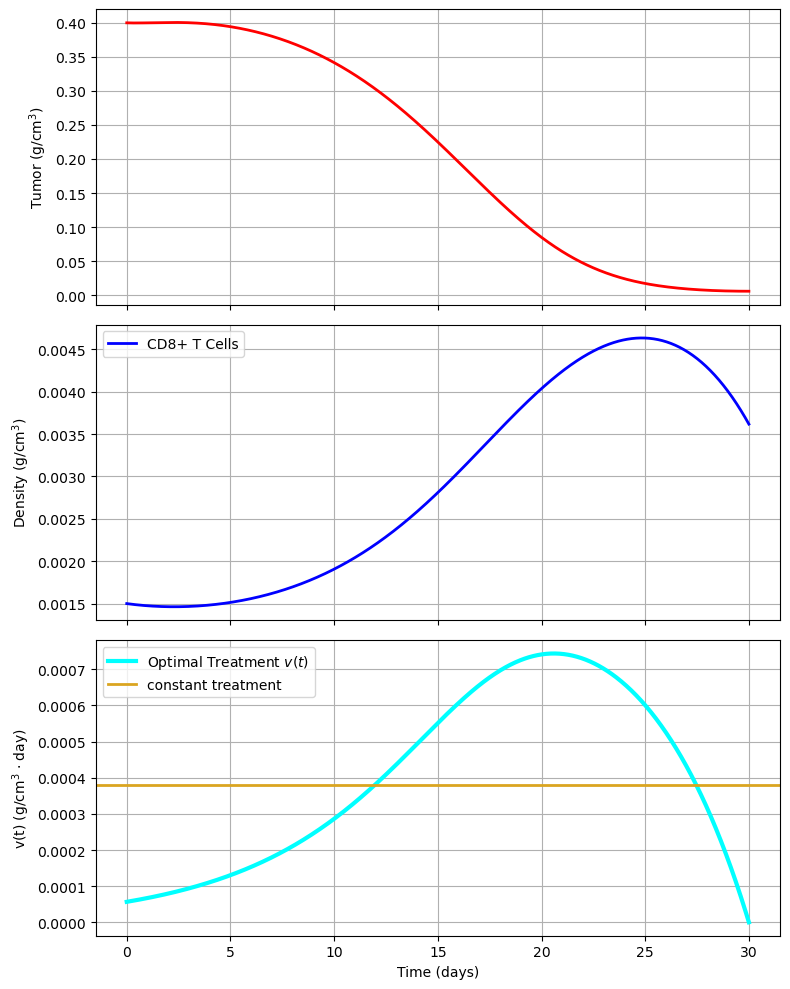

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (Strictly from Table 1)
# Stores the constant biologial rates that don't chnage between treatments. 
# ==========================================
p = {
    # Tumor
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    # DCs (L_DC = lambda_DC * D_0 = 4 * 2e-5)
    "L_DC": 8e-5, "K_C": 0.4, "d_D": 0.1,
    # NK cells
    "sigma_N": 5e-5, "d_N": 0.1, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    # Tregs (L_Tr = lambda_Tr * T_10 = 0.5 * 4e-4)
    "d_Treg": 0.2, "L_Tr": 2e-4, 
    # CD8 T cells (L_T8 = lambda_T8 * T_80 = 5.4 * 2e-4)
    "d_T8": 0.18, "L_T8": 1.08e-3, "K_Treg": 2.5e-4, "K_D": 4e-4
}

# Optimization Weights (From Paper)
a = 5000.0     # Penalty for drug injection
b = 0.0001     # Continuous penalty for tumor burden

# Time Grid (30 Days)
T_final = 30.0       
N_steps = 1000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)

# ==========================================
# 2. Derivative Functions for RK4
# ==========================================
def state_derivatives(x, v_val):
    C, D, N, Tr, T8 = x
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["L_DC"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["L_Tr"] * C / (p["K_C"] + C)
    
    # Notice v_val is now an additive infusion term here
    dT8 = -p["d_T8"]*T8 + p["L_T8"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, v_val):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    # Notice the 'b' term added to the dl1 equation
    dl1 = -( b + l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["L_DC"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["L_Tr"] * p["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*p["d_D"] + l5*(p["L_T8"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*p["d_Treg"] + l5*(p["L_T8"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] ) 
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Initialization & FBSM Loop
# ==========================================
x = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))

# Initial Conditions (From Table 2)
x[:, 0] = [0.4, 0.0004, 0.0003, 0.0005, 0.0015] 
v = np.zeros(N_steps)

tolerance = 1e-4
max_iter = 500
test = tolerance + 1
iteration = 0

print("Starting Forward-Backward Sweep Method...")

while test > tolerance and iteration < max_iter:
    old_v, old_x, old_lam = v.copy(), x.copy(), lam.copy()
    
    # --- STEP A: FORWARD SWEEP ---
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v[i] + v[i+1])
        current_x = np.maximum(x[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1])
        
        x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
        
    # --- STEP B: BACKWARD SWEEP ---
    # Transversality: Penalizing terminal tumor burden
    lam[:, -1] = 0.0
    lam[0, -1] = 1.0 
    
    for i in range(N_steps - 1, 0, -1):
        v_mid = 0.5 * (v[i] + v[i-1])
        x_mid = 0.5 * (x[:, i] + x[:, i-1])
        
        k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], v[i])
        k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, v_mid)
        k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, v_mid)
        k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, v[i-1])
        
        lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
    # --- STEP C: CONTROL UPDATE ---
    v_new = np.zeros(N_steps)
    for i in range(N_steps):
        # Optimal Control Law from paper: unconstrained to allow the bell curve
        v_calc = -lam[4, i] / (2 * a)
        v_new[i] = max(0.0, v_calc) 
        
    # --- STEP D: CONVEX COMBINATION & CHECK ---
    v = 0.05 * v_new + 0.95 * old_v # Slower learning rate for stability
    
    diff_v = np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10)
    diff_x = np.sum(np.abs(x - old_x)) / (np.sum(np.abs(x)) + 1e-10)
    diff_lam = np.sum(np.abs(lam - old_lam)) / (np.sum(np.abs(lam)) + 1e-10)
    
    test = diff_v + diff_x + diff_lam
    iteration += 1
    
    if iteration % 25 == 0:
        print(f"Iteration {iteration}, Error: {test:.5f}")

print(f"Converged in {iteration} iterations.")

# ==========================================
# 4. Plotting (Matched to Paper Style)
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Tumor Plot
axs[0].plot(t, x[0, :], 'r-', linewidth=2)
axs[0].set_ylabel('Tumor (g/cm$^3$)')
axs[0].grid(True)

# Immune Plot (Just T8 as shown in paper sometimes, or add NK if needed)
axs[1].plot(t, x[4, :], 'b-', linewidth=2, label='CD8+ T Cells')
axs[1].set_ylabel('Density (g/cm$^3$)')
axs[1].legend()
axs[1].grid(True)

# Optimal Control Plot (The Bell Curve)
axs[2].plot(t, v, 'cyan', linewidth=3, label='Optimal Treatment $v(t)$')
# Constant treatment (The Yellow Line)
axs[2].axhline(
    y=0.00038,
    color="goldenrod",
    linestyle='-',
    linewidth=2,
    label='constant treatment'
)
axs[2].set_xlabel('Time (days)')
axs[2].set_ylabel('v(t) (g/cm$^3$ $\cdot$ day)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

Starting Forward-Backward Sweep Method...
Iteration 25, Error: 0.02553
Iteration 50, Error: 0.01274
Iteration 75, Error: 0.00635
Iteration 100, Error: 0.00315
Iteration 125, Error: 0.00156
Iteration 150, Error: 0.00077
Iteration 175, Error: 0.00038
Iteration 200, Error: 0.00019
Converged in 223 iterations.


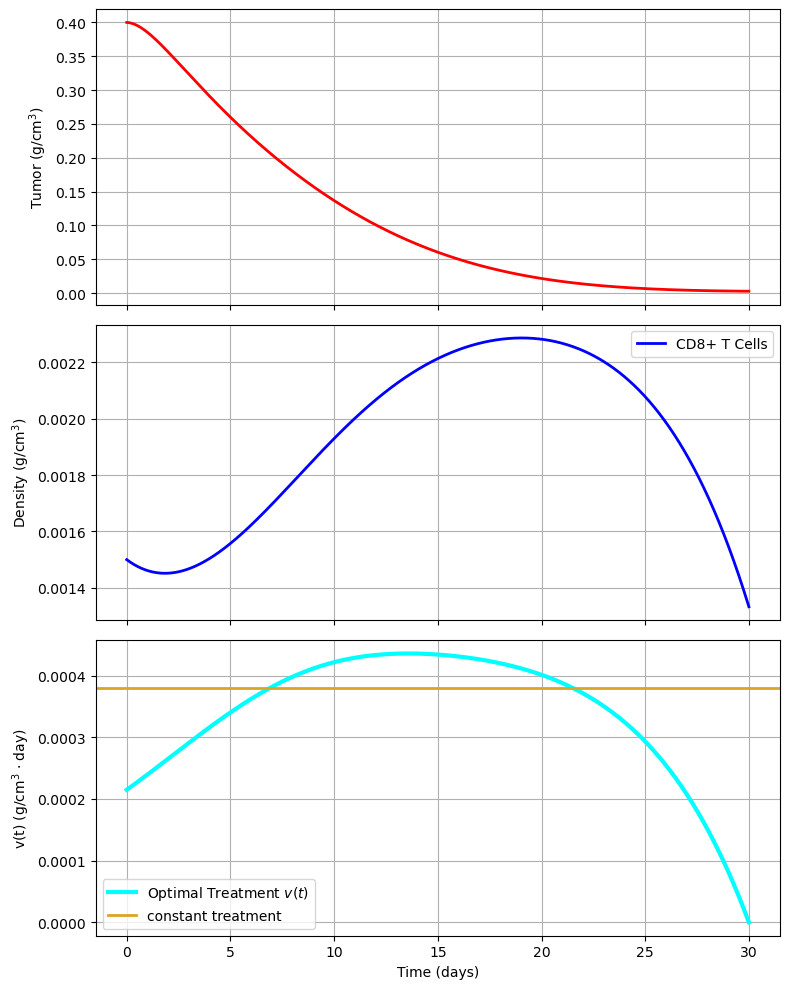

In [1]:
# Modified parameters to fit the T11 cell line
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (Strictly from Table 1)
# Stores the constant biologial rates that don't chnage between treatments. 
# ==========================================
p = {
    # Tumor
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    # DCs (L_DC = lambda_DC * D_0 = 4 * 2e-5)
    "L_DC": 0.0025, "K_C": 0.4, "d_D": 0.1,
    # NK cells
    "sigma_N": 0.0004, "d_N": 0.1, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    # Tregs (L_Tr = lambda_Tr * T_10 = 0.5 * 4e-4)
    "d_Treg": 0.2, "L_Tr": 0.0003, 
    # CD8 T cells (L_T8 = lambda_T8 * T_80 = 5.4 * 2e-4)
    "d_T8": 0.18, "L_T8": 1e-8, "K_Treg": 2.5e-4, "K_D": 4e-4
}

# Optimization Weights (From Paper)
a = 5000.0     # Penalty for drug injection
b = 0.0001     # Continuous penalty for tumor burden

# Time Grid (30 Days)
T_final = 30.0       
N_steps = 1000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)

# ==========================================
# 2. Derivative Functions for RK4
# ==========================================
def state_derivatives(x, v_val):
    C, D, N, Tr, T8 = x
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["L_DC"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["L_Tr"] * C / (p["K_C"] + C)
    
    # Notice v_val is now an additive infusion term here
    dT8 = -p["d_T8"]*T8 + p["L_T8"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, v_val):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    # Notice the 'b' term added to the dl1 equation
    dl1 = -( b + l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["L_DC"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["L_Tr"] * p["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*p["d_D"] + l5*(p["L_T8"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*p["d_Treg"] + l5*(p["L_T8"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] ) 
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Initialization & FBSM Loop
# ==========================================
x = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))

# Initial Conditions (From Table 2)
x[:, 0] = [0.4, 0.0004, 0.0003, 0.0005, 0.0015] 
v = np.zeros(N_steps)

tolerance = 1e-4
max_iter = 500
test = tolerance + 1
iteration = 0

print("Starting Forward-Backward Sweep Method...")

while test > tolerance and iteration < max_iter:
    old_v, old_x, old_lam = v.copy(), x.copy(), lam.copy()
    
    # --- STEP A: FORWARD SWEEP ---
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v[i] + v[i+1])
        current_x = np.maximum(x[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1])
        
        x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
        
    # --- STEP B: BACKWARD SWEEP ---
    # Transversality: Penalizing terminal tumor burden
    lam[:, -1] = 0.0
    lam[0, -1] = 1.0 
    
    for i in range(N_steps - 1, 0, -1):
        v_mid = 0.5 * (v[i] + v[i-1])
        x_mid = 0.5 * (x[:, i] + x[:, i-1])
        
        k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], v[i])
        k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, v_mid)
        k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, v_mid)
        k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, v[i-1])
        
        lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
    # --- STEP C: CONTROL UPDATE ---
    v_new = np.zeros(N_steps)
    for i in range(N_steps):
        # Optimal Control Law from paper: unconstrained to allow the bell curve
        v_calc = -lam[4, i] / (2 * a)
        v_new[i] = max(0.0, v_calc) 
        
    # --- STEP D: CONVEX COMBINATION & CHECK ---
    v = 0.05 * v_new + 0.95 * old_v # Slower learning rate for stability
    
    diff_v = np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10)
    diff_x = np.sum(np.abs(x - old_x)) / (np.sum(np.abs(x)) + 1e-10)
    diff_lam = np.sum(np.abs(lam - old_lam)) / (np.sum(np.abs(lam)) + 1e-10)
    
    test = diff_v + diff_x + diff_lam
    iteration += 1
    
    if iteration % 25 == 0:
        print(f"Iteration {iteration}, Error: {test:.5f}")

print(f"Converged in {iteration} iterations.")

# ==========================================
# 4. Plotting (Matched to Paper Style)
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Tumor Plot
axs[0].plot(t, x[0, :], 'r-', linewidth=2)
axs[0].set_ylabel('Tumor (g/cm$^3$)')
axs[0].grid(True)

# Immune Plot (Just T8 as shown in paper sometimes, or add NK if needed)
axs[1].plot(t, x[4, :], 'b-', linewidth=2, label='CD8+ T Cells')
axs[1].set_ylabel('Density (g/cm$^3$)')
axs[1].legend()
axs[1].grid(True)

# Optimal Control Plot (The Bell Curve)
axs[2].plot(t, v, 'cyan', linewidth=3, label='Optimal Treatment $v(t)$')
# Constant treatment (The Yellow Line)
axs[2].axhline(
    y=0.00038,
    color="goldenrod",
    linestyle='-',
    linewidth=2,
    label='constant treatment'
)
axs[2].set_xlabel('Time (days)')
axs[2].set_ylabel('v(t) (g/cm$^3$ $\cdot$ day)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

The  simualted graph for untreated, constant ICB treatment and optimized treatment schemes

Running Optimization for Best Treatment Strategy...
Optimization converged in 223 iterations.
Running simulations for baseline scenarios...


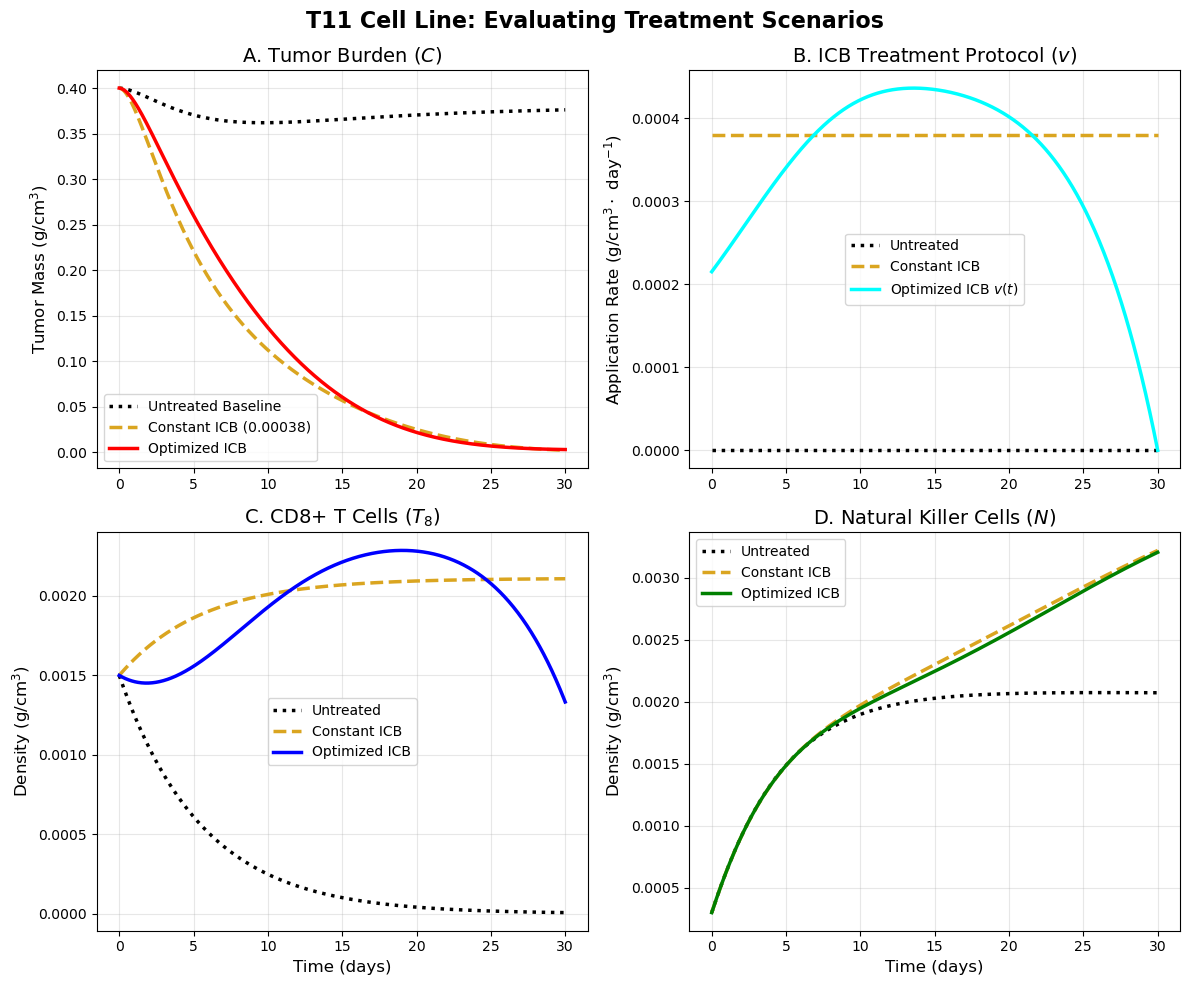

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (T11 Cell Line)
# ==========================================
p = {
    # Tumor
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    # DCs 
    "L_DC": 0.0025, "K_C": 0.4, "d_D": 0.1,
    # NK cells
    "sigma_N": 0.0004, "d_N": 0.1, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    # Tregs 
    "d_Treg": 0.2, "L_Tr": 0.0003, 
    # CD8 T cells 
    "d_T8": 0.18, "L_T8": 1e-8, "K_Treg": 2.5e-4, "K_D": 4e-4
}

# Optimization Weights
a = 5000.0     # Penalty for drug injection
b = 0.0001     # Continuous penalty for tumor burden

# Time Grid (30 Days)
T_final = 30.0       
N_steps = 1000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)

# Initial Conditions [C, D, N, Tr, T8]
x0 = [0.4, 0.0004, 0.0003, 0.0005, 0.0015] 

# ==========================================
# 2. ODE Derivative Functions 
# ==========================================
def state_derivatives(x, v_val):
    C, D, N, Tr, T8 = x
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["L_DC"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["L_Tr"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["L_T8"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, v_val):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    dl1 = -( b + l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["L_DC"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["L_Tr"] * p["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*p["d_D"] + l5*(p["L_T8"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*p["d_Treg"] + l5*(p["L_T8"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] ) 
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Optimization (Forward-Backward Sweep)
# ==========================================
x_opt = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))
x_opt[:, 0] = x0
v_opt = np.zeros(N_steps)

tolerance = 1e-4
max_iter = 500
test = tolerance + 1
iteration = 0

print("Running Optimization for Best Treatment Strategy...")

while test > tolerance and iteration < max_iter:
    old_v, old_x, old_lam = v_opt.copy(), x_opt.copy(), lam.copy()
    
    # FORWARD SWEEP
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v_opt[i] + v_opt[i+1])
        current_x = np.maximum(x_opt[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v_opt[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v_opt[i+1])
        
        x_opt[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
        
    # BACKWARD SWEEP
    lam[:, -1] = 0.0
    lam[0, -1] = 1.0 
    
    for i in range(N_steps - 1, 0, -1):
        v_mid = 0.5 * (v_opt[i] + v_opt[i-1])
        x_mid = 0.5 * (x_opt[:, i] + x_opt[:, i-1])
        
        k1 = dt * adjoint_derivatives(x_opt[:, i], lam[:, i], v_opt[i])
        k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, v_mid)
        k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, v_mid)
        k4 = dt * adjoint_derivatives(x_opt[:, i-1], lam[:, i] - k3, v_opt[i-1])
        
        lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
    # CONTROL UPDATE
    v_new = np.zeros(N_steps)
    for i in range(N_steps):
        v_new[i] = max(0.0, -lam[4, i] / (2 * a))
        
    # CONVEX COMBINATION
    v_opt = 0.05 * v_new + 0.95 * old_v 
    
    test = (np.sum(np.abs(v_opt - old_v)) / (np.sum(np.abs(v_opt)) + 1e-10) +
            np.sum(np.abs(x_opt - old_x)) / (np.sum(np.abs(x_opt)) + 1e-10) +
            np.sum(np.abs(lam - old_lam)) / (np.sum(np.abs(lam)) + 1e-10))
    iteration += 1

print(f"Optimization converged in {iteration} iterations.")

# ==========================================
# 4. Forward Simulation Helper
# ==========================================
def simulate_forward(v_array):
    """Simulates the tumor environment for a given, fixed treatment array."""
    x_sim = np.zeros((5, N_steps))
    x_sim[:, 0] = x0
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v_array[i] + v_array[i+1])
        current_x = np.maximum(x_sim[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v_array[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v_array[i+1])
        
        x_sim[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
    return x_sim

# Generate the Baseline Data
print("Running simulations for baseline scenarios...")
# 1. Untreated Scenario (v = 0)
v_untreated = np.zeros(N_steps)
x_untreated = simulate_forward(v_untreated)

# 2. Constant Treatment Scenario (v = 0.00038)
v_constant = np.full(N_steps, 0.00038)
x_constant = simulate_forward(v_constant)

# ==========================================
# 5. Plotting the 3 Scenarios
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("T11 Cell Line: Evaluating Treatment Scenarios", fontsize=16, fontweight='bold')

# --- Plot A: Tumor Burden ---
axs[0, 0].plot(t, x_untreated[0, :], color='black', linestyle=':', linewidth=2.5, label='Untreated Baseline')
axs[0, 0].plot(t, x_constant[0, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB (0.00038)')
axs[0, 0].plot(t, x_opt[0, :], color='red', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[0, 0].set_ylabel('Tumor Mass (g/cm$^3$)', fontsize=12)
axs[0, 0].set_title('A. Tumor Burden ($C$)', fontsize=14)
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# --- Plot B: Treatment Application ---
axs[0, 1].plot(t, v_untreated, color='black', linestyle=':', linewidth=2.5, label='Untreated')
axs[0, 1].plot(t, v_constant, color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[0, 1].plot(t, v_opt, color='cyan', linestyle='-', linewidth=2.5, label='Optimized ICB $v(t)$')
axs[0, 1].set_ylabel('Application Rate (g/cm$^3 \cdot$ day$^{-1}$)', fontsize=12)
axs[0, 1].set_title('B. ICB Treatment Protocol ($v$)', fontsize=14)
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# --- Plot C: CD8+ T Cells ---
axs[1, 0].plot(t, x_untreated[4, :], color='black', linestyle=':', linewidth=2.5, label='Untreated')
axs[1, 0].plot(t, x_constant[4, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[1, 0].plot(t, x_opt[4, :], color='blue', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[1, 0].set_xlabel('Time (days)', fontsize=12)
axs[1, 0].set_ylabel('Density (g/cm$^3$)', fontsize=12)
axs[1, 0].set_title('C. CD8+ T Cells ($T_8$)', fontsize=14)
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# --- Plot D: NK Cells ---
axs[1, 1].plot(t, x_untreated[2, :], color='black', linestyle=':', linewidth=2.5, label='Untreated')
axs[1, 1].plot(t, x_constant[2, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[1, 1].plot(t, x_opt[2, :], color='green', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[1, 1].set_xlabel('Time (days)', fontsize=12)
axs[1, 1].set_ylabel('Density (g/cm$^3$)', fontsize=12)
axs[1, 1].set_title('D. Natural Killer Cells ($N$)', fontsize=14)
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Leave space for the main title
plt.show()

Changed initial values for cancer

Running Optimization for Best Treatment Strategy...
Optimization converged in 224 iterations.
Running simulations for baseline scenarios...


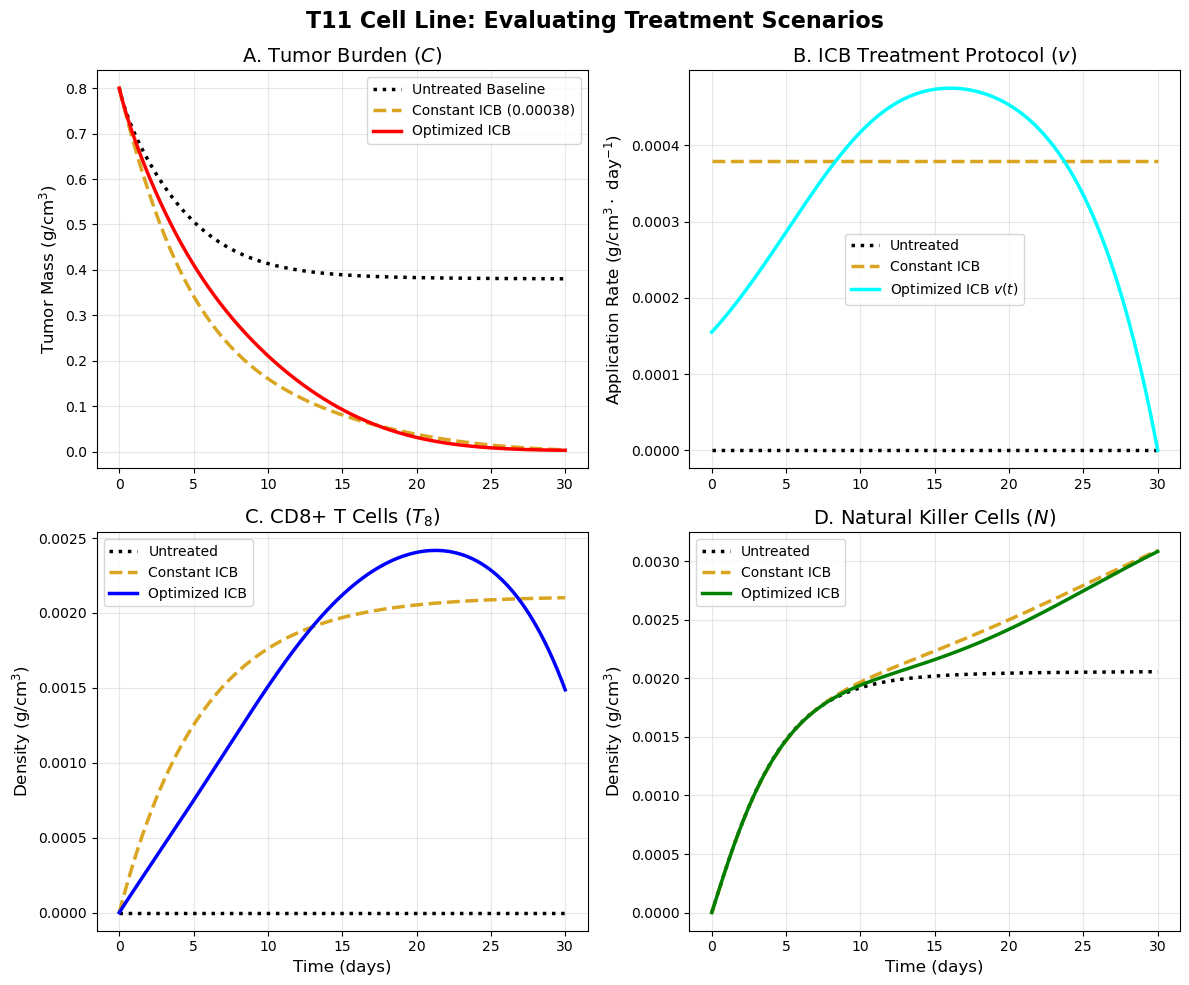

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (T11 Cell Line)
# ==========================================
p = {
    # Tumor
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    # DCs 
    "L_DC": 0.0025, "K_C": 0.4, "d_D": 0.1,
    # NK cells
    "sigma_N": 0.0004, "d_N": 0.1, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    # Tregs 
    "d_Treg": 0.2, "L_Tr": 0.0003, 
    # CD8 T cells 
    "d_T8": 0.18, "L_T8": 1e-8, "K_Treg": 2.5e-4, "K_D": 4e-4
}

# Optimization Weights
a = 5000.0     # Penalty for drug injection
b = 0.0001     # Continuous penalty for tumor burden

# Time Grid (30 Days)
T_final = 30.0       
N_steps = 1000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)

# Initial Conditions [C, D, N, Tr, T8]
x0 = [0.8, 0.0, 0.0, 0.0, 0.0] 

# ==========================================
# 2. ODE Derivative Functions 
# ==========================================
def state_derivatives(x, v_val):
    C, D, N, Tr, T8 = x
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["L_DC"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["L_Tr"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["L_T8"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, v_val):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    dl1 = -( b + l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["L_DC"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["L_Tr"] * p["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*p["d_D"] + l5*(p["L_T8"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*p["d_Treg"] + l5*(p["L_T8"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] ) 
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Optimization (Forward-Backward Sweep)
# ==========================================
x_opt = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))
x_opt[:, 0] = x0
v_opt = np.zeros(N_steps)

tolerance = 1e-4
max_iter = 500
test = tolerance + 1
iteration = 0

print("Running Optimization for Best Treatment Strategy...")

while test > tolerance and iteration < max_iter:
    old_v, old_x, old_lam = v_opt.copy(), x_opt.copy(), lam.copy()
    
    # FORWARD SWEEP
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v_opt[i] + v_opt[i+1])
        current_x = np.maximum(x_opt[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v_opt[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v_opt[i+1])
        
        x_opt[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
        
    # BACKWARD SWEEP
    lam[:, -1] = 0.0
    lam[0, -1] = 1.0 
    
    for i in range(N_steps - 1, 0, -1):
        v_mid = 0.5 * (v_opt[i] + v_opt[i-1])
        x_mid = 0.5 * (x_opt[:, i] + x_opt[:, i-1])
        
        k1 = dt * adjoint_derivatives(x_opt[:, i], lam[:, i], v_opt[i])
        k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, v_mid)
        k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, v_mid)
        k4 = dt * adjoint_derivatives(x_opt[:, i-1], lam[:, i] - k3, v_opt[i-1])
        
        lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
    # CONTROL UPDATE
    v_new = np.zeros(N_steps)
    for i in range(N_steps):
        v_new[i] = max(0.0, -lam[4, i] / (2 * a))
        
    # CONVEX COMBINATION
    v_opt = 0.05 * v_new + 0.95 * old_v 
    
    test = (np.sum(np.abs(v_opt - old_v)) / (np.sum(np.abs(v_opt)) + 1e-10) +
            np.sum(np.abs(x_opt - old_x)) / (np.sum(np.abs(x_opt)) + 1e-10) +
            np.sum(np.abs(lam - old_lam)) / (np.sum(np.abs(lam)) + 1e-10))
    iteration += 1

print(f"Optimization converged in {iteration} iterations.")

# ==========================================
# 4. Forward Simulation Helper
# ==========================================
def simulate_forward(v_array):
    """Simulates the tumor environment for a given, fixed treatment array."""
    x_sim = np.zeros((5, N_steps))
    x_sim[:, 0] = x0
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v_array[i] + v_array[i+1])
        current_x = np.maximum(x_sim[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v_array[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v_array[i+1])
        
        x_sim[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
    return x_sim

# Generate the Baseline Data
print("Running simulations for baseline scenarios...")
# 1. Untreated Scenario (v = 0)
v_untreated = np.zeros(N_steps)
x_untreated = simulate_forward(v_untreated)

# 2. Constant Treatment Scenario (v = 0.00038)
v_constant = np.full(N_steps, 0.00038)
x_constant = simulate_forward(v_constant)

# ==========================================
# 5. Plotting the 3 Scenarios
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("T11 Cell Line: Evaluating Treatment Scenarios", fontsize=16, fontweight='bold')

# --- Plot A: Tumor Burden ---
axs[0, 0].plot(t, x_untreated[0, :], color='black', linestyle=':', linewidth=2.5, label='Untreated Baseline')
axs[0, 0].plot(t, x_constant[0, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB (0.00038)')
axs[0, 0].plot(t, x_opt[0, :], color='red', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[0, 0].set_ylabel('Tumor Mass (g/cm$^3$)', fontsize=12)
axs[0, 0].set_title('A. Tumor Burden ($C$)', fontsize=14)
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# --- Plot B: Treatment Application ---
axs[0, 1].plot(t, v_untreated, color='black', linestyle=':', linewidth=2.5, label='Untreated')
axs[0, 1].plot(t, v_constant, color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[0, 1].plot(t, v_opt, color='cyan', linestyle='-', linewidth=2.5, label='Optimized ICB $v(t)$')
axs[0, 1].set_ylabel('Application Rate (g/cm$^3 \cdot$ day$^{-1}$)', fontsize=12)
axs[0, 1].set_title('B. ICB Treatment Protocol ($v$)', fontsize=14)
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# --- Plot C: CD8+ T Cells ---
axs[1, 0].plot(t, x_untreated[4, :], color='black', linestyle=':', linewidth=2.5, label='Untreated')
axs[1, 0].plot(t, x_constant[4, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[1, 0].plot(t, x_opt[4, :], color='blue', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[1, 0].set_xlabel('Time (days)', fontsize=12)
axs[1, 0].set_ylabel('Density (g/cm$^3$)', fontsize=12)
axs[1, 0].set_title('C. CD8+ T Cells ($T_8$)', fontsize=14)
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# --- Plot D: NK Cells ---
axs[1, 1].plot(t, x_untreated[2, :], color='black', linestyle=':', linewidth=2.5, label='Untreated')
axs[1, 1].plot(t, x_constant[2, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[1, 1].plot(t, x_opt[2, :], color='green', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[1, 1].set_xlabel('Time (days)', fontsize=12)
axs[1, 1].set_ylabel('Density (g/cm$^3$)', fontsize=12)
axs[1, 1].set_title('D. Natural Killer Cells ($N$)', fontsize=14)
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Leave space for the main title
plt.show()

Running Optimization for Best Treatment Strategy...
Optimization converged in 224 iterations.
Running simulations for baseline scenarios...


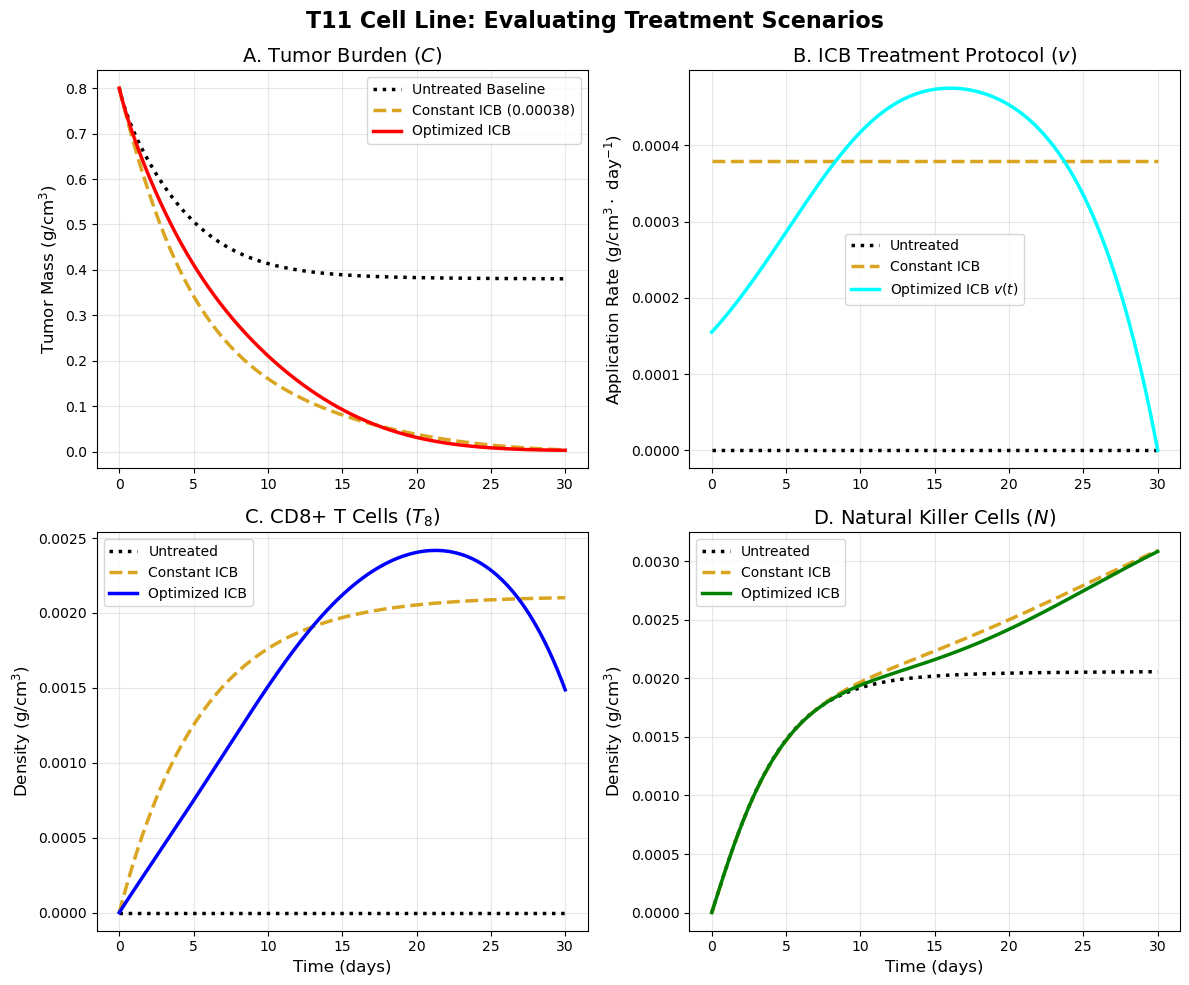

In [8]:
# Set the initial condition to have tumor at 0.8, and  immune cells at 0.0
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (T11 Cell Line)
# ==========================================
p = {
    # Tumor
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    # DCs 
    "L_DC": 0.0025, "K_C": 0.4, "d_D": 0.1,
    # NK cells
    "sigma_N": 0.0004, "d_N": 0.1, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    # Tregs 
    "d_Treg": 0.2, "L_Tr": 0.0003, 
    # CD8 T cells 
    "d_T8": 0.18, "L_T8": 1e-8, "K_Treg": 2.5e-4, "K_D": 4e-4
}

# Optimization Weights
a = 5000.0     # Penalty for drug injection
b = 0.0001     # Continuous penalty for tumor burden

# Time Grid (30 Days)
T_final = 30.0       
N_steps = 1000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)

# Initial Conditions [C, D, N, Tr, T8]
x0 = [0.8, 0.0, 0.0, 0.0, 0.0] 

# ==========================================
# 2. ODE Derivative Functions 
# ==========================================
def state_derivatives(x, v_val):
    C, D, N, Tr, T8 = x
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["L_DC"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["L_Tr"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["L_T8"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, v_val):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    dl1 = -( b + l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["L_DC"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["L_Tr"] * p["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*p["d_D"] + l5*(p["L_T8"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*p["d_Treg"] + l5*(p["L_T8"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] ) 
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Optimization (Forward-Backward Sweep)
# ==========================================
x_opt = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))
x_opt[:, 0] = x0
v_opt = np.zeros(N_steps)

tolerance = 1e-4
max_iter = 500
test = tolerance + 1
iteration = 0

print("Running Optimization for Best Treatment Strategy...")

while test > tolerance and iteration < max_iter:
    old_v, old_x, old_lam = v_opt.copy(), x_opt.copy(), lam.copy()
    
    # FORWARD SWEEP
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v_opt[i] + v_opt[i+1])
        current_x = np.maximum(x_opt[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v_opt[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v_opt[i+1])
        
        x_opt[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
        
    # BACKWARD SWEEP
    lam[:, -1] = 0.0
    lam[0, -1] = 1.0 
    
    for i in range(N_steps - 1, 0, -1):
        v_mid = 0.5 * (v_opt[i] + v_opt[i-1])
        x_mid = 0.5 * (x_opt[:, i] + x_opt[:, i-1])
        
        k1 = dt * adjoint_derivatives(x_opt[:, i], lam[:, i], v_opt[i])
        k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, v_mid)
        k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, v_mid)
        k4 = dt * adjoint_derivatives(x_opt[:, i-1], lam[:, i] - k3, v_opt[i-1])
        
        lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
    # CONTROL UPDATE
    v_new = np.zeros(N_steps)
    for i in range(N_steps):
        v_new[i] = max(0.0, -lam[4, i] / (2 * a))
        
    # CONVEX COMBINATION
    v_opt = 0.05 * v_new + 0.95 * old_v 
    
    test = (np.sum(np.abs(v_opt - old_v)) / (np.sum(np.abs(v_opt)) + 1e-10) +
            np.sum(np.abs(x_opt - old_x)) / (np.sum(np.abs(x_opt)) + 1e-10) +
            np.sum(np.abs(lam - old_lam)) / (np.sum(np.abs(lam)) + 1e-10))
    iteration += 1

print(f"Optimization converged in {iteration} iterations.")

# ==========================================
# 4. Forward Simulation Helper
# ==========================================
def simulate_forward(v_array):
    """Simulates the tumor environment for a given, fixed treatment array."""
    x_sim = np.zeros((5, N_steps))
    x_sim[:, 0] = x0
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v_array[i] + v_array[i+1])
        current_x = np.maximum(x_sim[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v_array[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v_array[i+1])
        
        x_sim[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
    return x_sim

# Generate the Baseline Data
print("Running simulations for baseline scenarios...")
# 1. Untreated Scenario (v = 0)
v_untreated = np.zeros(N_steps)
x_untreated = simulate_forward(v_untreated)

# 2. Constant Treatment Scenario (v = 0.00038)
v_constant = np.full(N_steps, 0.00038)
x_constant = simulate_forward(v_constant)

# ==========================================
# 5. Plotting the 3 Scenarios
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("T11 Cell Line: Evaluating Treatment Scenarios", fontsize=16, fontweight='bold')

# --- Plot A: Tumor Burden ---
axs[0, 0].plot(t, x_untreated[0, :], color='black', linestyle=':', linewidth=2.5, label='Untreated Baseline')
axs[0, 0].plot(t, x_constant[0, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB (0.00038)')
axs[0, 0].plot(t, x_opt[0, :], color='red', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[0, 0].set_ylabel('Tumor Mass (g/cm$^3$)', fontsize=12)
axs[0, 0].set_title('A. Tumor Burden ($C$)', fontsize=14)
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# --- Plot B: Treatment Application ---
axs[0, 1].plot(t, v_untreated, color='black', linestyle=':', linewidth=2.5, label='Untreated')
axs[0, 1].plot(t, v_constant, color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[0, 1].plot(t, v_opt, color='cyan', linestyle='-', linewidth=2.5, label='Optimized ICB $v(t)$')
axs[0, 1].set_ylabel('Application Rate (g/cm$^3 \cdot$ day$^{-1}$)', fontsize=12)
axs[0, 1].set_title('B. ICB Treatment Protocol ($v$)', fontsize=14)
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# --- Plot C: CD8+ T Cells ---
axs[1, 0].plot(t, x_untreated[4, :], color='black', linestyle=':', linewidth=2.5, label='Untreated')
axs[1, 0].plot(t, x_constant[4, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[1, 0].plot(t, x_opt[4, :], color='blue', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[1, 0].set_xlabel('Time (days)', fontsize=12)
axs[1, 0].set_ylabel('Density (g/cm$^3$)', fontsize=12)
axs[1, 0].set_title('C. CD8+ T Cells ($T_8$)', fontsize=14)
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# --- Plot D: NK Cells ---
axs[1, 1].plot(t, x_untreated[2, :], color='black', linestyle=':', linewidth=2.5, label='Untreated')
axs[1, 1].plot(t, x_constant[2, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[1, 1].plot(t, x_opt[2, :], color='green', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[1, 1].set_xlabel('Time (days)', fontsize=12)
axs[1, 1].set_ylabel('Density (g/cm$^3$)', fontsize=12)
axs[1, 1].set_title('D. Natural Killer Cells ($N$)', fontsize=14)
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Leave space for the main title
plt.show()

Optimize ICB treatment based on Mutagen application

Running Optimization for Best ICB Strategy (Under Mutagen Baseline)...
Optimization converged in 187 iterations.
Running simulations for baseline scenarios...


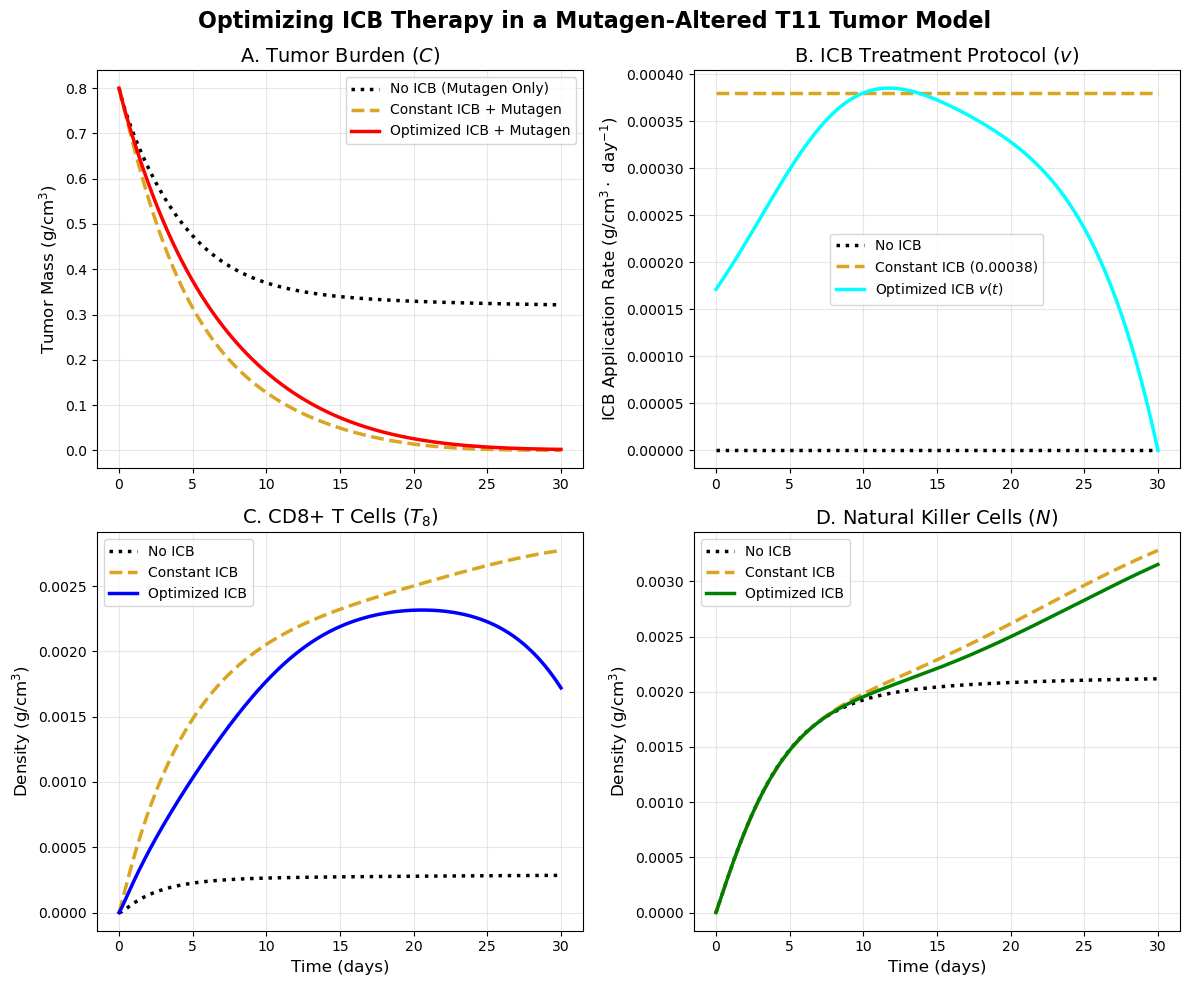

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (Mutagen Baseline)
# Locked to: With Mutagen, ICB Untreated [0.002, 0.0002, 0.0004]
# ==========================================
p = {
    # Tumor
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    # DCs 
    "L_DC": 0.002, "K_C": 0.4, "d_D": 0.1,         # Updated L_DC
    # NK cells
    "sigma_N": 0.0004, "d_N": 0.1, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4, # Updated sigma_N
    # Tregs 
    "d_Treg": 0.2, "L_Tr": 0.0003, 
    # CD8 T cells 
    "d_T8": 0.18, "L_T8": 0.0002, "K_Treg": 2.5e-4, "K_D": 4e-4   # Updated L_T8
}

# Optimization Weights
a = 5000.0     # Penalty for drug injection
b = 0.0001     # Continuous penalty for tumor burden

# Time Grid (30 Days)
T_final = 30.0       
N_steps = 1000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)

# Initial Conditions [C, D, N, Tr, T8]
x0 = [0.8, 0.0, 0.0, 0.0, 0.0] 

# ==========================================
# 2. ODE Derivative Functions 
# ==========================================
def state_derivatives(x, v_val):
    C, D, N, Tr, T8 = x
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["L_DC"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["L_Tr"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["L_T8"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, v_val):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    dl1 = -( b + l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["L_DC"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["L_Tr"] * p["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*p["d_D"] + l5*(p["L_T8"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*p["d_Treg"] + l5*(p["L_T8"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] ) 
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Optimization (Forward-Backward Sweep)
# ==========================================
x_opt = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))
x_opt[:, 0] = x0
v_opt = np.zeros(N_steps)

tolerance = 1e-4
max_iter = 500
test = tolerance + 1
iteration = 0

print("Running Optimization for Best ICB Strategy (Under Mutagen Baseline)...")

while test > tolerance and iteration < max_iter:
    old_v, old_x, old_lam = v_opt.copy(), x_opt.copy(), lam.copy()
    
    # FORWARD SWEEP
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v_opt[i] + v_opt[i+1])
        current_x = np.maximum(x_opt[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v_opt[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v_opt[i+1])
        
        x_opt[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
        
    # BACKWARD SWEEP
    lam[:, -1] = 0.0
    lam[0, -1] = 1.0 
    
    for i in range(N_steps - 1, 0, -1):
        v_mid = 0.5 * (v_opt[i] + v_opt[i-1])
        x_mid = 0.5 * (x_opt[:, i] + x_opt[:, i-1])
        
        k1 = dt * adjoint_derivatives(x_opt[:, i], lam[:, i], v_opt[i])
        k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, v_mid)
        k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, v_mid)
        k4 = dt * adjoint_derivatives(x_opt[:, i-1], lam[:, i] - k3, v_opt[i-1])
        
        lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
    # CONTROL UPDATE
    v_new = np.zeros(N_steps)
    for i in range(N_steps):
        v_new[i] = max(0.0, -lam[4, i] / (2 * a))
        
    # CONVEX COMBINATION
    v_opt = 0.05 * v_new + 0.95 * old_v 
    
    test = (np.sum(np.abs(v_opt - old_v)) / (np.sum(np.abs(v_opt)) + 1e-10) +
            np.sum(np.abs(x_opt - old_x)) / (np.sum(np.abs(x_opt)) + 1e-10) +
            np.sum(np.abs(lam - old_lam)) / (np.sum(np.abs(lam)) + 1e-10))
    iteration += 1

print(f"Optimization converged in {iteration} iterations.")

# ==========================================
# 4. Forward Simulation Helper
# ==========================================
def simulate_forward(v_array):
    """Simulates the tumor environment for a given, fixed treatment array."""
    x_sim = np.zeros((5, N_steps))
    x_sim[:, 0] = x0
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v_array[i] + v_array[i+1])
        current_x = np.maximum(x_sim[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v_array[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v_array[i+1])
        
        x_sim[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
    return x_sim

# Generate the Baseline Data
print("Running simulations for baseline scenarios...")
# 1. No ICB Scenario (v = 0)
v_no_icb = np.zeros(N_steps)
x_no_icb = simulate_forward(v_no_icb)

# 2. Constant ICB Scenario (v = 0.00038)
v_constant = np.full(N_steps, 0.00038)
x_constant = simulate_forward(v_constant)

# ==========================================
# 5. Plotting the 3 Scenarios
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Optimizing ICB Therapy in a Mutagen-Altered T11 Tumor Model", fontsize=16, fontweight='bold')

# --- Plot A: Tumor Burden ---
axs[0, 0].plot(t, x_no_icb[0, :], color='black', linestyle=':', linewidth=2.5, label='No ICB (Mutagen Only)')
axs[0, 0].plot(t, x_constant[0, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB + Mutagen')
axs[0, 0].plot(t, x_opt[0, :], color='red', linestyle='-', linewidth=2.5, label='Optimized ICB + Mutagen')
axs[0, 0].set_ylabel('Tumor Mass (g/cm$^3$)', fontsize=12)
axs[0, 0].set_title('A. Tumor Burden ($C$)', fontsize=14)
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# --- Plot B: Treatment Application ---
axs[0, 1].plot(t, v_no_icb, color='black', linestyle=':', linewidth=2.5, label='No ICB')
axs[0, 1].plot(t, v_constant, color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB (0.00038)')
axs[0, 1].plot(t, v_opt, color='cyan', linestyle='-', linewidth=2.5, label='Optimized ICB $v(t)$')
axs[0, 1].set_ylabel('ICB Application Rate (g/cm$^3 \cdot$ day$^{-1}$)', fontsize=12)
axs[0, 1].set_title('B. ICB Treatment Protocol ($v$)', fontsize=14)
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# --- Plot C: CD8+ T Cells ---
axs[1, 0].plot(t, x_no_icb[4, :], color='black', linestyle=':', linewidth=2.5, label='No ICB')
axs[1, 0].plot(t, x_constant[4, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[1, 0].plot(t, x_opt[4, :], color='blue', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[1, 0].set_xlabel('Time (days)', fontsize=12)
axs[1, 0].set_ylabel('Density (g/cm$^3$)', fontsize=12)
axs[1, 0].set_title('C. CD8+ T Cells ($T_8$)', fontsize=14)
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# --- Plot D: NK Cells ---
axs[1, 1].plot(t, x_no_icb[2, :], color='black', linestyle=':', linewidth=2.5, label='No ICB')
axs[1, 1].plot(t, x_constant[2, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[1, 1].plot(t, x_opt[2, :], color='green', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[1, 1].set_xlabel('Time (days)', fontsize=12)
axs[1, 1].set_ylabel('Density (g/cm$^3$)', fontsize=12)
axs[1, 1].set_title('D. Natural Killer Cells ($N$)', fontsize=14)
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

Running simulations... This will take a moment for the optimizations.
Optimizing Scenario 4...
Optimizing Scenario 5...


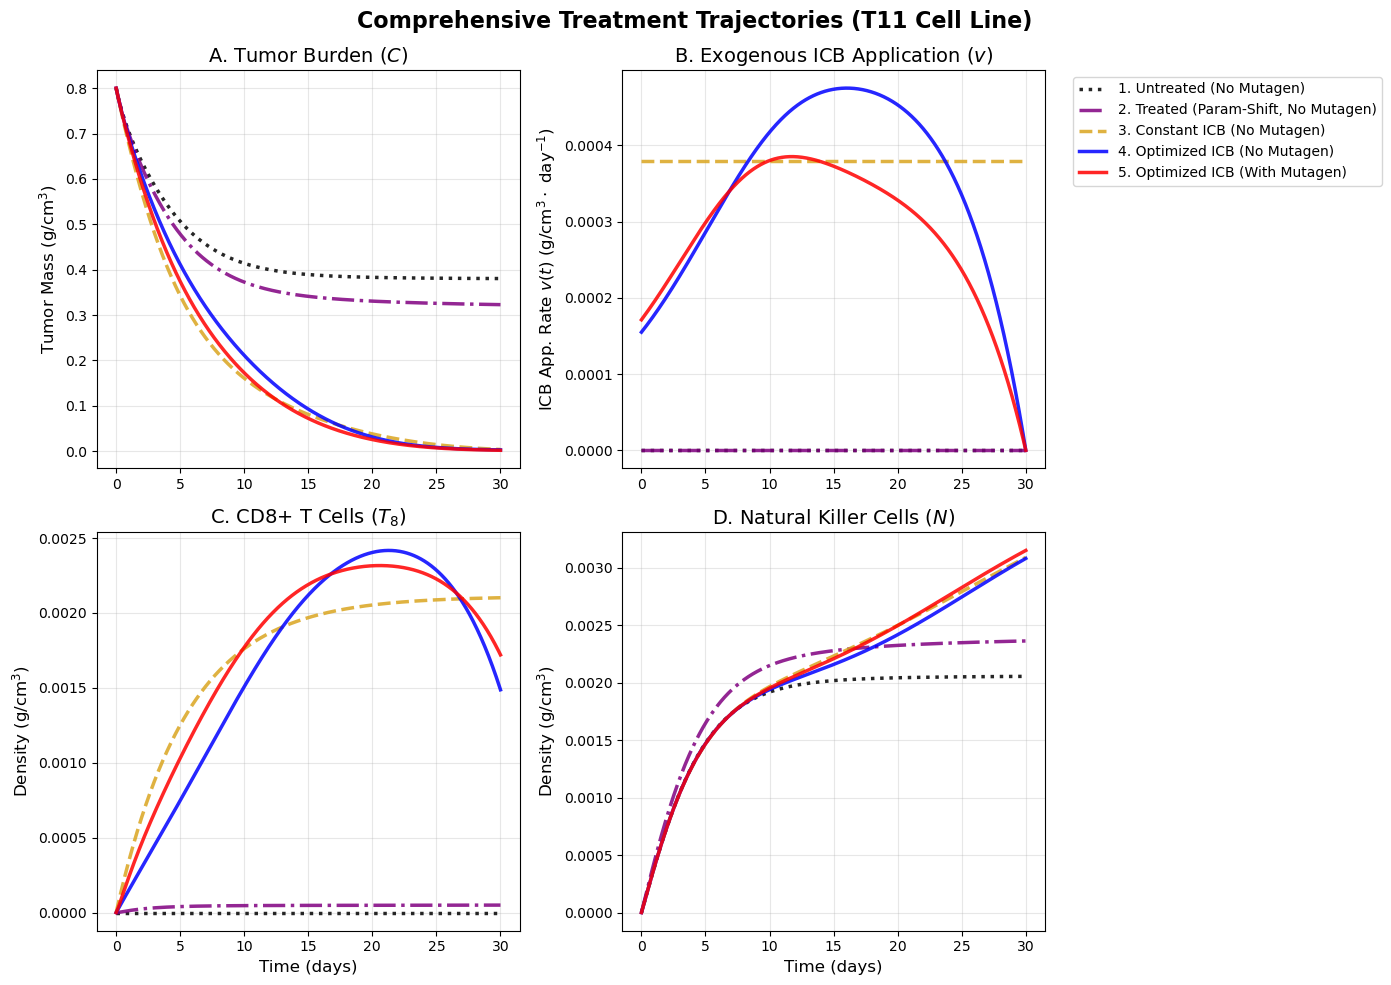

In [10]:
# Get all the plots into one
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Parameter Generator Function
# ==========================================
def get_params(L_DC, L_T8, sigma_N):
    """Generates the full parameter dictionary based on specific treatment shifts."""
    return {
        "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
        "K_C": 0.4, "d_D": 0.1, "d_N": 0.1, "gamma_N": 150.0, "a_C": 0.5, 
        "beta_1": 0.4, "beta_2": 2e-4, "d_Treg": 0.2, "L_Tr": 0.0003, 
        "d_T8": 0.18, "K_Treg": 2.5e-4, "K_D": 4e-4,
        "L_DC": L_DC, "L_T8": L_T8, "sigma_N": sigma_N
    }

# Define the biological baselines from your data
p_untreated_nomut = get_params(0.0025,  1e-8,    0.0004)   # Base: No Mutagen
p_treated_nomut   = get_params(0.00225, 3.5e-5,  0.00045)  # Param-Shift ICB Representation
p_untreated_mut   = get_params(0.002,   0.0002,  0.0004)   # Base: With Mutagen

# Global Optimization & Time Settings
a = 5000.0
b = 0.0001
T_final = 30.0       
N_steps = 1000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)
x0 = [0.8, 0.0, 0.0, 0.0, 0.0] 

# ==========================================
# 2. ODE Derivative Functions 
# ==========================================
def state_derivatives(x, v_val, p):
    C, D, N, Tr, T8 = x
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["L_DC"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["L_Tr"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["L_T8"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"])) + v_val
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, v_val, p):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    dl1 = -( b + l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["L_DC"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["L_Tr"] * p["K_C"] / den_KC**2) )
    dl2 = -( -l2*p["d_D"] + l5*(p["L_T8"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*p["d_Treg"] + l5*(p["L_T8"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] ) 
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Engines: FBSM Optimizer & Forward Simulator
# ==========================================
def run_fbsm(p_dict):
    """Runs the optimization loop for a given parameter set."""
    x_opt = np.zeros((5, N_steps))
    lam = np.zeros((5, N_steps))
    x_opt[:, 0] = x0
    v_opt = np.zeros(N_steps)

    tolerance = 1e-4
    max_iter = 500
    test = tolerance + 1
    iteration = 0

    while test > tolerance and iteration < max_iter:
        old_v, old_x, old_lam = v_opt.copy(), x_opt.copy(), lam.copy()
        
        # FORWARD SWEEP
        for i in range(N_steps - 1):
            v_mid = 0.5 * (v_opt[i] + v_opt[i+1])
            current_x = np.maximum(x_opt[:, i], 0.0)
            k1 = dt * state_derivatives(current_x, v_opt[i], p_dict)
            k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid, p_dict)
            k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid, p_dict)
            k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v_opt[i+1], p_dict)
            x_opt[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
            
        # BACKWARD SWEEP
        lam[:, -1] = 0.0
        lam[0, -1] = 1.0 
        for i in range(N_steps - 1, 0, -1):
            v_mid = 0.5 * (v_opt[i] + v_opt[i-1])
            x_mid = 0.5 * (x_opt[:, i] + x_opt[:, i-1])
            k1 = dt * adjoint_derivatives(x_opt[:, i], lam[:, i], v_opt[i], p_dict)
            k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, v_mid, p_dict)
            k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, v_mid, p_dict)
            k4 = dt * adjoint_derivatives(x_opt[:, i-1], lam[:, i] - k3, v_opt[i-1], p_dict)
            lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
            
        # CONTROL UPDATE & CONVEX COMBINATION
        v_new = np.zeros(N_steps)
        for i in range(N_steps):
            v_new[i] = max(0.0, -lam[4, i] / (2 * a))
        v_opt = 0.05 * v_new + 0.95 * old_v 
        
        test = (np.sum(np.abs(v_opt - old_v)) / (np.sum(np.abs(v_opt)) + 1e-10) +
                np.sum(np.abs(x_opt - old_x)) / (np.sum(np.abs(x_opt)) + 1e-10) +
                np.sum(np.abs(lam - old_lam)) / (np.sum(np.abs(lam)) + 1e-10))
        iteration += 1
    return x_opt, v_opt

def simulate_forward(v_array, p_dict):
    """Runs a standard forward simulation given fixed parameters and treatment."""
    x_sim = np.zeros((5, N_steps))
    x_sim[:, 0] = x0
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v_array[i] + v_array[i+1])
        current_x = np.maximum(x_sim[:, i], 0.0)
        k1 = dt * state_derivatives(current_x, v_array[i], p_dict)
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid, p_dict)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid, p_dict)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v_array[i+1], p_dict)
        x_sim[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
    return x_sim

# ==========================================
# 4. Generate All 5 Scenarios
# ==========================================
print("Running simulations... This will take a moment for the optimizations.")

# 1. Untreated, No Mutagen (Baseline)
x1 = simulate_forward(np.zeros(N_steps), p_untreated_nomut)
v1 = np.zeros(N_steps)

# 2. Treated, No Mutagen (Modeled via Biological Parameter Shift)
x2 = simulate_forward(np.zeros(N_steps), p_treated_nomut)
v2 = np.zeros(N_steps)

# 3. Constant Treatment (No Mutagen Base, standard v dosage)
v3 = np.full(N_steps, 0.00038)
x3 = simulate_forward(v3, p_untreated_nomut)

# 4. Optimized Treatment (No Mutagen Base)
print("Optimizing Scenario 4...")
x4, v4 = run_fbsm(p_untreated_nomut)

# 5. Optimized Treatment (With Mutagen Base)
print("Optimizing Scenario 5...")
x5, v5 = run_fbsm(p_untreated_mut)

# ==========================================
# 5. Plotting the Comparison Grid
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Comprehensive Treatment Trajectories (T11 Cell Line)", fontsize=16, fontweight='bold')

# Helper list to manage loops for plotting [x_data, v_data, color, linestyle, label]
scenarios = [
    (x1, v1, 'black',      ':',  '1. Untreated (No Mutagen)'),
    (x2, v2, 'purple',     '-.', '2. Treated (Param-Shift, No Mutagen)'),
    (x3, v3, 'goldenrod',  '--', '3. Constant ICB (No Mutagen)'),
    (x4, v4, 'blue',       '-',  '4. Optimized ICB (No Mutagen)'),
    (x5, v5, 'red',        '-',  '5. Optimized ICB (With Mutagen)')
]

for x_data, v_data, col, ls, lab in scenarios:
    # A. Tumor Burden
    axs[0, 0].plot(t, x_data[0, :], color=col, linestyle=ls, linewidth=2.5, alpha=0.85, label=lab)
    # B. Treatment Dosage
    axs[0, 1].plot(t, v_data, color=col, linestyle=ls, linewidth=2.5, alpha=0.85, label=lab)
    # C. CD8+ T Cells
    axs[1, 0].plot(t, x_data[4, :], color=col, linestyle=ls, linewidth=2.5, alpha=0.85, label=lab)
    # D. NK Cells
    axs[1, 1].plot(t, x_data[2, :], color=col, linestyle=ls, linewidth=2.5, alpha=0.85, label=lab)

# Formatting A
axs[0, 0].set_ylabel('Tumor Mass (g/cm$^3$)', fontsize=12)
axs[0, 0].set_title('A. Tumor Burden ($C$)', fontsize=14)
axs[0, 0].grid(True, alpha=0.3)

# Formatting B
axs[0, 1].set_ylabel('ICB App. Rate $v(t)$ (g/cm$^3 \cdot$ day$^{-1}$)', fontsize=12)
axs[0, 1].set_title('B. Exogenous ICB Application ($v$)', fontsize=14)
axs[0, 1].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10) # Place legend outside
axs[0, 1].grid(True, alpha=0.3)

# Formatting C
axs[1, 0].set_xlabel('Time (days)', fontsize=12)
axs[1, 0].set_ylabel('Density (g/cm$^3$)', fontsize=12)
axs[1, 0].set_title('C. CD8+ T Cells ($T_8$)', fontsize=14)
axs[1, 0].grid(True, alpha=0.3)

# Formatting D
axs[1, 1].set_xlabel('Time (days)', fontsize=12)
axs[1, 1].set_ylabel('Density (g/cm$^3$)', fontsize=12)
axs[1, 1].set_title('D. Natural Killer Cells ($N$)', fontsize=14)
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.92, right=0.75) # Adjust right margin to fit the global legend
plt.show()

In [ ]:
# multi-phase Optimization 


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (T11 Cell Line)
# ==========================================
p = {
    # Tumor
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    # DCs 
    "L_DC": 0.0025, "K_C": 0.4, "d_D": 0.1,
    # NK cells
    "sigma_N": 0.0004, "d_N": 0.1, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    # Tregs 
    "d_Treg": 0.2, "L_Tr": 0.0003, 
    # CD8 T cells 
    "d_T8": 0.18, "L_T8": 1e-8, "K_Treg": 2.5e-4, "K_D": 4e-4
}

# Optimization Weights
a = 5000.0     # Penalty for drug injection
b = 0.0001     # Continuous penalty for tumor burden

# Time Grid (30 Days)
T_final = 30.0       
N_steps = 1000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)

# Initial Conditions [C, D, N, Tr, T8]
x0 = [0.4, 0.0004, 0.0003, 0.0005, 0.0015] 

# ==========================================
# 2. ODE Derivative Functions 
# ==========================================
def state_derivatives(x, v_val):
    C, D, N, Tr, T8 = x
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["L_DC"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["L_Tr"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["L_T8"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, v_val):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    dl1 = -( b + l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["L_DC"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["L_Tr"] * p["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*p["d_D"] + l5*(p["L_T8"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*p["d_Treg"] + l5*(p["L_T8"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] ) 
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Optimization (Forward-Backward Sweep)
# ==========================================
x_opt = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))
x_opt[:, 0] = x0
v_opt = np.zeros(N_steps)

tolerance = 1e-4
max_iter = 500
test = tolerance + 1
iteration = 0

print("Running Optimization for Best Treatment Strategy...")

while test > tolerance and iteration < max_iter:
    old_v, old_x, old_lam = v_opt.copy(), x_opt.copy(), lam.copy()
    
    # FORWARD SWEEP
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v_opt[i] + v_opt[i+1])
        current_x = np.maximum(x_opt[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v_opt[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v_opt[i+1])
        
        x_opt[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
        
    # BACKWARD SWEEP
    lam[:, -1] = 0.0
    lam[0, -1] = 1.0 
    
    for i in range(N_steps - 1, 0, -1):
        v_mid = 0.5 * (v_opt[i] + v_opt[i-1])
        x_mid = 0.5 * (x_opt[:, i] + x_opt[:, i-1])
        
        k1 = dt * adjoint_derivatives(x_opt[:, i], lam[:, i], v_opt[i])
        k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, v_mid)
        k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, v_mid)
        k4 = dt * adjoint_derivatives(x_opt[:, i-1], lam[:, i] - k3, v_opt[i-1])
        
        lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
    # CONTROL UPDATE
    v_new = np.zeros(N_steps)
    for i in range(N_steps):
        v_new[i] = max(0.0, -lam[4, i] / (2 * a))
        
    # CONVEX COMBINATION
    v_opt = 0.05 * v_new + 0.95 * old_v 
    
    test = (np.sum(np.abs(v_opt - old_v)) / (np.sum(np.abs(v_opt)) + 1e-10) +
            np.sum(np.abs(x_opt - old_x)) / (np.sum(np.abs(x_opt)) + 1e-10) +
            np.sum(np.abs(lam - old_lam)) / (np.sum(np.abs(lam)) + 1e-10))
    iteration += 1

print(f"Optimization converged in {iteration} iterations.")

# ==========================================
# 4. Forward Simulation Helper
# ==========================================
def simulate_forward(v_array):
    """Simulates the tumor environment for a given, fixed treatment array."""
    x_sim = np.zeros((5, N_steps))
    x_sim[:, 0] = x0
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v_array[i] + v_array[i+1])
        current_x = np.maximum(x_sim[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v_array[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v_array[i+1])
        
        x_sim[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
    return x_sim

# Generate the Baseline Data
print("Running simulations for baseline scenarios...")
# 1. Untreated Scenario (v = 0)
v_untreated = np.zeros(N_steps)
x_untreated = simulate_forward(v_untreated)

# 2. Constant Treatment Scenario (v = 0.00038)
v_constant = np.full(N_steps, 0.00038)
x_constant = simulate_forward(v_constant)

# ==========================================
# 5. Plotting the 3 Scenarios
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("T11 Cell Line: Evaluating Treatment Scenarios", fontsize=16, fontweight='bold')

# --- Plot A: Tumor Burden ---
axs[0, 0].plot(t, x_untreated[0, :], color='black', linestyle=':', linewidth=2.5, label='Untreated Baseline')
axs[0, 0].plot(t, x_constant[0, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB (0.00038)')
axs[0, 0].plot(t, x_opt[0, :], color='red', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[0, 0].set_ylabel('Tumor Mass (g/cm$^3$)', fontsize=12)
axs[0, 0].set_title('A. Tumor Burden ($C$)', fontsize=14)
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# --- Plot B: Treatment Application ---
axs[0, 1].plot(t, v_untreated, color='black', linestyle=':', linewidth=2.5, label='Untreated')
axs[0, 1].plot(t, v_constant, color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[0, 1].plot(t, v_opt, color='cyan', linestyle='-', linewidth=2.5, label='Optimized ICB $v(t)$')
axs[0, 1].set_ylabel('Application Rate (g/cm$^3 \cdot$ day$^{-1}$)', fontsize=12)
axs[0, 1].set_title('B. ICB Treatment Protocol ($v$)', fontsize=14)
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# --- Plot C: CD8+ T Cells ---
axs[1, 0].plot(t, x_untreated[4, :], color='black', linestyle=':', linewidth=2.5, label='Untreated')
axs[1, 0].plot(t, x_constant[4, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[1, 0].plot(t, x_opt[4, :], color='blue', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[1, 0].set_xlabel('Time (days)', fontsize=12)
axs[1, 0].set_ylabel('Density (g/cm$^3$)', fontsize=12)
axs[1, 0].set_title('C. CD8+ T Cells ($T_8$)', fontsize=14)
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# --- Plot D: NK Cells ---
axs[1, 1].plot(t, x_untreated[2, :], color='black', linestyle=':', linewidth=2.5, label='Untreated')
axs[1, 1].plot(t, x_constant[2, :], color='goldenrod', linestyle='--', linewidth=2.5, label='Constant ICB')
axs[1, 1].plot(t, x_opt[2, :], color='green', linestyle='-', linewidth=2.5, label='Optimized ICB')
axs[1, 1].set_xlabel('Time (days)', fontsize=12)
axs[1, 1].set_ylabel('Density (g/cm$^3$)', fontsize=12)
axs[1, 1].set_title('D. Natural Killer Cells ($N$)', fontsize=14)
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Leave space for the main title
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (Strictly from Table 1)
# ==========================================
p = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    "L_DC": 8e-5, "K_C": 0.4, "d_D": 0.1,
    "sigma_N": 5e-5, "d_N": 0.1, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    "d_Treg": 0.2, "L_Tr": 2e-4, 
    "d_T8": 0.18, "L_T8": 1.08e-3, "K_Treg": 2.5e-4, "K_D": 4e-4
}

# Time Grid (30 Days)
T_final = 30.0       
N_steps = 1000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)
x0 = [0.4, 0.0004, 0.0003, 0.0005, 0.0015]

# ==========================================
# 2. Derivative Functions
# ==========================================
def state_derivatives(x, v_val):
    C, D, N, Tr, T8 = x
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["L_DC"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["L_Tr"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["L_T8"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"])) + v_val
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, v_val, b_weight):
    # Notice: b_weight is now an explicitly passed argument!
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    dl1 = -( b_weight + l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["L_DC"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["L_Tr"] * p["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*p["d_D"] + l5*(p["L_T8"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*p["d_Treg"] + l5*(p["L_T8"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] ) 
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Optimization Wrapper
# ==========================================
def solve_optimal_control(a_weight, b_weight, max_iter=200, tolerance=1e-3):
    """Runs the FBSM for specific a and b, returns C(30) and Total Dose."""
    x = np.zeros((5, N_steps))
    lam = np.zeros((5, N_steps))
    x[:, 0] = x0
    v = np.zeros(N_steps)
    
    test = tolerance + 1
    iteration = 0
    
    while test > tolerance and iteration < max_iter:
        old_v = v.copy()
        
        # STEP A: FORWARD SWEEP
        for i in range(N_steps - 1):
            v_mid = 0.5 * (v[i] + v[i+1])
            current_x = np.maximum(x[:, i], 0.0)
            
            k1 = dt * state_derivatives(current_x, v[i])
            k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
            k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
            k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1])
            
            x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
            
        # STEP B: BACKWARD SWEEP
        lam[:, -1] = 0.0
        lam[0, -1] = 1.0 
        
        for i in range(N_steps - 1, 0, -1):
            v_mid = 0.5 * (v[i] + v[i-1])
            x_mid = 0.5 * (x[:, i] + x[:, i-1])
            
            k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], v[i], b_weight)
            k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, v_mid, b_weight)
            k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, v_mid, b_weight)
            k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, v[i-1], b_weight)
            
            lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
            
        # STEP C: CONTROL UPDATE
        v_new = np.zeros(N_steps)
        for i in range(N_steps):
            v_new[i] = max(0.0, -lam[4, i] / (2 * a_weight))
            
        # STEP D: CONVEX COMBINATION
        v = 0.1 * v_new + 0.9 * old_v 
        diff_v = np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10)
        test = diff_v
        iteration += 1

    C_30 = x[0, -1]
    total_dose = np.sum(v) * dt # Integral of v(t) over time
    return C_30, total_dose

# ==========================================
# 4. Generating the Data (Parameter Sweeps)
# ==========================================
num_points = 15 # Set to 30+ later for smoother lines; kept lower for reasonable runtime

print("Generating data for Graphs C and D (Sweeping 'a')...")
a_range = np.linspace(4000, 6000, num_points)
b_fixed_list = [0.001, 0.0001, 0.00001]
results_C = {b: [] for b in b_fixed_list}
results_D = {b: [] for b in b_fixed_list}

for b in b_fixed_list:
    for a in a_range:
        c30, dose = solve_optimal_control(a, b)
        results_C[b].append(c30)
        results_D[b].append(dose)

print("Generating data for Graphs E and F (Sweeping 'b')...")
b_range = np.linspace(1e-5, 1e-3, num_points)
a_fixed_list = [4000, 5000, 6000]
results_E = {a: [] for a in a_fixed_list}
results_F = {a: [] for a in a_fixed_list}

for a in a_fixed_list:
    for b in b_range:
        c30, dose = solve_optimal_control(a, b)
        results_E[a].append(c30)
        results_F[a].append(dose)

print("Plotting...")

# ==========================================
# 5. Plotting the 4 Graphs
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Colors matching the paper
colors_b = {0.001: 'blue', 0.0001: 'red', 0.00001: 'cyan'}
colors_a = {4000: 'blue', 5000: 'red', 6000: 'cyan'}

# Graph C: C(t30) vs a
for b in b_fixed_list:
    axs[0, 0].plot(a_range, results_C[b], color=colors_b[b], linewidth=2, label=f'b = {b}')
axs[0, 0].set_xlabel('a (cm$^3 \cdot$ day/g)')
axs[0, 0].set_ylabel('C($t_{30}$) (g/cm$^3$)')
axs[0, 0].set_title('(C)')
axs[0, 0].legend()

# Graph D: Total Dose vs a
for b in b_fixed_list:
    axs[0, 1].plot(a_range, results_D[b], color=colors_b[b], linewidth=2, label=f'b = {b}')
axs[0, 1].set_xlabel('a (cm$^3 \cdot$ day/g)')
axs[0, 1].set_ylabel('Total CD8+ cell injection dose (g/cm$^3$)')
axs[0, 1].set_title('(D)')
axs[0, 1].legend()

# Graph E: C(t30) vs b
for a in a_fixed_list:
    axs[1, 0].plot(b_range, results_E[a], color=colors_a[a], linewidth=2, label=f'a = {a}')
axs[1, 0].set_xlabel('b (day$^{-1}$)')
axs[1, 0].set_ylabel('C($t_{30}$) (g/cm$^3$)')
axs[1, 0].set_title('(E)')
axs[1, 0].legend()

# Graph F: Total Dose vs b
for a in a_fixed_list:
    axs[1, 1].plot(b_range, results_F[a], color=colors_a[a], linewidth=2, label=f'a = {a}')
axs[1, 1].set_xlabel('b (day$^{-1}$)')
axs[1, 1].set_ylabel('Total CD8+ cell injection dose (g/cm$^3$)')
axs[1, 1].set_title('(F)')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

Starting Combination Therapy Co-Optimization (Unconstrained)...
Iteration 10, Error: 3.02741
Iteration 20, Error: 7499.99979
Iteration 30, Error: 3.10932
Iteration 40, Error: 2.17951
Iteration 50, Error: 3.12662
Iteration 60, Error: 3.36882
Iteration 70, Error: 3.01964
Iteration 80, Error: 3.37421
Iteration 90, Error: 3.02659
Iteration 100, Error: 3.36133
Iteration 110, Error: 2.96882
Iteration 120, Error: 3.01166
Iteration 130, Error: 3.01071
Iteration 140, Error: 53233.97349
Iteration 150, Error: 3.37053
Iteration 160, Error: 110167.03427
Iteration 170, Error: 3.38146
Iteration 180, Error: 3.02613
Iteration 190, Error: 3.04548
Iteration 200, Error: 3.00521
Iteration 210, Error: 3.30804
Iteration 220, Error: 3.02011
Iteration 230, Error: 3.26787
Iteration 240, Error: 3.12011
Iteration 250, Error: 102559.02097
Iteration 260, Error: 3.30717
Iteration 270, Error: 1.62940
Iteration 280, Error: 13206.89642
Iteration 290, Error: 3.35742
Iteration 300, Error: 3.02126
Iteration 310, Error: 49

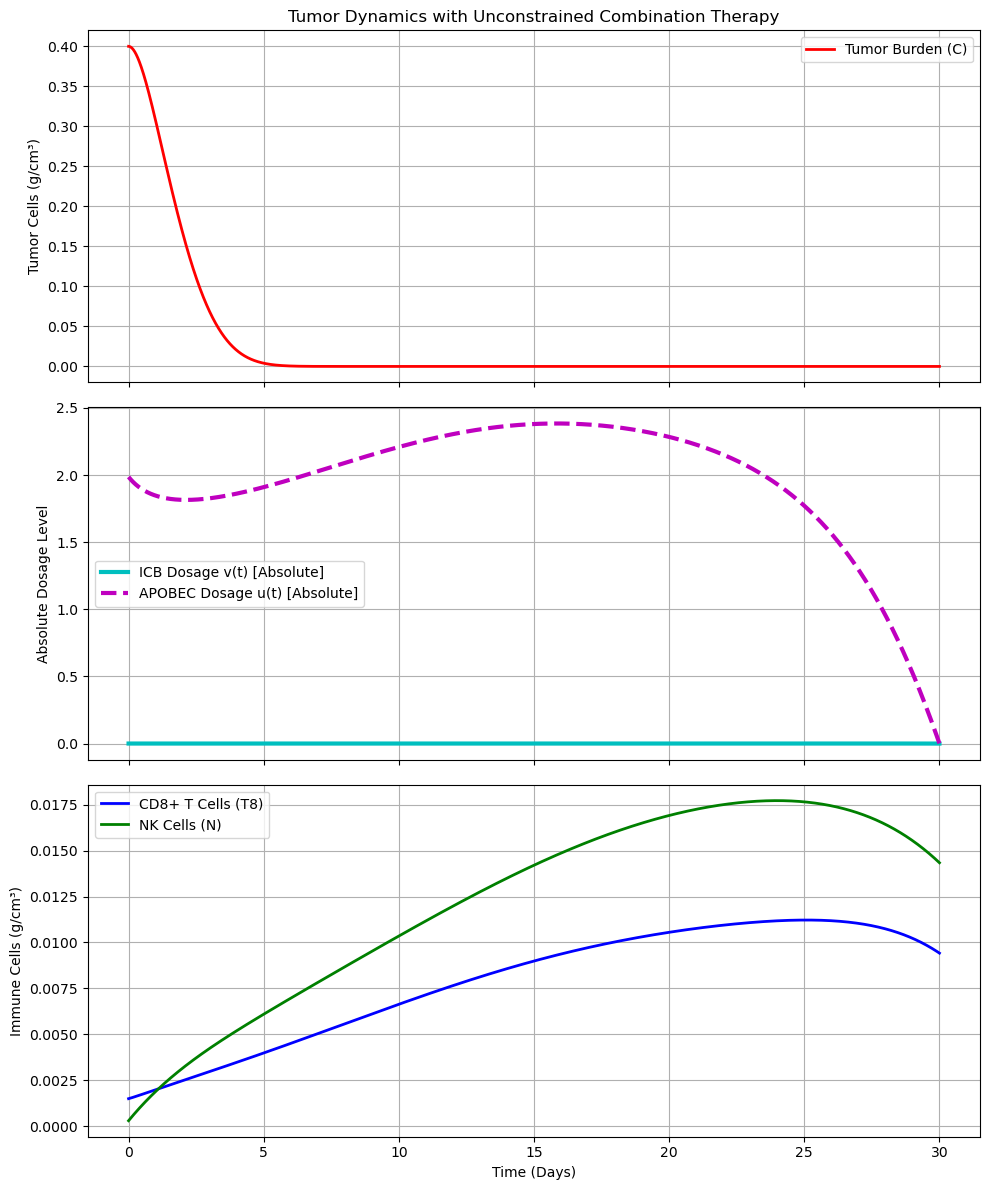

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (From Table 1 & 2). I set the standard biological rates in p
# ==========================================
p = {
    # Tumor
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    
    # DCs
    "lambda_DC_comb": 0.00008,  # Calculated: lambda_DC (4) * D0 (2e-5)
    "K_C": 0.4, "d_D": 0.1,
    
    # NK cells
    "sigma_N": 0.00005,         # From Table 1
    "d_N": 0.1,                 # From Table 1
    "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    
    # Tregs
    "d_Treg": 0.2, 
    "lambda_Tr_comb": 0.0002,   # Calculated: lambda_Tr (0.5) * T10 (4e-4)
    
    # CD8 T cells
    "d_T8": 0.18,               # From Table 1
    "lambda_T8_comb": 0.00108,  # Calculated: lambda_T8 (5.4) * T80 (2e-4)
    "K_Treg": 2.5e-4,           # From Table 1
    "K_D": 4e-4
}

# APOBEC deltas (Target APOBEC Table - Table 1 Baseline). 
# Define the shifts in parameters caused by APOBEC treatment (for unit amount of APOBEC treatment)
d_p = {
    "d_lambda_DC": 0.003 - p["lambda_DC_comb"], # +0.00292
    "d_lambda_T8": 0.001 - p["lambda_T8_comb"], # -0.00008 (Slight decrease)
    "d_sigma_N": 0.0005 - p["sigma_N"]          # +0.00045
}

# Optimization weights 
a = 5000.0     # Penalty for CD8+ injection (v)
w = 0.001      # Penalty for APOBEC dosage (u) 
b = 0.0001     # Weight for tumor burden 
# Limits removed: No v_max or u_max defined

T_final = 30.0       
N_steps = 20000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)

def get_eff_p(p_base, u_val): # Define the effects of APOBEC treatment - multiple unit delta with relative administratio amount
    eff = p_base.copy()
    eff["lambda_DC_comb"] += u_val * d_p["d_lambda_DC"]
    eff["lambda_T8_comb"] += u_val * d_p["d_lambda_T8"]
    eff["sigma_N"]        += u_val * d_p["d_sigma_N"]
    return eff

# ==========================================
# 2. Dual-Control Derivatives
# ==========================================
def state_derivatives(x, v_val, u_val): # The standared ODE equation
    C, D, N, Tr, T8 = x
    eff = get_eff_p(p, u_val)
    
    dC  = eff["lambda_C"]*C*(1 - C/eff["C_M"]) - eff["eta_8"]*T8*C - eff["eta_N"]*N*C - eff["d_C"]*C
    dD  = eff["lambda_DC_comb"] * C / (eff["K_C"] + C) - eff["d_D"]*D
    dN  = eff["sigma_N"] - eff["d_N"]*N - eff["gamma_N"]*Tr*N + eff["a_C"]*N*C / (1 + C/eff["beta_1"] + N/eff["beta_2"])
    dTr = -eff["d_Treg"]*Tr + eff["lambda_Tr_comb"] * C / (eff["K_C"] + C)
    dT8 = -eff["d_T8"]*T8 + eff["lambda_T8_comb"] * (D / (eff["K_D"] + D)) * (1 / (1 + Tr/eff["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

# calcuate the sensitivity of tumor to each cell population
# Move backward in time, because it calculates based on the final goal.
def adjoint_derivatives(x, lam, u_val):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    eff = get_eff_p(p, u_val)
    
    den_KC = eff["K_C"] + C
    den_NK = 1 + C/eff["beta_1"] + N/eff["beta_2"]
    den_KD = eff["K_D"] + D
    den_KTr = 1 + Tr/eff["K_Treg"]

    dl1 = -( b + l1*(eff["lambda_C"] - 2*eff["lambda_C"]*C/eff["C_M"] - eff["eta_8"]*T8 - eff["eta_N"]*N - eff["d_C"]) 
             + l2*(eff["lambda_DC_comb"] * eff["K_C"] / den_KC**2) 
             + l3*(eff["a_C"]*N*(1 + N/eff["beta_2"]) / den_NK**2) 
             + l4*(eff["lambda_Tr_comb"] * eff["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*eff["d_D"] + l5*(eff["lambda_T8_comb"] * (eff["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*eff["eta_N"]*C + l3*(-eff["d_N"] - eff["gamma_N"]*Tr + eff["a_C"]*C*(1 + C/eff["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*eff["gamma_N"]*N - l4*eff["d_Treg"] + l5*(eff["lambda_T8_comb"] * (D / den_KD) * (-1/eff["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*eff["eta_8"]*C - l5*eff["d_T8"] )
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Co-Optimization FBSM Loop
# ==========================================
# First did forward sweep with RK4: take the current guess for drug dosages forward for 30 days
# Backward swwp with RK4: simulate the adjoint equations backward in time. 

x = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))
x[:, 0] = [0.4, 0.0004, 0.0003, 0.0005, 0.0015] # Initial conditions From Table 2

v = np.zeros(N_steps) # ICB Control
u = np.zeros(N_steps) # APOBEC Control

tolerance = 1e-4
max_iter = 500
test = tolerance + 1
iteration = 0

print("Starting Combination Therapy Co-Optimization (Unconstrained)...")

while test > tolerance and iteration < max_iter:
    old_v, old_u, old_x, old_lam = v.copy(), u.copy(), x.copy(), lam.copy()
    
    # FORWARD SWEEP
    for i in range(N_steps - 1):
        v_mid, u_mid = 0.5*(v[i] + v[i+1]), 0.5*(u[i] + u[i+1])
        current_x = np.maximum(x[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v[i], u[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid, u_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid, u_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1], u[i+1])
        
        x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
        
    # BACKWARD SWEEP
    lam[0, -1] = 1.0  
    lam[1:, -1] = 0.0 
    
    for i in range(N_steps - 1, 0, -1):
        x_mid = 0.5 * (x[:, i] + x[:, i-1])
        u_mid = 0.5 * (u[i] + u[i-1])
        
        k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], u[i])
        k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, u_mid)
        k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, u_mid)
        k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, u[i-1])
        
        lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
    # DUAL CONTROL UPDATE 
    v_new = np.zeros(N_steps)
    u_new = np.zeros(N_steps)
    
    for i in range(N_steps):
        C_val, D_val, N_val, Tr_val, T8_val = x[:, i]
        l1, l2, l3, l4, l5 = lam[:, i]
        
        # ICB (v) Update - REMOVED MAX LIMIT
        v_calc = -l5 / (2 * a)
        v_new[i] = max(0.0, v_calc)  # Only bound by 0 (cannot give negative drugs)
        
        # APOBEC (u) Update - REMOVED MAX LIMIT
        term1 = l2 * d_p["d_lambda_DC"] * (C_val / (p["K_C"] + C_val))
        term2 = l3 * d_p["d_sigma_N"]
        term3 = l5 * d_p["d_lambda_T8"] * (D_val / (p["K_D"] + D_val)) * (1 / (1 + Tr_val/p["K_Treg"]))
        
        u_calc = -(term1 + term2 + term3) / (2 * w)
        u_new[i] = max(0.0, u_calc)  # Only bound by 0
        
    # CONVEX COMBINATION 
    v = 0.5 * v_new + 0.5 * old_v
    u = 0.5 * u_new + 0.5 * old_u
    
    test = (np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10) +
            np.sum(np.abs(u - old_u)) / (np.sum(np.abs(u)) + 1e-10) +
            np.sum(np.abs(x - old_x)) / (np.sum(np.abs(x)) + 1e-10) +
            np.sum(np.abs(lam - old_lam)) / (np.sum(np.abs(lam)) + 1e-10))
    iteration += 1
    
    if iteration % 10 == 0:
        print(f"Iteration {iteration}, Error: {test:.5f}")

print(f"Converged in {iteration} iterations.")

# ==========================================
# 4. Plotting
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Tumor
axs[0].plot(t, x[0, :], 'r-', linewidth=2, label='Tumor Burden (C)')
axs[0].set_ylabel('Tumor Cells (g/cm³)')
axs[0].set_title('Tumor Dynamics with Unconstrained Combination Therapy')
axs[0].legend()
axs[0].grid(True)

# Drugs
# Note: Removed normalization since v_max no longer exists
axs[1].plot(t, v, 'c-', linewidth=3, label='ICB Dosage v(t) [Absolute]')
axs[1].plot(t, u, 'm--', linewidth=3, label='APOBEC Dosage u(t) [Absolute]')
axs[1].set_ylabel('Absolute Dosage Level')
axs[1].legend()
axs[1].grid(True)

# Immune
axs[2].plot(t, x[4, :], 'b-', linewidth=2, label='CD8+ T Cells (T8)')
axs[2].plot(t, x[2, :], 'g-', linewidth=2, label='NK Cells (N)')
axs[2].set_xlabel('Time (Days)')
axs[2].set_ylabel('Immune Cells (g/cm³)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

Running simulations...


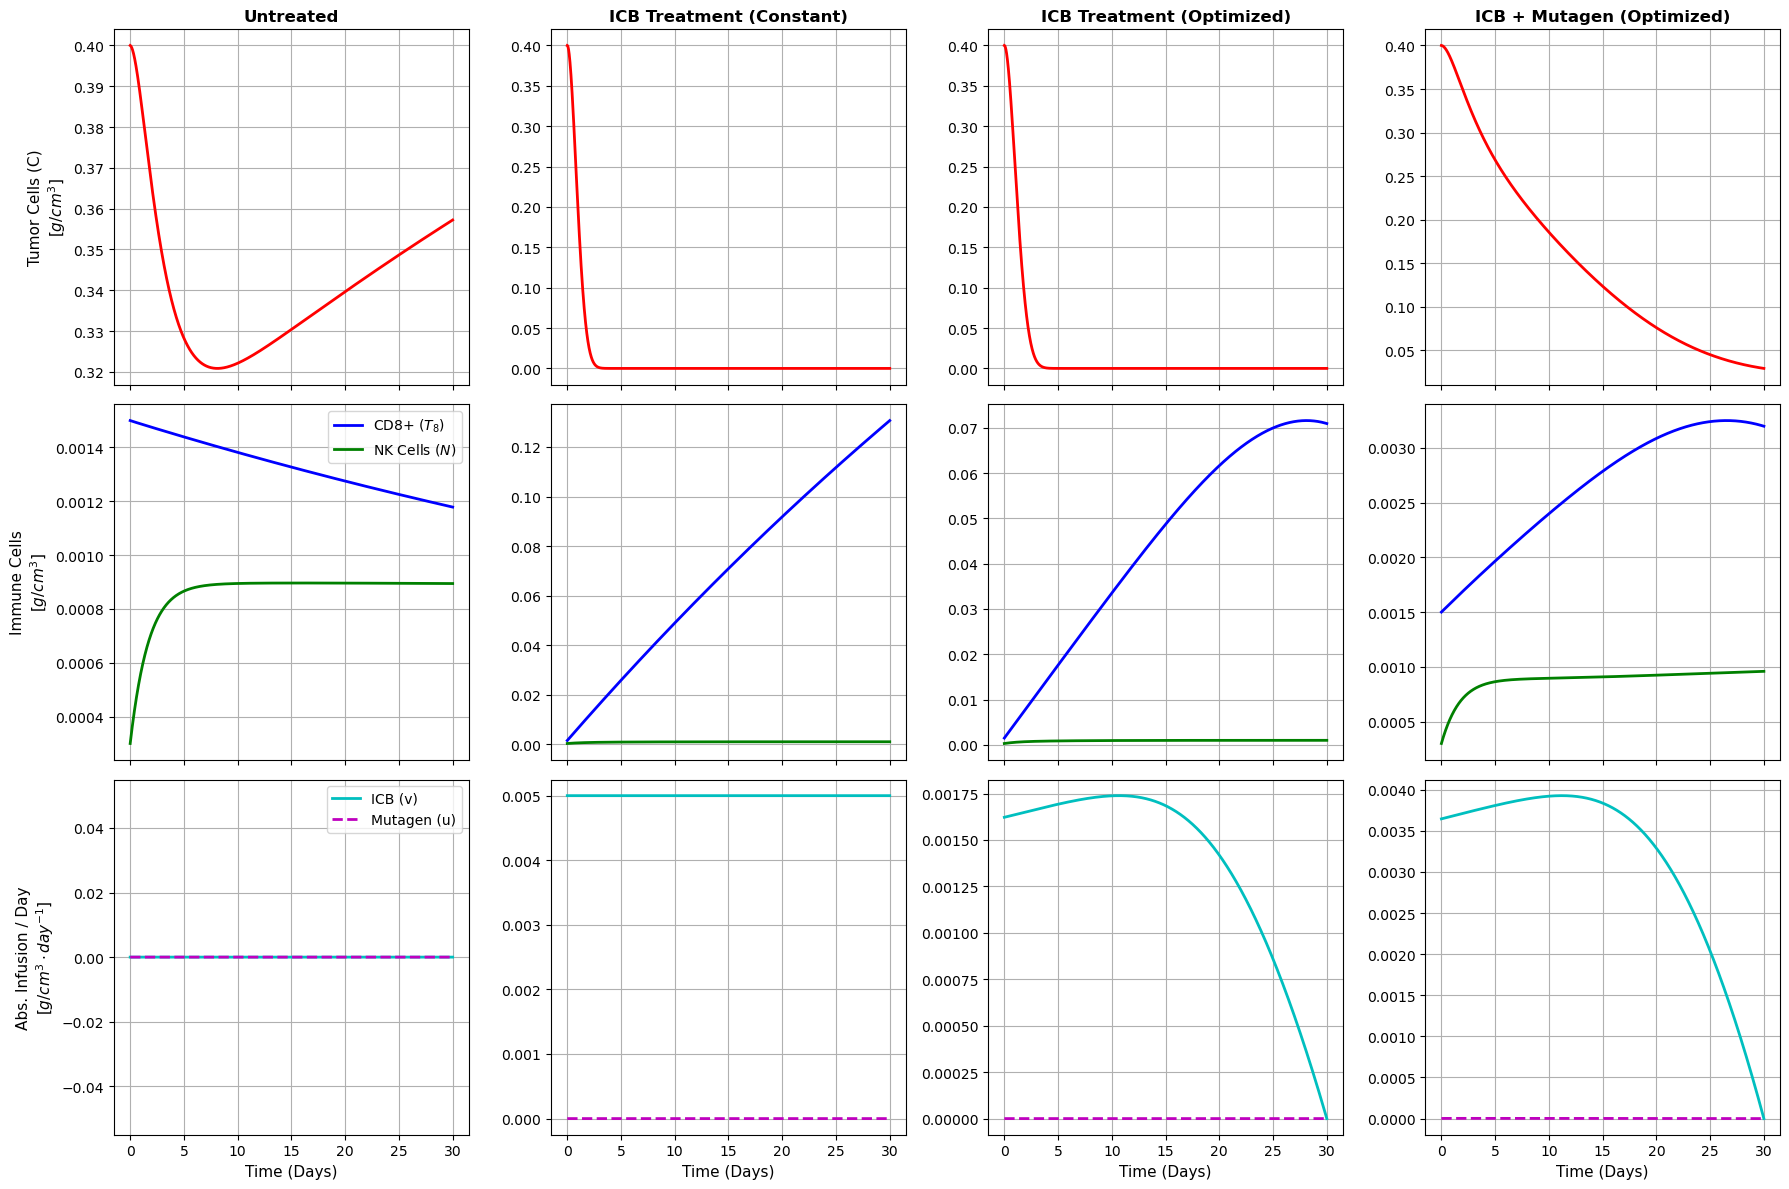

In [1]:
# refined version
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (Updated to KPB25L Model)
# ==========================================
# Base parameters correspond to "No mutagen + untreated" column
p = {
    # Tumor & General constants (kept from original where table is silent)
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    "K_C": 0.4, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4, "K_D": 4e-4,
    "d_Treg": 0.2, 
    
    # Updated specifically from Table for KPB25L
    "lambda_DC_comb": 0.0095, 
    "lambda_Tr_comb": 0.00025,
    "lambda_T8_comb": 3e-06,
    "sigma_N": 0.0005,
    "d_T8": 0.01,
    "d_D": 1.0,
    "K_Treg": 0.01,
    "d_N": 0.5
}

# APOBEC deltas: Shifts caused by Mutagen (Calculated as [Mutagen+ICI] - [No mutagen+ICI])
# This scales the parameters when Mutagen control u(t) = 1.0
d_p = {
    "d_lambda_DC": 0.005 - 0.0075,   # -0.0025
    "d_lambda_T8": 0.0002 - 4e-05,   # +0.00016
    "d_sigma_N": 0.0005 - 0.001      # -0.0005
}

# Optimization Weights & Settings
a = 5000.0     # Penalty for CD8+ injection (v)
w = 1000.0     # Penalty for Mutagen dosage (u) (Adjusted to balance with a)
b = 0.0001     # Weight for tumor burden 

T_final = 30.0       
N_steps = 2000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)
x0 = [0.4, 0.0004, 0.0003, 0.0005, 0.0015]

# ==========================================
# 2. ODE & Adjoint Equations
# ==========================================
def get_eff_p(p_base, u_val):
    eff = p_base.copy()
    eff["lambda_DC_comb"] += u_val * d_p["d_lambda_DC"]
    eff["lambda_T8_comb"] += u_val * d_p["d_lambda_T8"]
    eff["sigma_N"]        += u_val * d_p["d_sigma_N"]
    return eff

def state_derivatives(x, v_val, u_val):
    C, D, N, Tr, T8 = x
    eff = get_eff_p(p, u_val)
    
    dC  = eff["lambda_C"]*C*(1 - C/eff["C_M"]) - eff["eta_8"]*T8*C - eff["eta_N"]*N*C - eff["d_C"]*C
    dD  = eff["lambda_DC_comb"] * C / (eff["K_C"] + C) - eff["d_D"]*D
    dN  = eff["sigma_N"] - eff["d_N"]*N - eff["gamma_N"]*Tr*N + eff["a_C"]*N*C / (1 + C/eff["beta_1"] + N/eff["beta_2"])
    dTr = -eff["d_Treg"]*Tr + eff["lambda_Tr_comb"] * C / (eff["K_C"] + C)
    dT8 = -eff["d_T8"]*T8 + eff["lambda_T8_comb"] * (D / (eff["K_D"] + D)) * (1 / (1 + Tr/eff["K_Treg"])) + v_val
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, u_val):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    eff = get_eff_p(p, u_val)
    
    den_KC = eff["K_C"] + C
    den_NK = 1 + C/eff["beta_1"] + N/eff["beta_2"]
    den_KD = eff["K_D"] + D
    den_KTr = 1 + Tr/eff["K_Treg"]

    dl1 = -( b + l1*(eff["lambda_C"] - 2*eff["lambda_C"]*C/eff["C_M"] - eff["eta_8"]*T8 - eff["eta_N"]*N - eff["d_C"]) 
             + l2*(eff["lambda_DC_comb"] * eff["K_C"] / den_KC**2) 
             + l3*(eff["a_C"]*N*(1 + N/eff["beta_2"]) / den_NK**2) 
             + l4*(eff["lambda_Tr_comb"] * eff["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*eff["d_D"] + l5*(eff["lambda_T8_comb"] * (eff["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*eff["eta_N"]*C + l3*(-eff["d_N"] - eff["gamma_N"]*Tr + eff["a_C"]*C*(1 + C/eff["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*eff["gamma_N"]*N - l4*eff["d_Treg"] + l5*(eff["lambda_T8_comb"] * (D / den_KD) * (-1/eff["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*eff["eta_8"]*C - l5*eff["d_T8"] )
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Core Simulation / Optimization Engine
# ==========================================
def simulate_scenario(optimize_v=False, optimize_u=False, const_v=0.0, max_iter=200):
    x = np.zeros((5, N_steps))
    lam = np.zeros((5, N_steps))
    x[:, 0] = x0
    
    v = np.full(N_steps, const_v)
    u = np.zeros(N_steps)
    
    # If no optimization requested, just run 1 forward sweep
    if not optimize_v and not optimize_u:
        for i in range(N_steps - 1):
            v_mid, u_mid = 0.5*(v[i] + v[i+1]), 0.5*(u[i] + u[i+1])
            current_x = np.maximum(x[:, i], 0.0)
            k1 = dt * state_derivatives(current_x, v[i], u[i])
            k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid, u_mid)
            k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid, u_mid)
            k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1], u[i+1])
            x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
        return x, v, u

    # FBSM Loop for Optimization
    tolerance, test, iteration = 1e-4, 1.0, 0
    while test > tolerance and iteration < max_iter:
        old_v, old_u = v.copy(), u.copy()
        
        # Forward
        for i in range(N_steps - 1):
            v_mid, u_mid = 0.5*(v[i] + v[i+1]), 0.5*(u[i] + u[i+1])
            current_x = np.maximum(x[:, i], 0.0)
            k1 = dt * state_derivatives(current_x, v[i], u[i])
            k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid, u_mid)
            k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid, u_mid)
            k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1], u[i+1])
            x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
            
        # Backward
        lam[:, -1] = 0.0
        lam[0, -1] = 1.0  
        for i in range(N_steps - 1, 0, -1):
            x_mid = 0.5 * (x[:, i] + x[:, i-1])
            u_mid = 0.5 * (u[i] + u[i-1])
            k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], u[i])
            k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, u_mid)
            k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, u_mid)
            k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, u[i-1])
            lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
            
        # Updates
        v_new, u_new = np.zeros(N_steps), np.zeros(N_steps)
        for i in range(N_steps):
            C_val, D_val, N_val, Tr_val, T8_val = x[:, i]
            l1, l2, l3, l4, l5 = lam[:, i]
            
            if optimize_v:
                v_new[i] = max(0.0, -l5 / (2 * a))
            else:
                v_new[i] = const_v
                
            if optimize_u:
                term1 = l2 * d_p["d_lambda_DC"] * (C_val / (p["K_C"] + C_val))
                term2 = l3 * d_p["d_sigma_N"]
                term3 = l5 * d_p["d_lambda_T8"] * (D_val / (p["K_D"] + D_val)) * (1 / (1 + Tr_val/p["K_Treg"]))
                u_new[i] = max(0.0, -(term1 + term2 + term3) / (2 * w))
                
        # Convex combination
        v = 0.5 * v_new + 0.5 * old_v
        u = 0.5 * u_new + 0.5 * old_u
        
        test = (np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10) +
                np.sum(np.abs(u - old_u)) / (np.sum(np.abs(u)) + 1e-10))
        iteration += 1
        
    return x, v, u

# ==========================================
# 4. Run 4 Scenarios & Plot
# ==========================================
print("Running simulations...")
s1_x, s1_v, s1_u = simulate_scenario(optimize_v=False, optimize_u=False)                 # Untreated
s2_x, s2_v, s2_u = simulate_scenario(optimize_v=False, optimize_u=False, const_v=0.005)  # Const ICB
s3_x, s3_v, s3_u = simulate_scenario(optimize_v=True, optimize_u=False)                  # Opt ICB
s4_x, s4_v, s4_u = simulate_scenario(optimize_v=True, optimize_u=True)                   # Opt ICB + Mutagen

scenarios = [
    ("Untreated", s1_x, s1_v, s1_u),
    ("ICB Treatment (Constant)", s2_x, s2_v, s2_u),
    ("ICB Treatment (Optimized)", s3_x, s3_v, s3_u),
    ("ICB + Mutagen (Optimized)", s4_x, s4_v, s4_u)
]

fig, axs = plt.subplots(3, 4, figsize=(18, 12), sharex=True)

for col, (title, x_res, v_res, u_res) in enumerate(scenarios):
    # Row 0: Tumor Burden
    axs[0, col].plot(t, x_res[0, :], 'r-', linewidth=2)
    axs[0, col].set_title(title, fontweight='bold')
    if col == 0: axs[0, col].set_ylabel('Tumor Cells (C)\n$[g/cm^3]$', fontsize=11)
    axs[0, col].grid(True)
    
    # Row 1: CD8+ and NK Cells
    axs[1, col].plot(t, x_res[4, :], 'b-', linewidth=2, label='CD8+ ($T_8$)')
    axs[1, col].plot(t, x_res[2, :], 'g-', linewidth=2, label='NK Cells ($N$)')
    if col == 0: 
        axs[1, col].set_ylabel('Immune Cells\n$[g/cm^3]$', fontsize=11)
        axs[1, col].legend()
    axs[1, col].grid(True)
    
    # Row 2: Drug application per day
    axs[2, col].plot(t, v_res, 'c-', linewidth=2, label='ICB (v)')
    axs[2, col].plot(t, u_res, 'm--', linewidth=2, label='Mutagen (u)')
    if col == 0: 
        axs[2, col].set_ylabel('Abs. Infusion / Day\n$[g/cm^3 \cdot day^{-1}]$', fontsize=11)
        axs[2, col].legend()
    axs[2, col].set_xlabel('Time (Days)', fontsize=11)
    axs[2, col].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (From your code)
# ==========================================
p = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    "lambda_DC_comb": 0.00008,  
    "K_C": 0.4, "d_D": 0.1,
    "sigma_N": 0.00005,         
    "d_N": 0.1,                 
    "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    "d_Treg": 0.2, 
    "lambda_Tr_comb": 0.0002,   
    "d_T8": 0.18,               
    "lambda_T8_comb": 0.00108,  
    "K_Treg": 2.5e-4,           
    "K_D": 4e-4
}

d_p = {
    "d_lambda_DC": 0.003 - p["lambda_DC_comb"], 
    "d_lambda_T8": 0.001 - p["lambda_T8_comb"], 
    "d_sigma_N": 0.0005 - p["sigma_N"]          
}

T_final = 30.0       
N_steps = 1000 # Reduced for the grid search speed
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)
x0 = [0.4, 0.0004, 0.0003, 0.0005, 0.0015]

v_max = 0.0008
u_max = 1.0    

def get_eff_p(p_base, u_val):
    eff = p_base.copy()
    eff["lambda_DC_comb"] += u_val * d_p["d_lambda_DC"]
    eff["lambda_T8_comb"] += u_val * d_p["d_lambda_T8"]
    eff["sigma_N"]        += u_val * d_p["d_sigma_N"]
    return eff

# ==========================================
# 2. Derivative Functions
# ==========================================
def state_derivatives(x, v_val, u_val):
    C, D, N, Tr, T8 = x
    eff = get_eff_p(p, u_val)
    
    dC  = eff["lambda_C"]*C*(1 - C/eff["C_M"]) - eff["eta_8"]*T8*C - eff["eta_N"]*N*C - eff["d_C"]*C
    dD  = eff["lambda_DC_comb"] * C / (eff["K_C"] + C) - eff["d_D"]*D
    dN  = eff["sigma_N"] - eff["d_N"]*N - eff["gamma_N"]*Tr*N + eff["a_C"]*N*C / (1 + C/eff["beta_1"] + N/eff["beta_2"])
    dTr = -eff["d_Treg"]*Tr + eff["lambda_Tr_comb"] * C / (eff["K_C"] + C)
    dT8 = -eff["d_T8"]*T8 + eff["lambda_T8_comb"] * (D / (eff["K_D"] + D)) * (1 / (1 + Tr/eff["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, u_val, b_weight):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    eff = get_eff_p(p, u_val)
    
    den_KC = eff["K_C"] + C
    den_NK = 1 + C/eff["beta_1"] + N/eff["beta_2"]
    den_KD = eff["K_D"] + D
    den_KTr = 1 + Tr/eff["K_Treg"]

    dl1 = -( b_weight + l1*(eff["lambda_C"] - 2*eff["lambda_C"]*C/eff["C_M"] - eff["eta_8"]*T8 - eff["eta_N"]*N - eff["d_C"]) 
             + l2*(eff["lambda_DC_comb"] * eff["K_C"] / den_KC**2) 
             + l3*(eff["a_C"]*N*(1 + N/eff["beta_2"]) / den_NK**2) 
             + l4*(eff["lambda_Tr_comb"] * eff["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*eff["d_D"] + l5*(eff["lambda_T8_comb"] * (eff["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*eff["eta_N"]*C + l3*(-eff["d_N"] - eff["gamma_N"]*Tr + eff["a_C"]*C*(1 + C/eff["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*eff["gamma_N"]*N - l4*eff["d_Treg"] + l5*(eff["lambda_T8_comb"] * (D / den_KD) * (-1/eff["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*eff["eta_8"]*C - l5*eff["d_T8"] )
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Optimization Wrapper Function
# ==========================================
def solve_dual_control(a_weight, w_weight, b_weight, max_iter=250, tolerance=1e-3):
    """Runs your specific FBSM for given penalties a and w."""
    x = np.zeros((5, N_steps))
    lam = np.zeros((5, N_steps))
    x[:, 0] = x0

    v = np.zeros(N_steps)
    u = np.zeros(N_steps)

    test = tolerance + 1
    iteration = 0

    while test > tolerance and iteration < max_iter:
        old_v, old_u, old_x, old_lam = v.copy(), u.copy(), x.copy(), lam.copy()
        
        # FORWARD SWEEP
        for i in range(N_steps - 1):
            v_mid, u_mid = 0.5*(v[i] + v[i+1]), 0.5*(u[i] + u[i+1])
            current_x = np.maximum(x[:, i], 0.0)
            
            k1 = dt * state_derivatives(current_x, v[i], u[i])
            k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid, u_mid)
            k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid, u_mid)
            k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1], u[i+1])
            
            x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
            
        # BACKWARD SWEEP
        lam[0, -1] = 1.0  
        lam[1:, -1] = 0.0 
        
        for i in range(N_steps - 1, 0, -1):
            x_mid = 0.5 * (x[:, i] + x[:, i-1])
            u_mid = 0.5 * (u[i] + u[i-1])
            
            k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], u[i], b_weight)
            k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, u_mid, b_weight)
            k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, u_mid, b_weight)
            k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, u[i-1], b_weight)
            
            lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
            
        # DUAL CONTROL UPDATE 
        v_new = np.zeros(N_steps)
        u_new = np.zeros(N_steps)
        
        for i in range(N_steps):
            C_val, D_val, N_val, Tr_val, T8_val = x[:, i]
            l1, l2, l3, l4, l5 = lam[:, i]
            
            # ICB (v) Update
            v_calc = -l5 / (2 * a_weight)
            v_new[i] = max(0.0, min(v_max, v_calc))
            
            # APOBEC (u) Update 
            term1 = l2 * d_p["d_lambda_DC"] * (C_val / (p["K_C"] + C_val))
            term2 = l3 * d_p["d_sigma_N"]
            term3 = l5 * d_p["d_lambda_T8"] * (D_val / (p["K_D"] + D_val)) * (1 / (1 + Tr_val/p["K_Treg"]))
            
            u_calc = -(term1 + term2 + term3) / (2 * w_weight)
            u_new[i] = max(0.0, min(u_max, u_calc))
            
        # CONVEX COMBINATION 
        v = 0.5 * v_new + 0.5 * old_v
        u = 0.5 * u_new + 0.5 * old_u
        
        diff_v = np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10)
        diff_u = np.sum(np.abs(u - old_u)) / (np.sum(np.abs(u)) + 1e-10)
        test = diff_v + diff_u
        iteration += 1

    return x[0, -1], np.sum(v) * dt, np.sum(u) * dt

# ==========================================
# 4. Generating the Data (Sweeping 'a' and 'w')
# ==========================================
num_points = 10 # Increase to 30+ for smoother final lines

b_fixed = 0.0001
w_fixed_list = [0.005, 0.001, 0.0001] # Different penalties for APOBEC
a_range = np.linspace(4000, 6000, num_points)

print("Sweeping parameter 'a' (ICB Penalty)...")
res_C_a = {w: [] for w in w_fixed_list}
res_V_a = {w: [] for w in w_fixed_list}

for w in w_fixed_list:
    for a in a_range:
        c30, dose_v, _ = solve_dual_control(a, w, b_fixed)
        res_C_a[w].append(c30)
        res_V_a[w].append(dose_v)

a_fixed_list = [4000, 5000, 6000] # Different penalties for ICB
w_range = np.linspace(0.0001, 0.01, num_points) 

print("Sweeping parameter 'w' (APOBEC Penalty)...")
res_C_w = {a: [] for a in a_fixed_list}
res_U_w = {a: [] for a in a_fixed_list}

for a in a_fixed_list:
    for w in w_range:
        c30, _, dose_u = solve_dual_control(a, w, b_fixed)
        res_C_w[a].append(c30)
        res_U_w[a].append(dose_u)

print("Plotting...")

# ==========================================
# 5. Plotting the 4 Graphs
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
colors = {0: 'blue', 1: 'red', 2: 'cyan'}

# Graph C: C(t30) vs a
for i, w in enumerate(w_fixed_list):
    axs[0, 0].plot(a_range, res_C_a[w], color=colors[i], linewidth=2, label=f'w = {w}')
axs[0, 0].set_xlabel('a (ICB Cost Penalty)')
axs[0, 0].set_ylabel('C($t_{30}$) (g/cm$^3$)')
axs[0, 0].set_title('(C) Final Tumor Burden vs ICB Cost')
axs[0, 0].legend()

# Graph D: Total Dose v vs a
for i, w in enumerate(w_fixed_list):
    axs[0, 1].plot(a_range, res_V_a[w], color=colors[i], linewidth=2, label=f'w = {w}')
axs[0, 1].set_xlabel('a (ICB Cost Penalty)')
axs[0, 1].set_ylabel('Total ICB Injection Dose')
axs[0, 1].set_title('(D) Total ICB Administered vs ICB Cost')
axs[0, 1].legend()

# Graph E: C(t30) vs w
for i, a in enumerate(a_fixed_list):
    axs[1, 0].plot(w_range, res_C_w[a], color=colors[i], linewidth=2, label=f'a = {a}')
axs[1, 0].set_xlabel('w (APOBEC Cost Penalty)')
axs[1, 0].set_ylabel('C($t_{30}$) (g/cm$^3$)')
axs[1, 0].set_title('(E) Final Tumor Burden vs APOBEC Cost')
axs[1, 0].legend()

# Graph F: Total Dose u vs w
for i, a in enumerate(a_fixed_list):
    axs[1, 1].plot(w_range, res_U_w[a], color=colors[i], linewidth=2, label=f'a = {a}')
axs[1, 1].set_xlabel('w (APOBEC Cost Penalty)')
axs[1, 1].set_ylabel('Total APOBEC Injection Dose')
axs[1, 1].set_title('(F) Total APOBEC Administered vs APOBEC Cost')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

### ### Treatment space based on the parameters

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. Base Parameters (Untreated / No Mutagen)
# ==========================================
base_p = {
    "eta_8":328.55,
    "eta_N":300,
    "d_C":0.17,

    "lambda_DC_comb":8e-5,
    "K_C":0.4,
    "d_D":0.1,

    "sigma_N":5e-5,
    "d_N":0.1,
    "gamma_N":150,
    "a_C":0.5,
    "beta_1":0.4,
    "beta_2":2e-4,

    "d_Tr":0.2,
    "lambda_Tr_comb":2e-4,

    "d_T8":0.18,
    "lambda_T8_comb":0.00108,
    "K_Treg":2.5e-4,
    "K_D":4e-4
}
# Optimal Control parameters
a = 5000.0 # The penalty for ICB application
b = 0.0001 # The penalty for tumor load
T_days = 30.0
dt = 0.01  # Step size (keep small enough for stability, large enough for speed)
time_steps = int(T_days / dt)
t = np.linspace(0, T_days, time_steps)



In [ ]:
# ==========================================
# 2. Forward-Backward Sweeping Method Core
# ==========================================
def solve_optimal_control(p, x0, a, b, tol=1e-3, max_iter=50):
    # Initialize state (x), adjoints (adj), and control (v)
    x = np.zeros((5, time_steps))
    adj = np.zeros((5, time_steps))
    v = np.zeros(time_steps)
    
    # Pre-extract params for speed in the loop
    l_C, C_M, e_8, e_N, d_C = p["lambda_C"], p["C_M"], p["eta_8"], p["eta_N"], p["d_C"]
    l_DC, K_C, d_D = p["lambda_DC_comb"], p["K_C"], p["d_D"]
    s_N, d_N, g_N, a_C, b_1, b_2 = p["sigma_N"], p["d_N"], p["gamma_N"], p["a_C"], p["beta_1"], p["beta_2"]
    l_Tr = p["lambda_Tr_comb"]
    d_T8, l_T8, K_D, K_Treg = p["d_T8"], p["lambda_T8_comb"], p["K_D"], p["K_Treg"]
    
    for iteration in range(max_iter):
        old_v = v.copy()
        
        # --- FORWARD PASS (Euler) ---
        x[:, 0] = x0
        for i in range(time_steps - 1):
            C, D, N, Tr, T8 = np.maximum(x[:, i], 0)
            
            dC = l_C*C*(1 - C/C_M) - e_8*T8*C - e_N*N*C - d_C*C
            dD = l_DC*C / (K_C + C) - d_D*D
            dN = s_N - d_N*N - g_N*Tr*N + a_C*N*C / (1 + C/b_1 + N/b_2)
            dTr = -0.2*Tr + l_Tr*C / (K_C + C)
            dT8 = -d_T8*T8 + l_T8 * (D / (K_D + D)) * (1 / (1 + Tr/K_Treg)) + v[i]
            
            x[:, i+1] = np.maximum(x[:, i] + np.array([dC, dD, dN, dTr, dT8]) * dt, 0)
            
        # --- BACKWARD PASS (Adjoints) ---
        adj[:, -1] = [1.0, 0.0, 0.0, 0.0, 0.0] 
        
        for i in range(time_steps - 1, 0, -1):
            C, D, N, Tr, T8 = np.maximum(x[:, i], 0)
            p1, p2, p3, p4, p5 = adj[:, i]
            
            dp1 = -a - p1*(l_C*(1 - 2*C/C_M) - e_8*T8 - e_N*N - d_C) \
                     - p2*(l_DC*K_C / (K_C + C)**2) \
                     - p3*(a_C*N*(1 + N/b_2) / (1 + C/b_1 + N/b_2)**2) \
                     - p4*(l_Tr*K_C / (K_C + C)**2) \
                     - p5*(0) 
                     
            dp2 = -p2*(-d_D) - p5*(l_T8 * (K_D / (K_D + D)**2) * (1 / (1 + Tr/K_Treg)))
            dp3 = -p1*(-e_N*C) - p3*(-d_N - g_N*Tr + a_C*C*(1 + C/b_1) / (1 + C/b_1 + N/b_2)**2)
            dp4 = -p3*(-g_N*N) - p4*(-0.2) - p5*(l_T8 * (D / (K_D + D)) * (-1/K_Treg) / (1 + Tr/K_Treg)**2)
            dp5 = -p1*(-e_8*C) - p5*(-d_T8)
            
            adj[:, i-1] = adj[:, i] - np.array([dp1, dp2, dp3, dp4, dp5]) * dt
            
        # --- CONTROL UPDATE ---
        # FIX 1: Add an upper bound to prevent numerical explosion
        # We clip the maximum allowable dose per time step to 0.01 
        v_new = np.clip(-adj[4, :] / b, 0.0, 0.01) 
        
        # FIX 2: More conservative step. 80% old, 20% new (instead of 50/50)
        v = 0.8 * v + 0.2 * v_new 
        
        if np.sum(np.abs(v - old_v)) < tol * time_steps:
            break
            
    return x, v

# ==========================================
# 3. Parameter Sweep Setup
# ==========================================
x0 = [0.8, 0.001, 0.001, 0.0001, 0.001] # Initial conditions
grid_size = 15 # NOTE: Set to 40 or 50 for publication-quality smooth plots

l_C_vals = np.linspace(1.0, 2.2, grid_size)
C_M_vals = np.linspace(0.4, 1.2, grid_size)
L_C_mesh, C_M_mesh = np.meshgrid(l_C_vals, C_M_vals)

C_final = np.zeros((grid_size, grid_size))
Dose_total = np.zeros((grid_size, grid_size))

print(f"Starting parameter sweep ({grid_size}x{grid_size} = {grid_size**2} iterations)...")
for i in range(grid_size):
    for j in range(grid_size):
        # Update specific parameters for this grid point
        p_current = base_p.copy()
        p_current["lambda_C"] = L_C_mesh[i, j]
        p_current["C_M"] = C_M_mesh[i, j]
        
        # Run FBSM
        x_opt, v_opt = solve_optimal_control(p_current, x0, a, b)
        
        # Extract desired outputs
        C_final[i, j] = x_opt[0, -1]          # Tumor at t=30
        Dose_total[i, j] = np.trapezoid(v_opt, t) # Total integral of control
        
print("Sweep complete. Generating plots...")

# ==========================================
# 4. Plotting (Reproducing A, B, C, D)
# ==========================================
fig = plt.figure(figsize=(14, 10))

# Custom colormap to match your image closely
cmap_choice = 'viridis'

# (A) 2D Heatmap: Final Tumor
axA = fig.add_subplot(221)
cfA = axA.contourf(L_C_mesh, C_M_mesh, C_final, levels=50, cmap=cmap_choice)
axA.set_xlabel('$\lambda_C$ (day$^{-1}$)', fontsize=12)
axA.set_ylabel('$C_M$ (g/cm$^3$)', fontsize=12)
axA.set_title('(A)', loc='left', fontsize=14, fontweight='bold')
plt.colorbar(cfA, ax=axA)

# (B) 3D Surface: Final Tumor
axB = fig.add_subplot(222, projection='3d')
surfB = axB.plot_surface(L_C_mesh, C_M_mesh, C_final, cmap=cmap_choice, edgecolor='none')
axB.set_xlabel('$\lambda_C$ (day$^{-1}$)')
axB.set_ylabel('$C_M$ (g/cm$^3$)')
axB.set_zlabel('$C(t_{30})$ (g/cm$^3$)')
axB.set_title('(B)', loc='left', fontsize=14, fontweight='bold')

# (C) 2D Heatmap: Total Dose
axC = fig.add_subplot(223)
cfC = axC.contourf(L_C_mesh, C_M_mesh, Dose_total, levels=50, cmap=cmap_choice)
axC.set_xlabel('$\lambda_C$ (day$^{-1}$)', fontsize=12)
axC.set_ylabel('$C_M$ (g/cm$^3$)', fontsize=12)
axC.set_title('(C)', loc='left', fontsize=14, fontweight='bold')
plt.colorbar(cfC, ax=axC)

# (D) 3D Surface: Total Dose
axD = fig.add_subplot(224, projection='3d')
surfD = axD.plot_surface(L_C_mesh, C_M_mesh, Dose_total, cmap=cmap_choice, edgecolor='none')
axD.set_xlabel('$\lambda_C$ (day$^{-1}$)')
axD.set_ylabel('$C_M$ (g/cm$^3$)')
axD.set_zlabel('Total CD8+ cell injection\ndose (g/cm$^3$)')
axD.set_title('(D)', loc='left', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
def solve_optimal_control(p, x0, a, b, v_guess=None, tol=1e-4, max_iter=500):
    x = np.zeros((5, time_steps))
    adj = np.zeros((5, time_steps))
    
    # Use the previous grid point's solution as a head start, otherwise start at 0
    if v_guess is not None:
        v = v_guess.copy()
    else:
        v = np.zeros(time_steps)
        
    l_C, C_M, e_8, e_N, d_C = p["lambda_C"], p["C_M"], p["eta_8"], p["eta_N"], p["d_C"]
    l_DC, K_C, d_D = p["lambda_DC_comb"], p["K_C"], p["d_D"]
    s_N, d_N, g_N, a_C, b_1, b_2 = p["sigma_N"], p["d_N"], p["gamma_N"], p["a_C"], p["beta_1"], p["beta_2"]
    l_Tr = p["lambda_Tr_comb"]
    d_T8, l_T8, K_D, K_Treg = p["d_T8"], p["lambda_T8_comb"], p["K_D"], p["K_Treg"]
    
    for iteration in range(max_iter):
        old_v = v.copy()
        
        # --- FORWARD PASS (Euler) ---
        x[:, 0] = x0
        for i in range(time_steps - 1):
            C, D, N, Tr, T8 = np.maximum(x[:, i], 0)
            
            dC = l_C*C*(1 - C/C_M) - e_8*T8*C - e_N*N*C - d_C*C
            dD = l_DC*C / (K_C + C) - d_D*D
            dN = s_N - d_N*N - g_N*Tr*N + a_C*N*C / (1 + C/b_1 + N/b_2)
            dTr = -0.2*Tr + l_Tr*C / (K_C + C)
            dT8 = -d_T8*T8 + l_T8 * (D / (K_D + D)) * (1 / (1 + Tr/K_Treg)) + v[i]
            
            x[:, i+1] = np.maximum(x[:, i] + np.array([dC, dD, dN, dTr, dT8]) * dt, 0)
            
        # --- BACKWARD PASS (Adjoints) ---
        adj[:, -1] = [1.0, 0.0, 0.0, 0.0, 0.0] 
        
        for i in range(time_steps - 1, 0, -1):
            C, D, N, Tr, T8 = np.maximum(x[:, i], 0)
            p1, p2, p3, p4, p5 = adj[:, i]
            
            dp1 = -a - p1*(l_C*(1 - 2*C/C_M) - e_8*T8 - e_N*N - d_C) \
                     - p2*(l_DC*K_C / (K_C + C)**2) \
                     - p3*(a_C*N*(1 + N/b_2) / (1 + C/b_1 + N/b_2)**2) \
                     - p4*(l_Tr*K_C / (K_C + C)**2) \
                     - p5*(0)
                     
            dp2 = -p2*(-d_D) - p5*(l_T8 * (K_D / (K_D + D)**2) * (1 / (1 + Tr/K_Treg)))
            dp3 = -p1*(-e_N*C) - p3*(-d_N - g_N*Tr + a_C*C*(1 + C/b_1) / (1 + C/b_1 + N/b_2)**2)
            dp4 = -p3*(-g_N*N) - p4*(-0.2) - p5*(l_T8 * (D / (K_D + D)) * (-1/K_Treg) / (1 + Tr/K_Treg)**2)
            dp5 = -p1*(-e_8*C) - p5*(-d_T8)
            
            adj[:, i-1] = adj[:, i] - np.array([dp1, dp2, dp3, dp4, dp5]) * dt
            
        # --- CONTROL UPDATE ---
        # Relaxed bound (1.0) so we don't artificially restrict the optimal dose
        v_new = np.clip(-adj[4, :] / b, 0.0, 1.0) 
        
        # Gentle update: 90% old trajectory, 10% new trajectory. Highly stable.
        v = 0.9 * v + 0.1 * v_new 
        
        if np.sum(np.abs(v - old_v)) < tol * time_steps:
            break
            
    return x, v

In [ ]:
# Implement warm starting in the loop
x0 = [0.8, 0.001, 0.001, 0.0001, 0.001] # Initial conditions
grid_size = 15 # NOTE: Set to 40 or 50 for publication-quality smooth plots
C_final = np.zeros((grid_size, grid_size))
Dose_total = np.zeros((grid_size, grid_size))

# Initialize an empty guess
current_v_guess = np.zeros(time_steps)
l_C_vals = np.linspace(1.0, 2.2, grid_size)
C_M_vals = np.linspace(0.4, 1.2, grid_size)
L_C_mesh, C_M_mesh = np.meshgrid(l_C_vals, C_M_vals)



print(f"Starting parameter sweep ({grid_size}x{grid_size} = {grid_size**2} iterations)...")
for i in range(grid_size):
    for j in range(grid_size):
        p_current = base_p.copy()
        p_current["lambda_C"] = L_C_mesh[i, j]
        p_current["C_M"] = C_M_mesh[i, j]
        
        # Pass the guess into the solver
        x_opt, v_opt = solve_optimal_control(p_current, x0, a, b, v_guess=current_v_guess)
        
        # WARM START: Save this iteration's optimal dose to use as the head-start for the next point
        current_v_guess = v_opt 
        
        C_final[i, j] = x_opt[0, -1]          
        Dose_total[i, j] = np.trapezoid(v_opt, t) 
        
print("Sweep complete. Generating plots...")

# ==========================================
# 4. Plotting (Reproducing A, B, C, D)
# ==========================================
fig = plt.figure(figsize=(14, 10))

# Custom colormap to match your image closely
cmap_choice = 'viridis'

# (A) 2D Heatmap: Final Tumor
axA = fig.add_subplot(221)
cfA = axA.contourf(L_C_mesh, C_M_mesh, C_final, levels=50, cmap=cmap_choice)
axA.set_xlabel('$\lambda_C$ (day$^{-1}$)', fontsize=12)
axA.set_ylabel('$C_M$ (g/cm$^3$)', fontsize=12)
axA.set_title('(A)', loc='left', fontsize=14, fontweight='bold')
plt.colorbar(cfA, ax=axA)

# (B) 3D Surface: Final Tumor
axB = fig.add_subplot(222, projection='3d')
surfB = axB.plot_surface(L_C_mesh, C_M_mesh, C_final, cmap=cmap_choice, edgecolor='none')
axB.set_xlabel('$\lambda_C$ (day$^{-1}$)')
axB.set_ylabel('$C_M$ (g/cm$^3$)')
axB.set_zlabel('$C(t_{30})$ (g/cm$^3$)')
axB.set_title('(B)', loc='left', fontsize=14, fontweight='bold')

# (C) 2D Heatmap: Total Dose
axC = fig.add_subplot(223)
cfC = axC.contourf(L_C_mesh, C_M_mesh, Dose_total, levels=50, cmap=cmap_choice)
axC.set_xlabel('$\lambda_C$ (day$^{-1}$)', fontsize=12)
axC.set_ylabel('$C_M$ (g/cm$^3$)', fontsize=12)
axC.set_title('(C)', loc='left', fontsize=14, fontweight='bold')
plt.colorbar(cfC, ax=axC)

# (D) 3D Surface: Total Dose
axD = fig.add_subplot(224, projection='3d')
surfD = axD.plot_surface(L_C_mesh, C_M_mesh, Dose_total, cmap=cmap_choice, edgecolor='none')
axD.set_xlabel('$\lambda_C$ (day$^{-1}$)')
axD.set_ylabel('$C_M$ (g/cm$^3$)')
axD.set_zlabel('Total CD8+ cell injection\ndose (g/cm$^3$)')
axD.set_title('(D)', loc='left', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. Base Parameters
# ==========================================
base_p = {
    "eta_8": 328.55,
    "eta_N": 300,
    "d_C": 0.17,
    "lambda_DC_comb": 8e-5,
    "K_C": 0.4,
    "d_D": 0.1,
    "sigma_N": 5e-5,
    "d_N": 0.1,
    "gamma_N": 150,
    "a_C": 0.5,
    "beta_1": 0.4,
    "beta_2": 2e-4,
    "d_Tr": 0.2,
    "lambda_Tr_comb": 2e-4,
    "d_T8": 0.18,
    "lambda_T8_comb": 0.00108,
    "K_Treg": 2.5e-4,
    "K_D": 4e-4
}

# Explicitly renamed weights to prevent Hamiltonian mix-ups
weight_v = 5000.0  # Penalty for the drug (replaces 'a')
weight_C = 0.0001  # Penalty for the tumor load (replaces 'b')

T_days = 30.0
dt = 0.01  
time_steps = int(T_days / dt)
t = np.linspace(0, T_days, time_steps)

# ==========================================
# 2. Forward-Backward Sweeping Method
# ==========================================
def solve_optimal_control(p, x0, w_v, w_C, v_guess=None, tol=1e-4, max_iter=500):
    x = np.zeros((5, time_steps))
    adj = np.zeros((5, time_steps))
    
    # Warm start
    if v_guess is not None:
        v = v_guess.copy()
    else:
        v = np.zeros(time_steps)
        
    l_C, C_M, e_8, e_N, d_C = p["lambda_C"], p["C_M"], p["eta_8"], p["eta_N"], p["d_C"]
    l_DC, K_C, d_D = p["lambda_DC_comb"], p["K_C"], p["d_D"]
    s_N, d_N, g_N, a_C, b_1, b_2 = p["sigma_N"], p["d_N"], p["gamma_N"], p["a_C"], p["beta_1"], p["beta_2"]
    l_Tr = p["lambda_Tr_comb"]
    d_T8, l_T8, K_D, K_Treg = p["d_T8"], p["lambda_T8_comb"], p["K_D"], p["K_Treg"]
    
    for iteration in range(max_iter):
        old_v = v.copy()
        
        # --- FORWARD PASS (Euler) ---
        x[:, 0] = x0
        for i in range(time_steps - 1):
            C, D, N, Tr, T8 = np.maximum(x[:, i], 0)
            
            dC = l_C*C*(1 - C/C_M) - e_8*T8*C - e_N*N*C - d_C*C
            dD = l_DC*C / (K_C + C) - d_D*D
            dN = s_N - d_N*N - g_N*Tr*N + a_C*N*C / (1 + C/b_1 + N/b_2)
            dTr = -0.2*Tr + l_Tr*C / (K_C + C)
            dT8 = -d_T8*T8 + l_T8 * (D / (K_D + D)) * (1 / (1 + Tr/K_Treg)) + v[i]
            
            x[:, i+1] = np.maximum(x[:, i] + np.array([dC, dD, dN, dTr, dT8]) * dt, 0)
            
        # --- BACKWARD PASS (Adjoints) ---
        adj[:, -1] = [1.0, 0.0, 0.0, 0.0, 0.0] 
        
        for i in range(time_steps - 1, 0, -1):
            C, D, N, Tr, T8 = np.maximum(x[:, i], 0)
            p1, p2, p3, p4, p5 = adj[:, i]
            
            # FIX: Used weight_C instead of 'a' for the state penalty
            dp1 = -w_C - p1*(l_C*(1 - 2*C/C_M) - e_8*T8 - e_N*N - d_C) \
                     - p2*(l_DC*K_C / (K_C + C)**2) \
                     - p3*(a_C*N*(1 + N/b_2) / (1 + C/b_1 + N/b_2)**2) \
                     - p4*(l_Tr*K_C / (K_C + C)**2) \
                     - p5*(0)
                     
            dp2 = -p2*(-d_D) - p5*(l_T8 * (K_D / (K_D + D)**2) * (1 / (1 + Tr/K_Treg)))
            dp3 = -p1*(-e_N*C) - p3*(-d_N - g_N*Tr + a_C*C*(1 + C/b_1) / (1 + C/b_1 + N/b_2)**2)
            dp4 = -p3*(-g_N*N) - p4*(-0.2) - p5*(l_T8 * (D / (K_D + D)) * (-1/K_Treg) / (1 + Tr/K_Treg)**2)
            dp5 = -p1*(-e_8*C) - p5*(-d_T8)
            
            adj[:, i-1] = adj[:, i] - np.array([dp1, dp2, dp3, dp4, dp5]) * dt
            
        # --- CONTROL UPDATE ---
        # FIX: Divided by weight_v instead of 'b' for the control cost
        v_new = np.clip(-adj[4, :] / w_v, 0.0, 1.0) 
        
        # Gentle update prevents numerical oscillations
        v = 0.8 * v + 0.2 * v_new 
        
        if np.sum(np.abs(v - old_v)) < tol * time_steps:
            break
            
    return x, v

# ==========================================
# 3. Parameter Sweep
# ==========================================
x0 = [0.8, 0.001, 0.001, 0.0001, 0.001]
grid_size = 20 # Bumped to 20 for smoother curves

l_C_vals = np.linspace(1.0, 2.2, grid_size)
C_M_vals = np.linspace(0.4, 1.2, grid_size)
L_C_mesh, C_M_mesh = np.meshgrid(l_C_vals, C_M_vals)

C_final = np.zeros((grid_size, grid_size))
Dose_total = np.zeros((grid_size, grid_size))

# Create a 2D array to hold the history of guesses
v_guesses = np.zeros((grid_size, grid_size, time_steps))

print(f"Starting parameter sweep ({grid_size}x{grid_size} = {grid_size**2} iterations)...")
for i in range(grid_size):
    for j in range(grid_size):
        p_current = base_p.copy()
        p_current["lambda_C"] = L_C_mesh[i, j]
        p_current["C_M"] = C_M_mesh[i, j]

        # --- SMART WARM START LOGIC ---
        if j > 0:
            # Use the solution from the point just to the left
            guess = v_guesses[i, j-1]
        elif i > 0:
            # First point in a new row: use the point directly below it
            guess = v_guesses[i-1, 0]
        else:
            # Absolute first point (0,0): start from scratch
            guess = np.zeros(time_steps)
            
        x_opt, v_opt = solve_optimal_control(p_current, x0, weight_v, weight_C, v_guess=current_v_guess)

        # save this point's solution to the guess grid
        v_guess[i, j] = v_opt 
        
        C_final[i, j] = x_opt[0, -1]          
        Dose_total[i, j] = np.trapezoid(v_opt, t) 
        
print("Sweep complete. Generating plots...")

# ==========================================
# 4. Plotting
# ==========================================
fig = plt.figure(figsize=(14, 10))
cmap_choice = 'viridis'

axA = fig.add_subplot(221)
cfA = axA.contourf(L_C_mesh, C_M_mesh, C_final, levels=50, cmap=cmap_choice)
axA.set_xlabel('$\lambda_C$ (day$^{-1}$)', fontsize=12)
axA.set_ylabel('$C_M$ (g/cm$^3$)', fontsize=12)
axA.set_title('(A)', loc='left', fontsize=14, fontweight='bold')
plt.colorbar(cfA, ax=axA)

axB = fig.add_subplot(222, projection='3d')
surfB = axB.plot_surface(L_C_mesh, C_M_mesh, C_final, cmap=cmap_choice, edgecolor='none')
axB.set_xlabel('$\lambda_C$ (day$^{-1}$)')
axB.set_ylabel('$C_M$ (g/cm$^3$)')
axB.set_zlabel('$C(t_{30})$ (g/cm$^3$)')
axB.set_title('(B)', loc='left', fontsize=14, fontweight='bold')

axC = fig.add_subplot(223)
cfC = axC.contourf(L_C_mesh, C_M_mesh, Dose_total, levels=50, cmap=cmap_choice)
axC.set_xlabel('$\lambda_C$ (day$^{-1}$)', fontsize=12)
axC.set_ylabel('$C_M$ (g/cm$^3$)', fontsize=12)
axC.set_title('(C)', loc='left', fontsize=14, fontweight='bold')
plt.colorbar(cfC, ax=axC)

axD = fig.add_subplot(224, projection='3d')
surfD = axD.plot_surface(L_C_mesh, C_M_mesh, Dose_total, cmap=cmap_choice, edgecolor='none')
axD.set_xlabel('$\lambda_C$ (day$^{-1}$)')
axD.set_ylabel('$C_M$ (g/cm$^3$)')
axD.set_zlabel('Total CD8+ cell injection\ndose (g/cm$^3$)')
axD.set_title('(D)', loc='left', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Drug Dosage Simulation
T11 cells

In [ ]:
import numpy as np

# ==========================================
# 1. Base & Treatment Parameters (From Table)
# ==========================================
# Fixed parameters for T11
fixed_p = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    "K_C": 0.4, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4, "K_D": 4e-4,
    "d_T8": 0.001, "d_D": 0.3, "K_Treg": 0.0001, "d_N": 0.13 # From table bottom rows
}

# The four treatment states mapping the 4 changing parameters
# Format: [lambda_T8_comb, lambda_DC_comb, lambda_Tr_comb, sigma_N]
P_untreated = np.array([3e-06, 0.0095, 0.00025, 0.0005])
P_ici       = np.array([3.5e-05, 0.00225, 0.0003, 0.00045])
P_mutagen   = np.array([0.0002, 0.002, 0.0003, 0.0004])
P_comb      = np.array([0.0005, 0.003, 0.0003, 0.0005])

# ==========================================
# 2. Treatment Encoder
# ==========================================
def get_encoded_params(u_icb, u_mut):
    """
    Bilinear interpolation to encode treatment dosages into biological parameters.
    u_icb, u_mut are floats between 0.0 (off) and 1.0 (max dose).
    """
    # Bilinear formula: P(x,y) = P00(1-x)(1-y) + P10(x)(1-y) + P01(1-x)(y) + P11(x)(y)
    P_current = (P_untreated * (1 - u_icb) * (1 - u_mut) + 
                 P_ici       * u_icb       * (1 - u_mut) + 
                 P_mutagen   * (1 - u_icb) * u_mut       + 
                 P_comb      * u_icb       * u_mut)
                 
    # Combine with fixed parameters
    p = fixed_p.copy()
    p["lambda_T8_comb"] = P_current[0]
    p["lambda_DC_comb"] = P_current[1]
    p["lambda_Tr_comb"] = P_current[2]
    p["sigma_N"]        = P_current[3]
    return p

ODE & Gillespie Back-to-Back Simulations
Here we run the 30-day time course. To compare the treatments "back-to-back", this code generates a 5x3 grid of subplots (5 cell types $\times$ 3 treatment groups), plotting the smooth ODE trajectory and the stochastic Gillespie trajectory on top of each other, matching the style you provided.

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# 1. ODE and Gillespie Core Functions
# ==========================================
def ode_derivatives(x, p):
    C, D, N, Tr, T8 = np.maximum(x, 0)
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["lambda_DC_comb"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["lambda_Tr_comb"] * C / (p["K_C"] + C) if "d_Treg" in p else -0.2*Tr + p["lambda_Tr_comb"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["lambda_T8_comb"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"]))
    
    return np.array([dC, dD, dN, dTr, dT8])

def run_ode(p, x0, T, dt=0.01):
    steps = int(T / dt)
    x = np.zeros((5, steps))
    t = np.linspace(0, T, steps)
    x[:, 0] = x0
    for i in range(steps - 1):
        k1 = dt * ode_derivatives(x[:, i], p)
        k2 = dt * ode_derivatives(x[:, i] + 0.5*k1, p)
        k3 = dt * ode_derivatives(x[:, i] + 0.5*k2, p)
        k4 = dt * ode_derivatives(x[:, i] + k3, p)
        x[:, i+1] = np.maximum(x[:, i] + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0)
    return t, x

def gillespie_scaled(p, x0, T, scale=2000):
    # Simplified Tau-Leaping/Scaled Gillespie for performance over 30 days
    t = [0]
    x = [np.array(x0)]
    curr_t = 0
    curr_x = np.array(x0)
    
    while curr_t < T:
        rates = ode_derivatives(curr_x, p) * scale
        total_rate = np.sum(np.abs(rates)) + 1e-10
        
        # Time step
        dt = np.random.exponential(1.0 / total_rate)
        curr_t += dt
        if curr_t > T: break
            
        # Add deterministic drift with noise scaled by sqrt(rate)
        noise = np.random.normal(0, 1, 5) * np.sqrt(np.abs(rates)) / scale
        curr_x = np.maximum(curr_x + ode_derivatives(curr_x, p)*dt + noise*dt, 0)
        
        t.append(curr_t)
        x.append(curr_x.copy())
    return np.array(t), np.array(x).T

# ==========================================
# 2. Run and Plot Setup
# ==========================================
# x0 = [0.8, 0.0, 0.0, 0.0, 0.0] # Initial conditions
x0 = [0.05, 0.0, 0.0, 0.0,0.0] # give tumor time to grow
T_days = 50.0

groups = [
    ("Untreated", get_encoded_params(0.0, 0.0)),
    ("ICB Only", get_encoded_params(1.0, 0.0)),
    ("ICB + APOBEC", get_encoded_params(1.0, 1.0))
]

fig, ax = plt.subplots(5, 3, figsize=(15, 12), sharex=True)
titles = ['Cancer cells', 'Dendritic cells', 'Natural killer cells', 'Regulatory T cells', 'CD8+ T cells']
c_ode = (216/255, 27/255, 96/255) # Deep pink
c_stoch = (250/255, 200/255, 210/255) # Light pink

for col, (g_name, p_group) in enumerate(groups):
    ax[0, col].set_title(g_name, fontsize=14, fontweight='bold')
    
    t_ode, x_ode = run_ode(p_group, x0, T_days)
    t_g, x_g = gillespie_scaled(p_group, x0, T_days, scale=5000)
    
    for row in range(5):
        ax[row, col].plot(t_ode, x_ode[row, :], color=c_ode, linewidth=2, zorder=5)
        ax[row, col].step(t_g, x_g[row, :], color=c_stoch, where='post', alpha=0.7, zorder=1)
        if col == 0: ax[row, col].set_ylabel(titles[row], fontsize=10)
        if row == 4: ax[row, col].set_xlabel("Time (Days)")
        ax[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Start with no immune cells and 0.4 level of tumor cells. 

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# 1. ODE and Gillespie Core Functions
# ==========================================
def ode_derivatives(x, p):
    C, D, N, Tr, T8 = np.maximum(x, 0)
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["lambda_DC_comb"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["lambda_Tr_comb"] * C / (p["K_C"] + C) if "d_Treg" in p else -0.2*Tr + p["lambda_Tr_comb"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["lambda_T8_comb"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"]))
    
    return np.array([dC, dD, dN, dTr, dT8])

def run_ode(p, x0, T, dt=0.01):
    steps = int(T / dt)
    x = np.zeros((5, steps))
    t = np.linspace(0, T, steps)
    x[:, 0] = x0
    for i in range(steps - 1):
        k1 = dt * ode_derivatives(x[:, i], p)
        k2 = dt * ode_derivatives(x[:, i] + 0.5*k1, p)
        k3 = dt * ode_derivatives(x[:, i] + 0.5*k2, p)
        k4 = dt * ode_derivatives(x[:, i] + k3, p)
        x[:, i+1] = np.maximum(x[:, i] + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0)
    return t, x

def gillespie_scaled(p, x0, T, scale=2000):
    # Simplified Tau-Leaping/Scaled Gillespie for performance over 30 days
    t = [0]
    x = [np.array(x0)]
    curr_t = 0
    curr_x = np.array(x0)
    
    while curr_t < T:
        rates = ode_derivatives(curr_x, p) * scale
        total_rate = np.sum(np.abs(rates)) + 1e-10
        
        # Time step
        dt = np.random.exponential(1.0 / total_rate)
        curr_t += dt
        if curr_t > T: break
            
        # Add deterministic drift with noise scaled by sqrt(rate)
        noise = np.random.normal(0, 1, 5) * np.sqrt(np.abs(rates)) / scale
        curr_x = np.maximum(curr_x + ode_derivatives(curr_x, p)*dt + noise*dt, 0)
        
        t.append(curr_t)
        x.append(curr_x.copy())
    return np.array(t), np.array(x).T

# ==========================================
# 2. Run and Plot Setup
# ==========================================
# x0 = [0.8, 0.0, 0.0, 0.0, 0.0] # Initial conditions
x0 = [0.4, 0.0, 0.0, 0.0,0.0] # give tumor time to grow
T_days = 30.0

groups = [
    ("Untreated", get_encoded_params(0.0, 0.0)),
    ("ICB Only", get_encoded_params(1.0, 0.0)),
    ("ICB + APOBEC", get_encoded_params(1.0, 1.0))
]

fig, ax = plt.subplots(5, 3, figsize=(15, 12), sharex=True)
titles = ['Cancer cells', 'Dendritic cells', 'Natural killer cells', 'Regulatory T cells', 'CD8+ T cells']
c_ode = (216/255, 27/255, 96/255) # Deep pink
c_stoch = (250/255, 200/255, 210/255) # Light pink

for col, (g_name, p_group) in enumerate(groups):
    ax[0, col].set_title(g_name, fontsize=14, fontweight='bold')
    
    t_ode, x_ode = run_ode(p_group, x0, T_days)
    t_g, x_g = gillespie_scaled(p_group, x0, T_days, scale=5000)
    
    for row in range(5):
        ax[row, col].plot(t_ode, x_ode[row, :], color=c_ode, linewidth=2, zorder=5)
        ax[row, col].step(t_g, x_g[row, :], color=c_stoch, where='post', alpha=0.7, zorder=1)
        if col == 0: ax[row, col].set_ylabel(titles[row], fontsize=10)
        if row == 4: ax[row, col].set_xlabel("Time (Days)")
        ax[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. FBSM Setup & Adjoint Partial Derivatives
# ==========================================
N_steps = 2000
dt = T_days / N_steps
t_opt = np.linspace(0, T_days, N_steps)

# Cost Weights
w_icb = 0.05
w_mut = 0.05
b_val = 1.0 # High penalty on final tumor size

def get_param_gradients(u_icb, u_mut):
    """Calculates partial derivatives of the parameters with respect to controls"""
    # dP/du_icb = -P_un(1-u_mut) + P_ici(1-u_mut) - P_mut*u_mut + P_comb*u_mut
    dp_dicb = -P_untreated*(1 - u_mut) + P_ici*(1 - u_mut) - P_mutagen*u_mut + P_comb*u_mut
    
    # dP/du_mut = -P_un(1-u_icb) - P_ici*u_icb + P_mutagen*(1-u_icb) + P_comb*u_icb
    dp_dmut = -P_untreated*(1 - u_icb) - P_ici*u_icb + P_mutagen*(1 - u_icb) + P_comb*u_icb
    return dp_dicb, dp_dmut

def adjoint_derivatives(x, lam, u_icb, u_mut):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    p = get_encoded_params(u_icb, u_mut)
    d_Treg = p.get("d_Treg", 0.2)
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    dl1 = -( l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["lambda_DC_comb"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["lambda_Tr_comb"] * p["K_C"] / den_KC**2) )
    dl2 = -( -l2*p["d_D"] + l5*(p["lambda_T8_comb"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*d_Treg + l5*(p["lambda_T8_comb"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] )
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 2. FBSM Loop
# ==========================================
x_opt = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))
x_opt[:, 0] = x0

u_icb = np.zeros(N_steps)
u_mut = np.zeros(N_steps)

tolerance = 1e-3
max_iter = 100
iteration = 0
test = 1.0

print("Starting Synergistic Optimal Control...")

while test > tolerance and iteration < max_iter:
    old_icb, old_mut, old_x = u_icb.copy(), u_mut.copy(), x_opt.copy()
    
    # Forward Sweep
    for i in range(N_steps - 1):
        x_opt[:, i+1] = x_opt[:, i] + dt * ode_derivatives(x_opt[:, i], get_encoded_params(u_icb[i], u_mut[i]))
        x_opt[:, i+1] = np.maximum(x_opt[:, i+1], 0)
        
    # Backward Sweep
    lam[0, -1] = b_val 
    lam[1:, -1] = 0.0
    for i in range(N_steps - 1, 0, -1):
        lam[:, i-1] = lam[:, i] - dt * adjoint_derivatives(x_opt[:, i], lam[:, i], u_icb[i], u_mut[i])
        
    # Control Update using Gradients
    new_icb = np.zeros(N_steps)
    new_mut = np.zeros(N_steps)
    
    for i in range(N_steps):
        dp_dicb, dp_dmut = get_param_gradients(u_icb[i], u_mut[i])
        
        # dH/du_icb calculation based on how params affect ODEs
        # (Simplified to primary pathways based on table parameters)
        grad_icb = ( lam[4,i]*(dp_dicb[0] * x_opt[1,i]/(fixed_p["K_D"]+x_opt[1,i]) * (1/(1+x_opt[3,i]/fixed_p["K_Treg"]))) +
                     lam[1,i]*(dp_dicb[1] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[3,i]*(dp_dicb[2] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[2,i]*dp_dicb[3] )
                     
        grad_mut = ( lam[4,i]*(dp_dmut[0] * x_opt[1,i]/(fixed_p["K_D"]+x_opt[1,i]) * (1/(1+x_opt[3,i]/fixed_p["K_Treg"]))) +
                     lam[1,i]*(dp_dmut[1] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[3,i]*(dp_dmut[2] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[2,i]*dp_dmut[3] )

        new_icb[i] = np.clip(-grad_icb / w_icb, 0.0, 1.0)
        new_mut[i] = np.clip(-grad_mut / w_mut, 0.0, 1.0)
        
    u_icb = 0.5 * new_icb + 0.5 * old_icb
    u_mut = 0.5 * new_mut + 0.5 * old_mut
    
    test = np.sum(np.abs(u_icb - old_icb)) + np.sum(np.abs(u_mut - old_mut))
    iteration += 1

# Plot Optimal Control
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(t_opt, x_opt[0, :], 'r-', linewidth=2, label='Tumor')
ax1.set_ylabel("Tumor Burden")
ax1.legend()
ax1.grid()

ax2.plot(t_opt, u_icb, 'c-', linewidth=2, label='Optimal ICB Dose $u_{icb}(t)$')
ax2.plot(t_opt, u_mut, 'm--', linewidth=2, label='Optimal APOBEC Dose $u_{mut}(t)$')
ax2.set_ylabel("Dosage [0, 1]")
ax2.set_xlabel("Time (Days)")
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()

KPB25L Cell Line

In [ ]:
import numpy as np

# ==========================================
# 1. Base & Treatment Parameters (From Table)
# ==========================================
# Fixed parameters for T11
fixed_p = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    "K_C": 0.4, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4, "K_D": 4e-4,
    "d_T8": 0.01, "d_D": 1.0, "K_Treg": 0.01, "d_N": 0.5 # From table bottom rows
}

# The four treatment states mapping the 4 changing parameters
# Format: [lambda_T8_comb, lambda_DC_comb, lambda_Tr_comb, sigma_N]
P_untreated = np.array([3e-06, 0.0095, 0.00025, 0.0005])
P_ici       = np.array([4e-05, 0.0075, 0.0004, 0.0001])
P_mutagen   = np.array([7e-05, 0.0095, 0.0003, 0.0005])
P_comb      = np.array([0.0002, 0.005, 0.0003, 0.0005])

def get_encoded_params(u_icb, u_mut):
    P_current = (P_untreated * (1 - u_icb) * (1 - u_mut) + 
                 P_ici       * u_icb       * (1 - u_mut) + 
                 P_mutagen   * (1 - u_icb) * u_mut       + 
                 P_comb      * u_icb       * u_mut)
                 
    p = fixed_p.copy()
    p["lambda_T8_comb"] = P_current[0]
    p["lambda_DC_comb"] = P_current[1]
    p["lambda_Tr_comb"] = P_current[2]
    p["sigma_N"]        = P_current[3]
    return p


import matplotlib.pyplot as plt

# ==========================================
# 1. ODE and Gillespie Core Functions
# ==========================================
def ode_derivatives(x, p):
    C, D, N, Tr, T8 = np.maximum(x, 0)
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["lambda_DC_comb"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["lambda_Tr_comb"] * C / (p["K_C"] + C) if "d_Treg" in p else -0.2*Tr + p["lambda_Tr_comb"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["lambda_T8_comb"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"]))
    
    return np.array([dC, dD, dN, dTr, dT8])

def run_ode(p, x0, T, dt=0.01):
    steps = int(T / dt)
    x = np.zeros((5, steps))
    t = np.linspace(0, T, steps)
    x[:, 0] = x0
    for i in range(steps - 1):
        k1 = dt * ode_derivatives(x[:, i], p)
        k2 = dt * ode_derivatives(x[:, i] + 0.5*k1, p)
        k3 = dt * ode_derivatives(x[:, i] + 0.5*k2, p)
        k4 = dt * ode_derivatives(x[:, i] + k3, p)
        x[:, i+1] = np.maximum(x[:, i] + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0)
    return t, x

def gillespie_scaled(p, x0, T, scale=2000):
    # Simplified Tau-Leaping/Scaled Gillespie for performance over 30 days
    t = [0]
    x = [np.array(x0)]
    curr_t = 0
    curr_x = np.array(x0)
    
    while curr_t < T:
        rates = ode_derivatives(curr_x, p) * scale
        total_rate = np.sum(np.abs(rates)) + 1e-10
        
        # Time step
        dt = np.random.exponential(1.0 / total_rate)
        curr_t += dt
        if curr_t > T: break
            
        # Add deterministic drift with noise scaled by sqrt(rate)
        noise = np.random.normal(0, 1, 5) * np.sqrt(np.abs(rates)) / scale
        curr_x = np.maximum(curr_x + ode_derivatives(curr_x, p)*dt + noise*dt, 0)
        
        t.append(curr_t)
        x.append(curr_x.copy())
    return np.array(t), np.array(x).T

# ==========================================
# 2. Run and Plot Setup
# ==========================================
# x0 = [0.8, 0.0, 0.0, 0.0, 0.0] # Initial conditions
x0 = [0.05, 0.0, 0.0, 0.0,0.0] # give tumor time to grow
T_days = 30.0

groups = [
    ("Untreated", get_encoded_params(0.0, 0.0)),
    ("ICB Only", get_encoded_params(1.0, 0.0)),
    ("ICB + APOBEC", get_encoded_params(1.0, 1.0))
]

fig, ax = plt.subplots(5, 3, figsize=(15, 12), sharex=True)
titles = ['Cancer cells', 'Dendritic cells', 'Natural killer cells', 'Regulatory T cells', 'CD8+ T cells']
c_ode = (216/255, 27/255, 96/255) # Deep pink
c_stoch = (250/255, 200/255, 210/255) # Light pink

for col, (g_name, p_group) in enumerate(groups):
    ax[0, col].set_title(g_name, fontsize=14, fontweight='bold')
    
    t_ode, x_ode = run_ode(p_group, x0, T_days)
    t_g, x_g = gillespie_scaled(p_group, x0, T_days, scale=5000)
    
    for row in range(5):
        ax[row, col].plot(t_ode, x_ode[row, :], color=c_ode, linewidth=2, zorder=5)
        ax[row, col].step(t_g, x_g[row, :], color=c_stoch, where='post', alpha=0.7, zorder=1)
        if col == 0: ax[row, col].set_ylabel(titles[row], fontsize=10)
        if row == 4: ax[row, col].set_xlabel("Time (Days)")
        ax[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. FBSM Setup & Adjoint Partial Derivatives
# ==========================================
N_steps = 2000
dt = T_days / N_steps
t_opt = np.linspace(0, T_days, N_steps)

# Cost Weights
w_icb = 0.05
w_mut = 0.05
b_val = 1.0 # High penalty on final tumor size

def get_param_gradients(u_icb, u_mut):
    """Calculates partial derivatives of the parameters with respect to controls"""
    # dP/du_icb = -P_un(1-u_mut) + P_ici(1-u_mut) - P_mut*u_mut + P_comb*u_mut
    dp_dicb = -P_untreated*(1 - u_mut) + P_ici*(1 - u_mut) - P_mutagen*u_mut + P_comb*u_mut
    
    # dP/du_mut = -P_un(1-u_icb) - P_ici*u_icb + P_mutagen*(1-u_icb) + P_comb*u_icb
    dp_dmut = -P_untreated*(1 - u_icb) - P_ici*u_icb + P_mutagen*(1 - u_icb) + P_comb*u_icb
    return dp_dicb, dp_dmut

def adjoint_derivatives(x, lam, u_icb, u_mut):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    p = get_encoded_params(u_icb, u_mut)
    d_Treg = p.get("d_Treg", 0.2)
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    dl1 = -( l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["lambda_DC_comb"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["lambda_Tr_comb"] * p["K_C"] / den_KC**2) )
    dl2 = -( -l2*p["d_D"] + l5*(p["lambda_T8_comb"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*d_Treg + l5*(p["lambda_T8_comb"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] )
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 2. FBSM Loop
# ==========================================
x_opt = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))
x_opt[:, 0] = x0

u_icb = np.zeros(N_steps)
u_mut = np.zeros(N_steps)

tolerance = 1e-3
max_iter = 100
iteration = 0
test = 1.0

print("Starting Synergistic Optimal Control...")

while test > tolerance and iteration < max_iter:
    old_icb, old_mut, old_x = u_icb.copy(), u_mut.copy(), x_opt.copy()
    
    # Forward Sweep
    for i in range(N_steps - 1):
        x_opt[:, i+1] = x_opt[:, i] + dt * ode_derivatives(x_opt[:, i], get_encoded_params(u_icb[i], u_mut[i]))
        x_opt[:, i+1] = np.maximum(x_opt[:, i+1], 0)
        
    # Backward Sweep
    lam[0, -1] = b_val 
    lam[1:, -1] = 0.0
    for i in range(N_steps - 1, 0, -1):
        lam[:, i-1] = lam[:, i] - dt * adjoint_derivatives(x_opt[:, i], lam[:, i], u_icb[i], u_mut[i])
        
    # Control Update using Gradients
    new_icb = np.zeros(N_steps)
    new_mut = np.zeros(N_steps)
    
    for i in range(N_steps):
        dp_dicb, dp_dmut = get_param_gradients(u_icb[i], u_mut[i])
        
        # dH/du_icb calculation based on how params affect ODEs
        # (Simplified to primary pathways based on table parameters)
        grad_icb = ( lam[4,i]*(dp_dicb[0] * x_opt[1,i]/(fixed_p["K_D"]+x_opt[1,i]) * (1/(1+x_opt[3,i]/fixed_p["K_Treg"]))) +
                     lam[1,i]*(dp_dicb[1] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[3,i]*(dp_dicb[2] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[2,i]*dp_dicb[3] )
                     
        grad_mut = ( lam[4,i]*(dp_dmut[0] * x_opt[1,i]/(fixed_p["K_D"]+x_opt[1,i]) * (1/(1+x_opt[3,i]/fixed_p["K_Treg"]))) +
                     lam[1,i]*(dp_dmut[1] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[3,i]*(dp_dmut[2] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[2,i]*dp_dmut[3] )

        new_icb[i] = np.clip(-grad_icb / w_icb, 0.0, 1.0)
        new_mut[i] = np.clip(-grad_mut / w_mut, 0.0, 1.0)
        
    u_icb = 0.5 * new_icb + 0.5 * old_icb
    u_mut = 0.5 * new_mut + 0.5 * old_mut
    
    test = np.sum(np.abs(u_icb - old_icb)) + np.sum(np.abs(u_mut - old_mut))
    iteration += 1

# Plot Optimal Control
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(t_opt, x_opt[0, :], 'r-', linewidth=2, label='Tumor')
ax1.set_ylabel("Tumor Burden")
ax1.legend()
ax1.grid()

ax2.plot(t_opt, u_icb, 'c-', linewidth=2, label='Optimal ICB Dose $u_{icb}(t)$')
ax2.plot(t_opt, u_mut, 'm--', linewidth=2, label='Optimal APOBEC Dose $u_{mut}(t)$')
ax2.set_ylabel("Dosage [0, 1]")
ax2.set_xlabel("Time (Days)")
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()

AttributeError: 'DataFrame' object has no attribute 'summary'

# Machine Learning

In [12]:
# Import packages
import pandas as pd
import numpy as np
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [13]:
# Data Loading and preprocessing
df = pd.read_csv("tismo_metadata_subset.csv")

# Filter for Mammary cancer, Baseline == 1, and valid ICB_Baseline_TYPE
# Therefore, we can predict the response based on baseline immune infiltration rates
cancer_list = ["Mammary carcinoma", "Mammary adenocarcinoma", "Mammary cancer, NOS"]
mask = (
    (df["Cancer_type"].isin(cancer_list)) & 
    (df["Baseline"] == 1) & 
    (df["ICB_Baseline_TYPE"].isin(["R", "NR"]))
)
df_ml = df[mask].copy()

print(f"Initial shape: {df_ml.shape}")
print(df_ml["ICB_Baseline_TYPE"].value_counts())

# Map target to binary
df_ml["response"] = df_ml["ICB_Baseline_TYPE"].map({"NR": 0, "R": 1})

# Define the specific immune features we want to look for
immune_features = [
    "B_quanTIseq", "Dendritic_quanTIseq", "Macrophage.M1_quanTIseq",
    "Macrophage.M2_quanTIseq", "Monocyte_quanTIseq", "Neutrophil_quanTIseq",
    "NK_quanTIseq", "T.CD4_quanTIseq", "T.CD8_quanTIseq", "Tregs_quanTIseq"
]

# Extract actual columns that match our immune feature list
features = [c for c in df_ml.columns if any(f in c for f in immune_features)]

# Create a clean dataset dropping NaNs ONLY from the columns we care about
df_clean = df_ml[features + ["response"]].dropna()

X = df_clean[features]
y = df_clean["response"]

print(f"Cleaned shape: {X.shape}")
print("Class balance (Normalized):\n", y.value_counts(normalize=True))

Initial shape: (125, 33)
ICB_Baseline_TYPE
R     69
NR    56
Name: count, dtype: int64
Cleaned shape: (125, 10)
Class balance (Normalized):
 response
1    0.552
0    0.448
Name: proportion, dtype: float64


In [14]:
# ==========================================
# 3. Cross-Validation & Model Training
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores, auc_scores, fold_importances = [], [], []
all_y_test, all_y_pred = [], []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        early_stopping_rounds=20, 
        random_state=42
    )

    model.fit(
        X_train, y_train, 
        eval_set=[(X_test, y_test)], 
        verbose=False
    )

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    scores.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_prob))

    # Store for global tracking
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    fold_importances.append(model.feature_importances_)


--- Final CV Results ---
Mean Accuracy: 0.8400
Mean AUC:      0.9106


/tmp/ipykernel_810/628426847.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


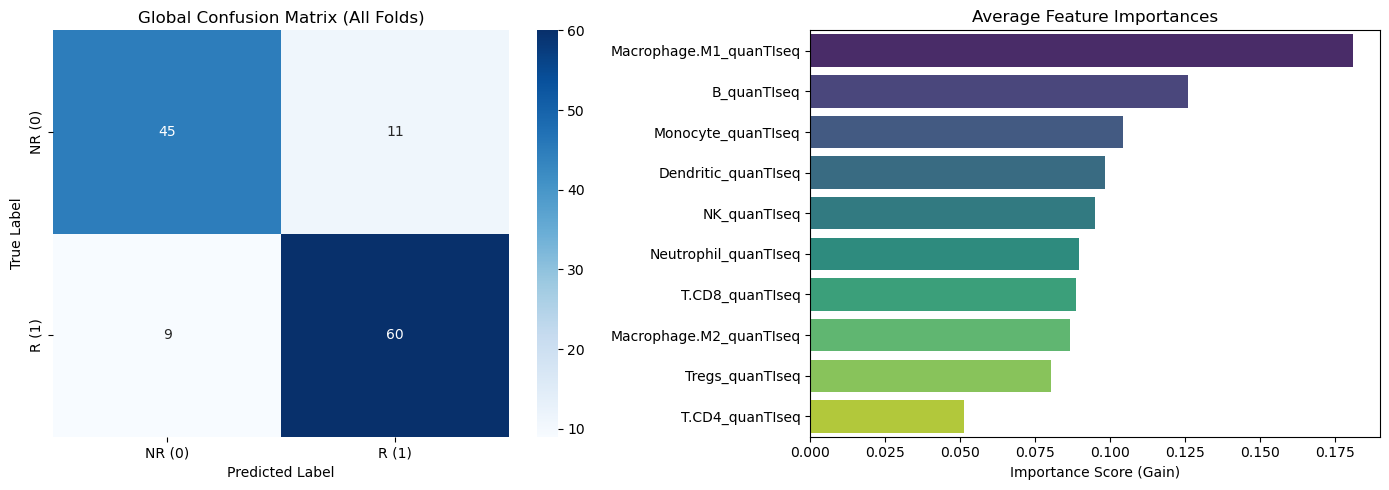

In [7]:
# ==========================================
# 4. Global Metrics & Plotting
# ==========================================
print("\n--- Final CV Results ---")
print(f"Mean Accuracy: {np.mean(scores):.4f}")
print(f"Mean AUC:      {np.mean(auc_scores):.4f}")

# Set up a 1x2 grid for plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(all_y_test, all_y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["NR (0)", "R (1)"], yticklabels=["NR (0)", "R (1)"],
    ax=axes[0]
)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].set_title("Global Confusion Matrix (All Folds)")

# Plot 2: Feature Importances
mean_importances = np.mean(fold_importances, axis=0)
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': mean_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

sns.barplot(
    data=importance_df, x='Importance', y='Feature', 
    palette='viridis', ax=axes[1]
)
axes[1].set_title('Average Feature Importances')
axes[1].set_xlabel('Importance Score (Gain)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Testing 120 unique 3-feature combinations...
Completed 20 / 120 combinations...
Completed 40 / 120 combinations...
Completed 60 / 120 combinations...
Completed 80 / 120 combinations...
Completed 100 / 120 combinations...
Completed 120 / 120 combinations...

--- TOP 5 PREDICTIVE COMBINATIONS ---
                              Features  Mean_AUC  Std_AUC
       Macrophage.M1 + Neutrophil + NK  0.882151 0.076938
    Macrophage.M1 + Neutrophil + Tregs  0.865176 0.076042
Dendritic + Macrophage.M1 + Neutrophil  0.862662 0.088949
  Dendritic + Macrophage.M1 + Monocyte  0.856310 0.074956
                    B + Dendritic + NK  0.850916 0.065253


/tmp/ipykernel_810/69715286.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


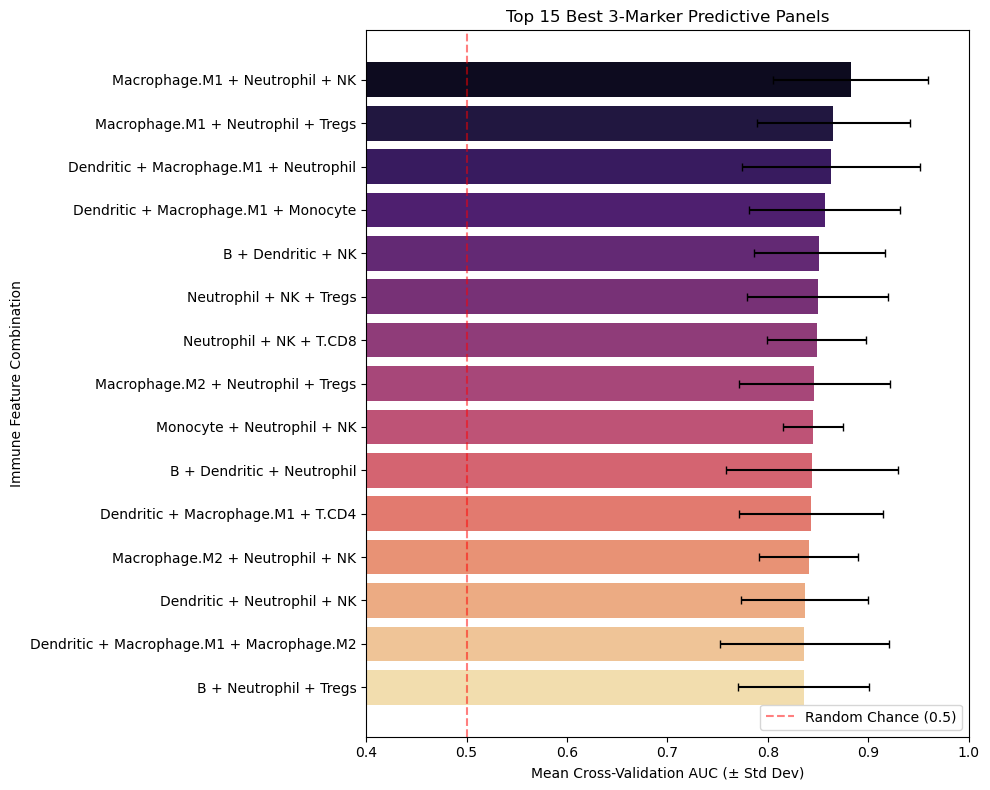

In [8]:
# Extract the best combination of three factors
import pandas as pd
import numpy as np
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. Setup Data and Combinations
# ==========================================
# Assuming X (containing your 10 immune features) and y (response) are already defined from previous steps

# Get all immune features
all_immune_features = X.columns.tolist()

# Generate all possible combinations of 3 features
# For 10 features, this will create 120 unique combinations
combo_size = 3
all_combos = list(combinations(all_immune_features, combo_size))
print(f"Testing {len(all_combos)} unique {combo_size}-feature combinations...")

# ==========================================
# 2. Combinatorial XGBoost Search
# ==========================================
# CRITICAL: Use a fixed random state so every combination is tested on the EXACT same data splits
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for idx, combo in enumerate(all_combos):
    features_subset = list(combo)
    X_subset = X[features_subset]
    
    auc_scores = []
    
    # Train and Evaluate on this specific 3-feature subset
    for train_idx, test_idx in skf.split(X_subset, y):
        X_train, X_test = X_subset.iloc[train_idx], X_subset.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Initialize model (Adding scale_pos_weight is good if you have more Non-Responders than Responders)
        model = XGBClassifier(
            n_estimators=100,      # Reduced slightly to speed up the loop
            max_depth=3,           # Kept shallow (3 features don't need deep trees)
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=1.0,  # Use all 3 features in every tree
            eval_metric="logloss",
            random_state=42
        )

        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        auc = roc_auc_score(y_test, y_prob)
        auc_scores.append(auc)
        
    # Calculate statistics for this combination
    mean_auc = np.mean(auc_scores)
    std_auc = np.std(auc_scores)
    
    results.append({
        'Features': " + ".join([f.replace('_quanTIseq', '') for f in combo]), # Clean names for readability
        'Mean_AUC': mean_auc,
        'Std_AUC': std_auc
    })
    
    # Optional: Print progress every 20 combinations
    if (idx + 1) % 20 == 0:
        print(f"Completed {idx + 1} / {len(all_combos)} combinations...")

# ==========================================
# 3. Analyze and Plot the Top Results
# ==========================================
# Convert to DataFrame and sort by the highest Mean AUC
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Mean_AUC', ascending=False).reset_index(drop=True)

print("\n--- TOP 5 PREDICTIVE COMBINATIONS ---")
print(results_df.head(5).to_string(index=False))

# Plot the Top 15 Combinations
top_n = 15
plt.figure(figsize=(10, 8))
sns.barplot(
    data=results_df.head(top_n), 
    x='Mean_AUC', 
    y='Features', 
    palette='magma'
)

# Add error bars (standard deviation across folds) to show stability
plt.errorbar(
    x=results_df.head(top_n)['Mean_AUC'], 
    y=range(top_n), 
    xerr=results_df.head(top_n)['Std_AUC'], 
    fmt='none', c='black', capsize=3
)

plt.title(f'Top {top_n} Best {combo_size}-Marker Predictive Panels')
plt.xlabel('Mean Cross-Validation AUC (± Std Dev)')
plt.ylabel('Immune Feature Combination')
plt.xlim(0.4, 1.0) # Adjust based on your actual AUC range
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random Chance (0.5)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Train a surrogate model for the ODE system

Solving 1500 ODEs. This may take a moment...
Successfully generated 1500 trajectories.

Training XGBoost Surrogate...
Global Trajectory Mean Squared Error: 0.000073


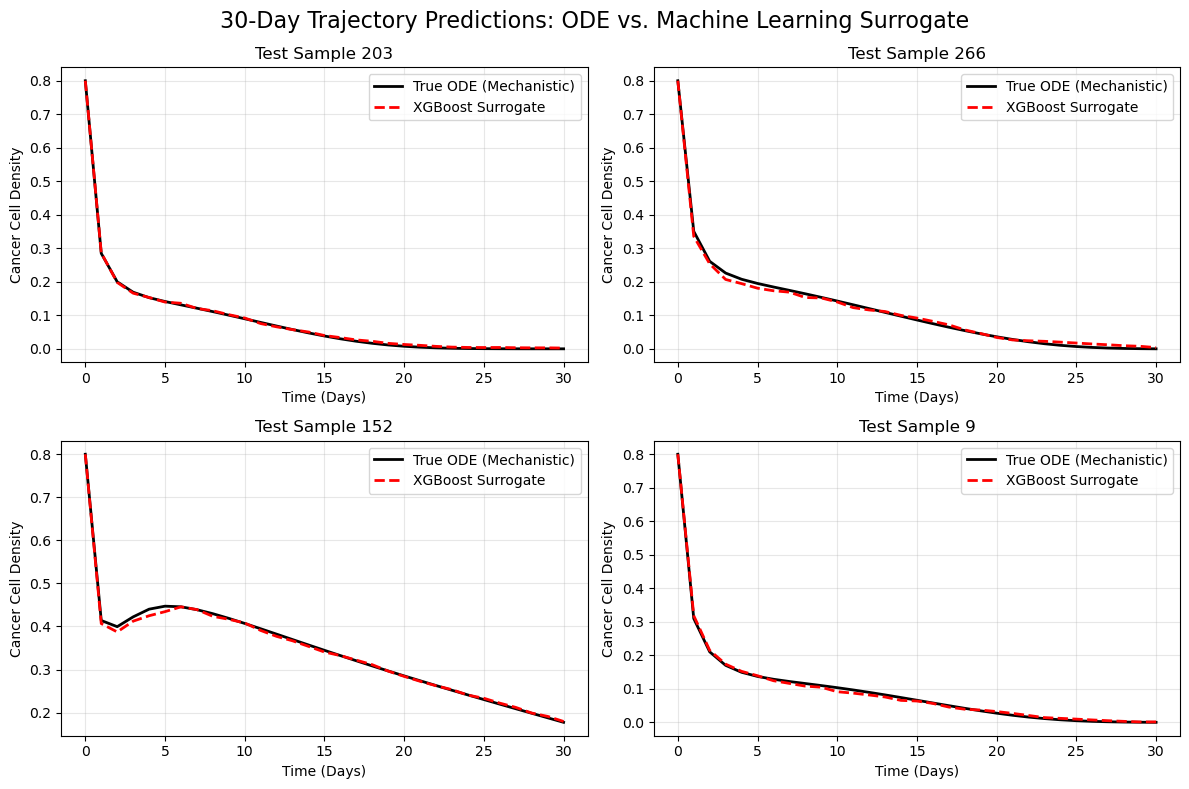

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ==========================================
# 1. Define the Mechanistic ODE System
# ==========================================
def ode_system(t, y, p):
    C, D, N, Tr, T8 = y

    dCdt = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dDdt = p["lambda_DC_comb"]*(C/(p["K_C"] + C)) - p["d_D"]*D
    dNdt = (p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + 
            p["a_C"]*N*(C/(1 + C/p["beta_1"] + N/p["beta_2"])))
    dTrdt = -p["d_Treg"]*Tr + p["lambda_Tr_comb"]*(C/(p["K_C"] + C))
    dT8dt = -p["d_T8"]*T8 + p["lambda_T8_comb"]*(D/(p["K_D"] + D))*(1/(1 + Tr/p["K_Treg"]))

    return [dCdt, dDdt, dNdt, dTrdt, dT8dt]

# ==========================================
# 2. ODE Data Generator Wrapper
# ==========================================
def generate_ode_training_data(n_samples=1000, t_max=30):
    """Samples initial immune conditions, solves the ODE, and formats ML data."""
    # Set seed for total reproducibility
    np.random.seed(42) 
    
    # Your exact parameters
    params = {
        'lambda_C': 2.0, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17,
        'lambda_DC_comb': 0.003, 'K_C': 0.4, 'd_D': 0.3, 'sigma_N': 0.0005, 
        'd_N': 0.13, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 
        'd_Treg': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.001, 'lambda_T8_comb': 0.0005, 
        'K_Treg': 0.0001, 'K_D': 0.0004
    }
    
    # Baseline Cancer starting value
    C_initial = 0.8
    feature_names = ['Dendritic_init', 'Neutrophil_init', 'Treg_init', 'CD8T_init']
    
    # Sample initial immune values. 
    # Because your eta_8 and eta_N (killing rates) are massive, we keep the initial 
    # immune populations quite small (between 0.0 and 0.005) so the tumor doesn't 
    # just instantly drop to zero in every single simulation.
    X_sim = np.random.uniform(low=0.0, high=0.005, size=(n_samples, 4))
    
    # Evaluate exactly once per day for 30 days (31 time points including Day 0)
    t_eval = np.linspace(0, t_max, t_max + 1)
    
    # Array to hold the Cancer trajectory outputs
    y_sim_traj = np.zeros((n_samples, len(t_eval)))
    valid_indices = []
    
    print(f"Solving {n_samples} ODEs. This may take a moment...")
    for i in range(n_samples):
        # Initial conditions: [C0, D0, N0, Tr0, T80]
        y0 = [C_initial, X_sim[i, 0], X_sim[i, 1], X_sim[i, 2], X_sim[i, 3]]
        
        sol = solve_ivp(
            fun=lambda t, y: ode_system(t, y, params),
            t_span=(0, t_max),
            y0=y0,
            t_eval=t_eval,
            method='LSODA' 
        )
        
        if sol.success:
            # Extract the Cancer trajectory (Index 0 is 'C')
            y_sim_traj[i, :] = sol.y[0, :]
            valid_indices.append(i)
            
    # Keep only successful simulations
    X_sim_clean = X_sim[valid_indices]
    y_sim_traj_clean = y_sim_traj[valid_indices]
    
    print(f"Successfully generated {len(valid_indices)} trajectories.")
    return pd.DataFrame(X_sim_clean, columns=feature_names), y_sim_traj_clean

# ==========================================
# 3. Generate Data and Split
# ==========================================
X, y_traj = generate_ode_training_data(n_samples=1500, t_max=30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_traj, test_size=0.2, random_state=42
)

# ==========================================
# 4. Train the XGBoost Surrogate Model
# ==========================================
print("\nTraining XGBoost Surrogate...")

# Wrap XGBRegressor in MultiOutputRegressor to predict all 31 days at once
base_model = XGBRegressor(
    n_estimators=200, 
    max_depth=5, 
    learning_rate=0.05, 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

surrogate_model = MultiOutputRegressor(base_model)
surrogate_model.fit(X_train, y_train)

# ==========================================
# 5. Evaluate and Plot Results
# ==========================================
# Predict on the test set
y_pred = surrogate_model.predict(X_test)

# Calculate global Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Global Trajectory Mean Squared Error: {mse:.6f}")

# Plot a side-by-side comparison of 4 random test samples
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Pick 4 random indices from the test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 4, replace=False)

for i, idx in enumerate(sample_indices):
    axes[i].plot(y_test[idx], label='True ODE (Mechanistic)', color='black', linewidth=2)
    axes[i].plot(y_pred[idx], label='XGBoost Surrogate', color='red', linestyle='--', linewidth=2)
    
    axes[i].set_title(f"Test Sample {idx}")
    axes[i].set_xlabel("Time (Days)")
    axes[i].set_ylabel("Cancer Cell Density")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle("30-Day Trajectory Predictions: ODE vs. Machine Learning Surrogate", fontsize=16)
plt.tight_layout()
plt.show()

Global Trajectory Mean Squared Error: 0.000073


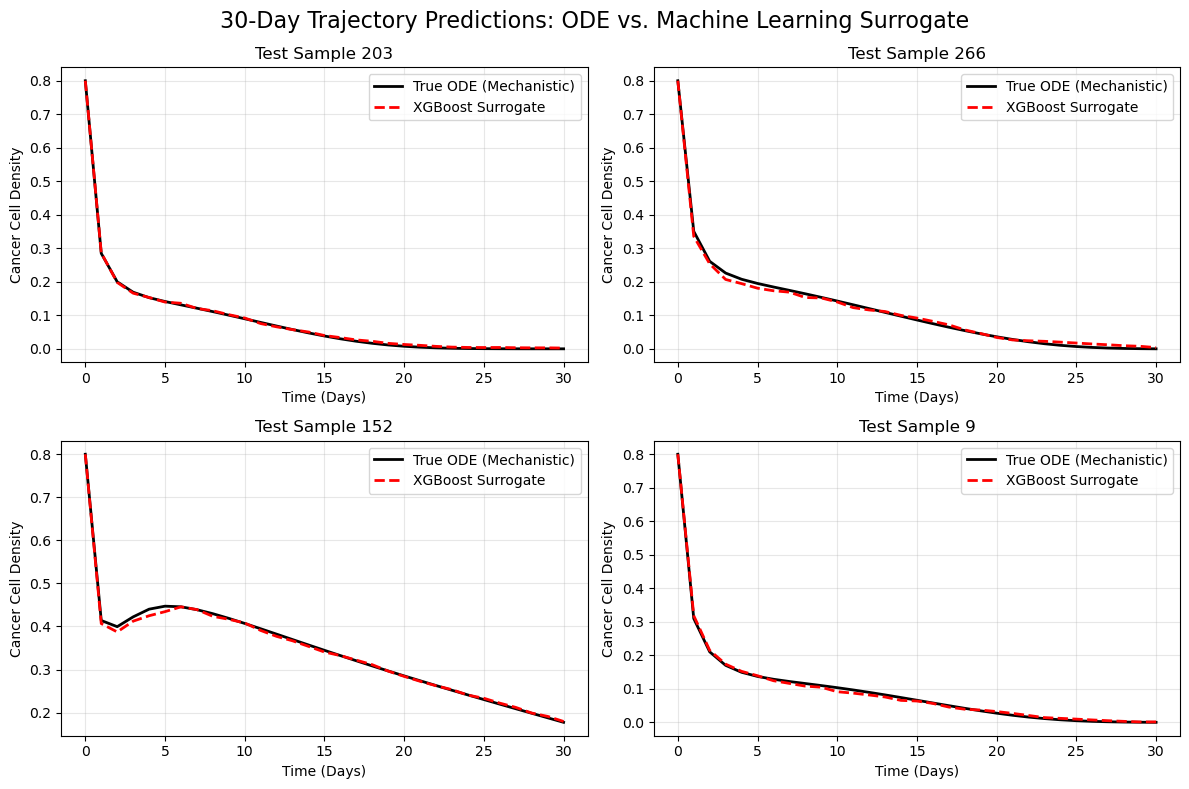

In [8]:
# ==========================================
# 5. Evaluate and Plot Results
# ==========================================
# Predict on the test set
y_pred = surrogate_model.predict(X_test)

# Calculate global Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Global Trajectory Mean Squared Error: {mse:.6f}")

# Plot a side-by-side comparison of 4 random test samples
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Pick 4 random indices from the test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 4, replace=False)

for i, idx in enumerate(sample_indices):
    axes[i].plot(y_test[idx], label='True ODE (Mechanistic)', color='black', linewidth=2)
    axes[i].plot(y_pred[idx], label='XGBoost Surrogate', color='red', linestyle='--', linewidth=2)
    
    axes[i].set_title(f"Test Sample {idx}")
    axes[i].set_xlabel("Time (Days)")
    axes[i].set_ylabel("Cancer Cell Density")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle("30-Day Trajectory Predictions: ODE vs. Machine Learning Surrogate", fontsize=16)
plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


Solving 1500 ODEs. This may take a moment...
Successfully generated 1500 trajectories.

Training XGBoost Surrogate...
Global Trajectory Mean Squared Error: 0.000073


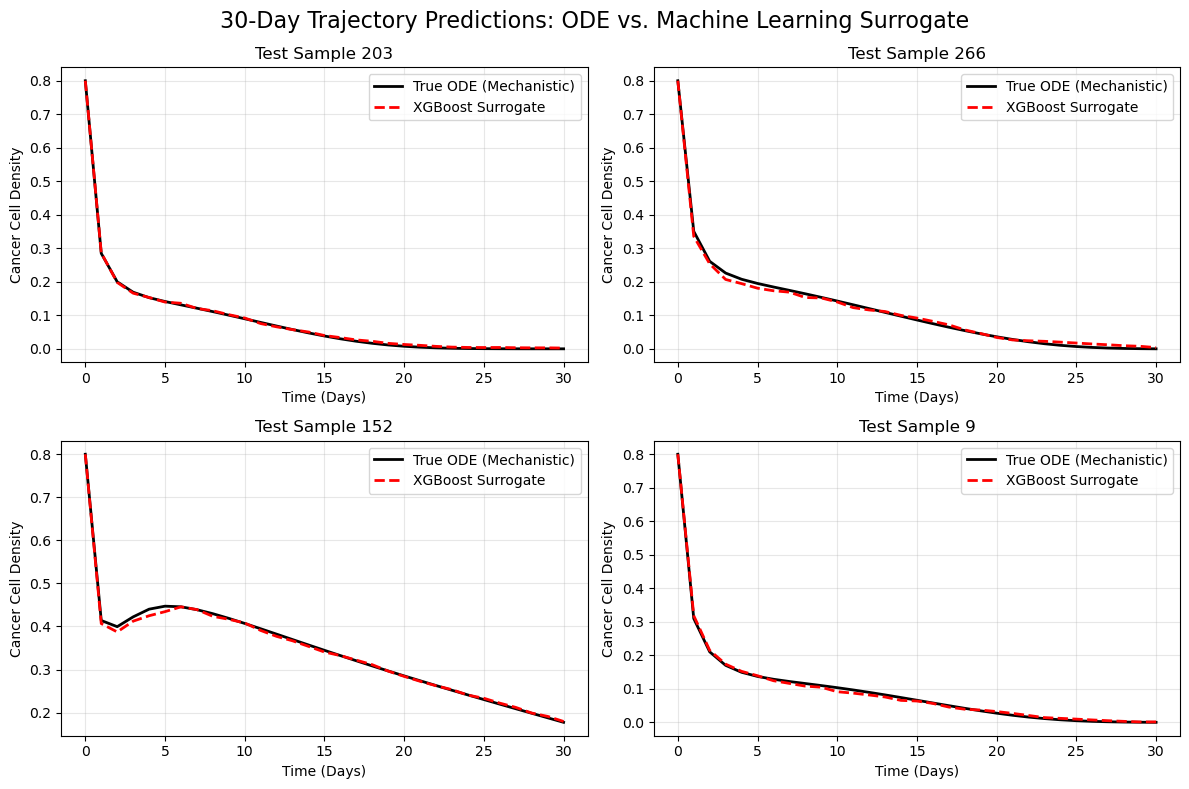

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ==========================================
# 1. Define the Mechanistic ODE System
# ==========================================
def ode_system(t, y, p):
    C, D, N, Tr, T8 = y

    dCdt = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dDdt = p["lambda_DC_comb"]*(C/(p["K_C"] + C)) - p["d_D"]*D
    dNdt = (p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + 
            p["a_C"]*N*(C/(1 + C/p["beta_1"] + N/p["beta_2"])))
    dTrdt = -p["d_Treg"]*Tr + p["lambda_Tr_comb"]*(C/(p["K_C"] + C))
    dT8dt = -p["d_T8"]*T8 + p["lambda_T8_comb"]*(D/(p["K_D"] + D))*(1/(1 + Tr/p["K_Treg"]))

    return [dCdt, dDdt, dNdt, dTrdt, dT8dt]

# ==========================================
# 2. ODE Data Generator Wrapper
# ==========================================
def generate_ode_training_data(n_samples=1000, t_max=30):
    """Samples initial immune conditions, solves the ODE, and formats ML data."""
    # Set seed for total reproducibility
    np.random.seed(42) 
    
    # Your exact parameters
    params = {
        'lambda_C': 2.0, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17,
        'lambda_DC_comb': 0.003, 'K_C': 0.4, 'd_D': 0.3, 'sigma_N': 0.0005, 
        'd_N': 0.13, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 
        'd_Treg': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.001, 'lambda_T8_comb': 0.0005, 
        'K_Treg': 0.0001, 'K_D': 0.0004
    }
    
    # Baseline Cancer starting value
    C_initial = 0.8
    feature_names = ['Dendritic_init', 'Neutrophil_init', 'Treg_init', 'CD8T_init']
    
    # Sample initial immune values. 
    # Because your eta_8 and eta_N (killing rates) are massive, we keep the initial 
    # immune populations quite small (between 0.0 and 0.005) so the tumor doesn't 
    # just instantly drop to zero in every single simulation.
    X_sim = np.random.uniform(low=0.0, high=0.005, size=(n_samples, 4))
    
    # Evaluate exactly once per day for 30 days (31 time points including Day 0)
    t_eval = np.linspace(0, t_max, t_max + 1)
    
    # Array to hold the Cancer trajectory outputs
    y_sim_traj = np.zeros((n_samples, len(t_eval)))
    valid_indices = []
    
    print(f"Solving {n_samples} ODEs. This may take a moment...")
    for i in range(n_samples):
        # Initial conditions: [C0, D0, N0, Tr0, T80]
        y0 = [C_initial, X_sim[i, 0], X_sim[i, 1], X_sim[i, 2], X_sim[i, 3]]
        
        sol = solve_ivp(
            fun=lambda t, y: ode_system(t, y, params),
            t_span=(0, t_max),
            y0=y0,
            t_eval=t_eval,
            method='LSODA' 
        )
        
        if sol.success:
            # Extract the Cancer trajectory (Index 0 is 'C')
            y_sim_traj[i, :] = sol.y[0, :]
            valid_indices.append(i)
            
    # Keep only successful simulations
    X_sim_clean = X_sim[valid_indices]
    y_sim_traj_clean = y_sim_traj[valid_indices]
    
    print(f"Successfully generated {len(valid_indices)} trajectories.")
    return pd.DataFrame(X_sim_clean, columns=feature_names), y_sim_traj_clean

# ==========================================
# 3. Generate Data and Split
# ==========================================
X, y_traj = generate_ode_training_data(n_samples=1500, t_max=30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_traj, test_size=0.2, random_state=42
)

# ==========================================
# 4. Train the XGBoost Surrogate Model
# ==========================================
print("\nTraining XGBoost Surrogate...")

# Wrap XGBRegressor in MultiOutputRegressor to predict all 31 days at once
base_model = XGBRegressor(
    n_estimators=200, 
    max_depth=5, 
    learning_rate=0.05, 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

surrogate_model = MultiOutputRegressor(base_model)
surrogate_model.fit(X_train, y_train)

# ==========================================
# 5. Evaluate and Plot Results
# ==========================================
# Predict on the test set
y_pred = surrogate_model.predict(X_test)

# Calculate global Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Global Trajectory Mean Squared Error: {mse:.6f}")

# Plot a side-by-side comparison of 4 random test samples
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Pick 4 random indices from the test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 4, replace=False)

for i, idx in enumerate(sample_indices):
    axes[i].plot(y_test[idx], label='True ODE (Mechanistic)', color='black', linewidth=2)
    axes[i].plot(y_pred[idx], label='XGBoost Surrogate', color='red', linestyle='--', linewidth=2)
    
    axes[i].set_title(f"Test Sample {idx}")
    axes[i].set_xlabel("Time (Days)")
    axes[i].set_ylabel("Cancer Cell Density")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle("30-Day Trajectory Predictions: ODE vs. Machine Learning Surrogate", fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
# Data Loading and preprocessing
df = pd.read_csv("tismo_metadata_subset.csv")

# Filter for Mammary cancer, Baseline == 1, and valid ICB_Baseline_TYPE
# Therefore, we can predict the response based on baseline immune infiltration rates
cancer_list = ["Mammary carcinoma", "Mammary adenocarcinoma", "Mammary cancer, NOS"]
mask = (
    (df["Cancer_type"].isin(cancer_list)) & 
    (df["Baseline"] == 1) & 
    (df["ICB_Baseline_TYPE"].isin(["R", "NR"]))
)
df_ml = df[mask].copy()

print(f"Initial shape: {df_ml.shape}")
print(df_ml["ICB_Baseline_TYPE"].value_counts())

# Map target to binary
df_ml["response"] = df_ml["ICB_Baseline_TYPE"].map({"NR": 0, "R": 1})

Initial shape: (125, 33)
ICB_Baseline_TYPE
R     69
NR    56
Name: count, dtype: int64


In [22]:
df_ml.columns

Index(['Study_ID', 'GSM_ID', 'IN_VIVO', 'Cancer_type', 'Cell_Line',
       'sub_clone', 'Condition', 'ICB', 'B_quanTIseq', 'Dendritic_quanTIseq',
       'Macrophage.M1_quanTIseq', 'Macrophage.M2_quanTIseq',
       'Monocyte_quanTIseq', 'Neutrophil_quanTIseq', 'NK_quanTIseq',
       'T.CD4_quanTIseq', 'T.CD8_quanTIseq', 'Tregs_quanTIseq', 'ICB_study',
       'ICB_group', 'ICB_Baseline_TYPE', 'Baseline', 'Cell_treatment',
       'Cell_genotype', 'Tumor', 'Mouse_genotype', 'Mouse_strain',
       'Mouse_treatment', 'Timepoint', 'Implantation', 'Implantation_site',
       'SRX_ID', 'SampleName', 'response'],
      dtype='str')

In [4]:
df_ml["Timepoint"].unique()

<StringArray>
[nan, 'day7', 'end', 'day3']
Length: 4, dtype: str

Run a virtual experiment with ML

T11 Day-3 Dataset shape: (11, 33)
True Clinical Responses:
 ICB_Baseline_TYPE
R     7
NR    4
Name: count, dtype: int64

--- Predicting 15-Day Trajectories for T11 Patients ---

Accuracy of Trajectory-Based Prediction: 0.6364

Classification Report:
              precision    recall  f1-score   support

      NR (0)       0.00      0.00      0.00         4
       R (1)       0.64      1.00      0.78         7

    accuracy                           0.64        11
   macro avg       0.32      0.50      0.39        11
weighted avg       0.40      0.64      0.49        11



/home/zhilin/miniforge3/envs/tumor_model/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zhilin/miniforge3/envs/tumor_model/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zhilin/miniforge3/envs/tumor_model/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

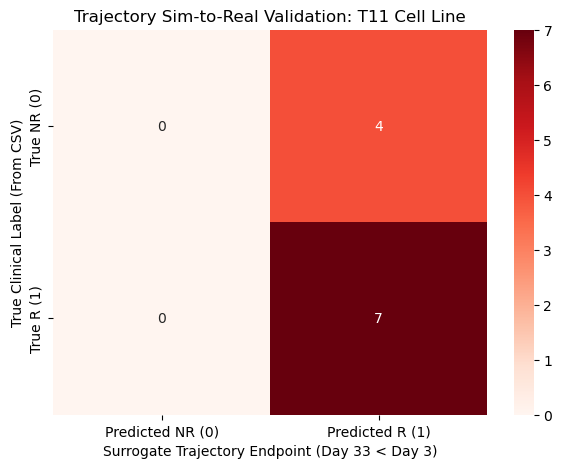

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. Data Loading and Preprocessing
# ==========================================
df = pd.read_csv("tismo_metadata_subset.csv")

# Filter for Mammary cancer, Baseline == 1, Timepoint == day3, valid Response, and T11 Cell Line
cancer_list = ["Mammary carcinoma", "Mammary adenocarcinoma", "Mammary cancer, NOS"]
mask = (
    (df["Cancer_type"].isin(cancer_list)) & 
    (df["Baseline"] == 1) & 
    (df["Timepoint"] == "day3") &          # <-- NEW: Day 3 filter added
    (df["ICB_Baseline_TYPE"].isin(["R", "NR"])) &
    (df["Cell_Line"] == "T11")
)
df_ml = df[mask].copy()

print(f"T11 Day-3 Dataset shape: {df_ml.shape}")
print("True Clinical Responses:\n", df_ml["ICB_Baseline_TYPE"].value_counts())

# Map true clinical target to binary (NR: 0, R: 1)
df_ml["true_response"] = df_ml["ICB_Baseline_TYPE"].map({"NR": 0, "R": 1})

# ==========================================
# 2. Map Clinical Data to ODE Features
# ==========================================
clinical_features = [
    "Dendritic_quanTIseq", 
    "Neutrophil_quanTIseq", 
    "Tregs_quanTIseq", 
    "T.CD8_quanTIseq"
]

# Drop any rows missing these specific immune values
df_clean = df_ml[clinical_features + ["true_response"]].dropna()

X_real = df_clean[clinical_features]
y_real = df_clean["true_response"]

# Rename columns to perfectly match the ODE surrogate training features
X_real = X_real.rename(columns={
    "Dendritic_quanTIseq": "Dendritic_init",
    "Neutrophil_quanTIseq": "Neutrophil_init",
    "Tregs_quanTIseq": "Treg_init",
    "T.CD8_quanTIseq": "CD8T_init"
})

# ==========================================
# 3. Predict Trajectories & Calculate Response
# ==========================================
# NOTE: 'surrogate_model' here must be your MultiOutputRegressor (Trajectory model), 
# NOT the Classifier model!

print("\n--- Predicting 15-Day Trajectories for T11 Patients ---")

# Predict the full 30-day trajectories (Shape: [n_patients, 31 timepoints])
predicted_trajectories = surrogate_model.predict(X_real)

# Extract Day 0 (Clinical Day 3) and Day 30 (Clinical Day 33)
# Index 0 is the start of the simulation, Index -1 is the end of the simulation
initial_tumor_load = predicted_trajectories[:, 0]
final_tumor_load = predicted_trajectories[:, 16] # Extract the endpoint on day 16 - corresponds to the median time to end point

# Apply the Virtual Clinical Endpoint: 
# If final tumor load is strictly less than initial tumor load, it's a Response (1).
simulated_responses = (final_tumor_load < initial_tumor_load).astype(int)

# ==========================================
# 4. Evaluate and Plot Results
# ==========================================
acc = accuracy_score(y_real, simulated_responses)
print(f"\nAccuracy of Trajectory-Based Prediction: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_real, simulated_responses, target_names=["NR (0)", "R (1)"]))

# Plot the Validation Confusion Matrix
cm = confusion_matrix(y_real, simulated_responses)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Reds", 
    xticklabels=["Predicted NR (0)", "Predicted R (1)"], 
    yticklabels=["True NR (0)", "True R (1)"]
)
plt.xlabel("Surrogate Trajectory Endpoint (Day 33 < Day 3)")
plt.ylabel("True Clinical Label (From CSV)")
plt.title("Trajectory Sim-to-Real Validation: T11 Cell Line")
plt.show()

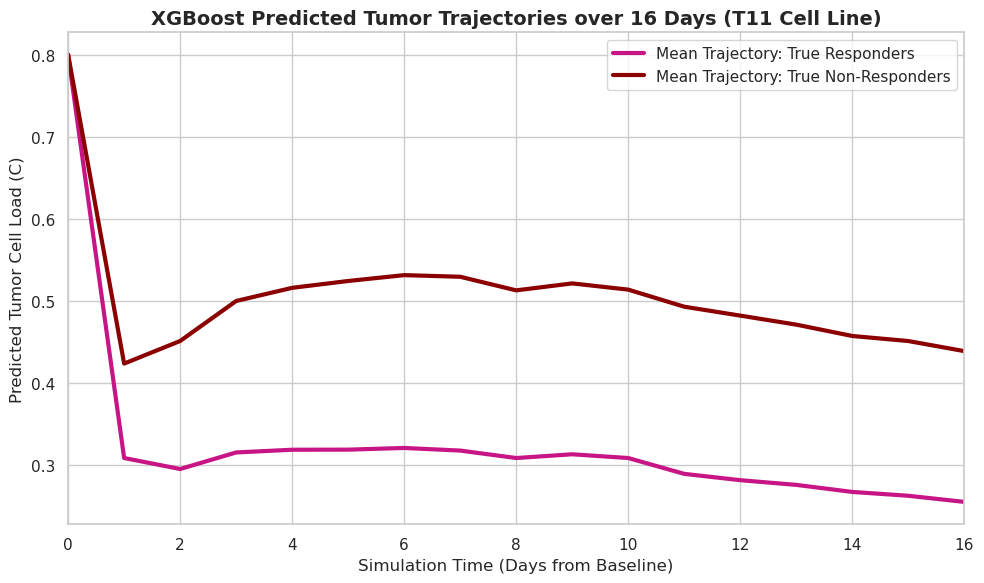

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Extract the 16-Day Window
# ==========================================
# Our predictions span 31 indices (Day 0 to Day 30). 
# We want Day 0 to Day 16, which is indices 0 through 16 (17 points total).
days = np.arange(17)
traj_16_days = predicted_trajectories[:, 0:17]

# Separate the predicted trajectories based on the REAL clinical labels
# This proves whether our model accurately reflects clinical reality
traj_real_R = traj_16_days[y_real == 1]   # True Responders
traj_real_NR = traj_16_days[y_real == 0]  # True Non-Responders

# ==========================================
# 2. Setup the Plot Canvas
# ==========================================
# Using a clean seaborn style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Define our reddish-purple color scheme
color_R = "#C71585"   # Medium Violet Red (Shrinking Tumors)
color_NR = "#8B0000"  # Dark Red (Growing Tumors)

# ==========================================
# 3. Plot True Responders (Belt + Mean Line)
# ==========================================
if len(traj_real_R) > 0:
    mean_R = np.mean(traj_real_R, axis=0)
    std_R = np.std(traj_real_R, axis=0)
    
    # Plot the "Belt" (Mean +/- 1 Standard Deviation)
    # plt.fill_between(days, mean_R - std_R, mean_R + std_R, color=color_R, alpha=0.2, label='True Responders (±1 SD)')
    # Plot the Mean Trajectory Line
    plt.plot(days, mean_R, color=color_R, linewidth=3, label='Mean Trajectory: True Responders')

# ==========================================
# 4. Plot True Non-Responders (Belt + Mean Line)
# ==========================================
if len(traj_real_NR) > 0:
    mean_NR = np.mean(traj_real_NR, axis=0)
    std_NR = np.std(traj_real_NR, axis=0)
    
    # Plot the "Belt" (Mean +/- 1 Standard Deviation)
    # plt.fill_between(days, mean_NR - std_NR, mean_NR + std_NR, color=color_NR, alpha=0.2, label='True Non-Responders (±1 SD)')
    # Plot the Mean Trajectory Line
    plt.plot(days, mean_NR, color=color_NR, linewidth=3, label='Mean Trajectory: True Non-Responders')

# ==========================================
# 5. Optional: Plot individual patient lines (Faded)
# ==========================================
# If you want to show the raw data underneath the belts, uncomment the loop below:
'''
for i in range(len(traj_real_R)):
    plt.plot(days, traj_real_R[i], color=color_R, alpha=0.15, linewidth=1)
for i in range(len(traj_real_NR)):
    plt.plot(days, traj_real_NR[i], color=color_NR, alpha=0.15, linewidth=1)
'''

# ==========================================
# 6. Formatting and Labels
# ==========================================
# plt.figure(figsize=(10, 6))
plt.title("XGBoost Predicted Tumor Trajectories over 16 Days (T11 Cell Line)", fontsize=14, fontweight='bold')
plt.xlabel("Simulation Time (Days from Baseline)", fontsize=12)
plt.ylabel("Predicted Tumor Cell Load (C)", fontsize=12)

# Set the x-axis to only show our 0-16 day timeframe
plt.xlim(0, 16)
plt.xticks(np.arange(0, 17, 2)) # Show tick marks every 2 days

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [13]:
mean_NR = np.mean(traj_real_NR, axis=0)
std_NR = np.std(traj_real_NR, axis=0)
print("Standard Deviation for NRs:", std_NR) # <-- Add this!

Standard Deviation for NRs: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
